# La méthode M3 — pondérer au dollar **et** au nombre d'élus

Chaque fin de mois, pour un parti : on regarde les achats que ses élus ont **divulgués** sur les trois
dernières années, on note chaque titre par **le montant acheté multiplié par le nombre d'élus acheteurs**,
on garde les 150 premiers, on plafonne chaque ligne à 10 %, et on tient le panier un mois.

**Ce notebook est autonome.** Il ne dépend d'aucun autre : il repart du fichier de transactions propre et du
cache de prix, recopie le moteur, et se re-prouve à chaque étape. Il ne contient qu'une méthode — M3 — et
les décompositions qui expliquent son résultat.

### La spécification, en six points

À chaque fin de mois $t$, pour le parti $P$ :

1. **fenêtre** — les opérations **divulguées** sur $(t - 756\ \text{j};\ t]$, soit environ trois ans de bourse ;
2. **sens** — les **achats** seulement (une vente de vieille ligne n'est pas un signal négatif) ;
3. **score** — $\;s_i = B_i \times m_i\;$ où $B_i = \sum_k A_k$ est le montant acheté du titre $i$
   ($A_k$ = milieu de la fourchette déclarée) et $m_i$ le nombre d'**élus distincts** qui l'ont acheté ;
4. **univers** — les **150** plus gros $s_i$, parmi les titres qui cotent (§2) ;
5. **poids** — $\;w_i = \min(c,\ \lambda v_i)\;$ avec $v_i = s_i / \sum_j s_j$ et $\lambda$ l'unique réel tel
   que $\sum_i w_i = 1$ ; plafond $c = 10\,\%$ ;
6. **exécution** — au **close du lendemain** de la coupe, puis on ne touche plus à rien jusqu'au mois suivant.

**La conséquence du produit.** Si $K$ élus achètent le même titre pour le même montant $a$, alors
$B_i = Ka$, $m_i = K$, donc $s_i = K^2 a$ : le consensus compte **au carré**. C'est le seul endroit de toute
la méthode où l'on s'écarte d'une pondération au dollar.

### Les constantes, et ce qui les fixe

| constante | valeur | ce qui la fixe — jamais notre rendement |
|---|---|---|
| $W_3$ | 756 j (3 ans) | la règle publiée du fonds |
| $A_k$ | milieu de fourchette | la règle publiée du fonds |
| $\delta$ (divulgation) | — | la date de transaction n'est pas investissable |
| $N$ | 150 | le prospectus annonce 100 à 200 lignes |
| $c$ | 10 % | la médiane du fonds réel sur 13 dates **et** la limite UCITS |
| rythme | mensuel | un signal à 3 ans ne renouvelle qu'un trente-sixième par mois |
| $\theta$ | 50 opérations | la description d'un gérant, pas un réglage *(M4 seulement)* |

### Ce que ce notebook n'établit pas

L'excès de M3 **n'est pas significatif** — son intervalle de confiance contient zéro. On livre la méthode la
mieux fondée, pas une méthode dont on prouve qu'elle gagne. · Les résultats sont **bruts de frais** partout
sauf au §9, qui les facture. · La fidélité au vrai fonds NANC/GOP et l'audit de la formule vivent dans le
notebook 11, ils ne sont pas repris ici.

### Une règle de démarrage, et pourquoi elle existe

Le plafond de 10 % n'a de solution que si l'univers compte au moins dix titres. À la toute première fin
de mois, en janvier 2014, la fenêtre de trois ans ne contient qu'un mois de déclarations et les démocrates
n'ont que **neuf** titres éligibles : le plafond y est inapplicable et le portefeuille serait équipondéré,
donc pas celui que la spécification décrit. **Le backtest ne démarre qu'à la première coupe où la règle est
applicable aux deux partis** — le 28 février 2014. Le critère est structurel, il ne fait intervenir aucun
rendement, et il fait légèrement *baisser* le résultat.

### Les chiffres que ce notebook publie

Mesurés sur les **coupes conformes** à la règle de démarrage (§4.1), au plafond $c = 10\,\%$ — ce sont exactement les chiffres de la fiche M3. Le §6 les établit, le §8 les passe aux quatre facteurs de Fama-French-Carhart.

| | NANC (Démocrates) | GOP (Républicains) |
|---|---|---|
| NAV finale (base 100) | **662** | **574** |
| excès %/an · $t$ | +3,40 · 1,61 | +1,24 · 1,61 |
| IC 95 % de l'excès | [−1,19 ; +7,99] | [−0,44 ; +2,91] |
| $\alpha_1$ · $\alpha_4$ (%/an) | +1,66 · +2,09 | +1,09 · +1,65 |
| $\beta$ marché | 1,080 | 1,004 |
| années gagnantes | 9/13 | 9/13 |

**Contrôle d'extraction.** Rejoués sur les **150 coupes** et au **plafond du notebook 11 (8,5 %)**, ces mêmes calculs doivent reproduire ses dix-huit nombres — NAV **672,35 / 612,25** — sinon l'extraction est fausse. C'est le §6.1 (a) qui le vérifie ; le §6.1 (b) affiche les deux jeux côte à côte.

## §1 — Le périmètre

In [1]:
import os, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_recuperation_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/02_recherche_backtest/cache/prices_v2"
FF_CSV = f"{RACINE}/02_recherche_backtest/cache/ff_factors.csv"
FIGS   = f"{RACINE}/02_recherche_backtest/figs_nb13"
os.makedirs(FIGS, exist_ok=True)

W3, TOPN, CAP = 756, 150, 0.10           # les trois constantes de M3
print(f"W₃ = {W3} j (≈ 3 ans) · N = {TOPN} titres · c = {100*CAP:.1f} %")
print(f"figures → {FIGS}")

W₃ = 756 j (≈ 3 ans) · N = 150 titres · c = 10.0 %
figures → /Users/lemairealice/Downloads/Jupiter/02_recherche_backtest/figs_nb13


### §1.1 — Choisir le sous-ensemble

**La table est déjà propre** : c'est le produit du pipeline S1/S2 (dédoublonnage, dates réparées, tickers
résolus, montants parsés). On ne nettoie rien, on choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; \delta_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, date de
divulgation, sens, milieu de fourchette.

La colonne `etf_proxy` est chargée bien qu'inutile à M3 : elle porte l'ETF sectoriel de chaque titre, et
c'est par elle que passera la variante ETF (§9). Une colonne de plus ne change aucun filtre — le §1.5 le
vérifie.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics",
                                  "flag_late_filing","party","etf_proxy"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                                 # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]  # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,etf_proxy,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,XLE,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,XLE,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,XLRE,buy,8000.5,2014-01-02,2014-01-27,False


### §1.2 — Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### §1.3 — Charger les prix, et re-prouver leur santé

Les garde-fous sont ceux des notebooks amont, ré-appliqués ici **parce que ce notebook est autonome** — ce
n'est pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.5) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes (§2).

**Les onze ETF sectoriels SPDR sont chargés en plus des titres.** Ils ne peuvent pas entrer dans M3 : le
périmètre du §1.1 ne garde que `asset_class == "stock"`, et ces onze-là sont classés `etf_sector`. Ils sont
là pour le §9. Le §1.5 vérifie que leur présence ne fait entrer aucune ligne dans le flux.

In [4]:
ETF_SECT = ["XLB","XLC","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]   # les 11 secteurs GICS

PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(set(df.tk.unique()) | set(ETF_SECT)):        # ← l'union : les titres ET les 11 ETF
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()

PXV_ACTIONS = set(df.tk.unique()) & set(PXV)                  # ← le périmètre de M3, hors ETF
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV_ACTIONS):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")
print(f"ETF sectoriels chargés en plus : {len(set(PXV) - PXV_ACTIONS)}/11  (pour le §9, hors périmètre M3)")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)
ETF sectoriels chargés en plus : 11/11  (pour le §9, hors périmètre M3)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # exécution à la transaction τ
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution à la divulgation δ — celle de M3
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### §1.4 — Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers d'actions en est un **sous-ensemble** : actions
seules, 2014-2026. L'inclusion doit donc être stricte. Le test porte sur `PXV_ACTIONS`, pas sur `PXV` —
sinon on parierait sur la présence des ETF dans une table qu'on ne contrôle pas.

In [6]:
t09 = pd.read_csv(f"{RACINE}/02_recherche_backtest/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = PXV_ACTIONS - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"13 · titres chargés (actions 2014-2026)  : {len(PXV_ACTIONS):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
13 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09


### §1.5 — Validation : les deux préparatifs du §9 ne touchent à rien

Deux choses ont été écrites ici pour la variante ETF : la colonne `etf_proxy` chargée, et les onze SPDR
ajoutés au cache de prix. Ni l'une ni l'autre ne doit modifier le flux de M3. On le vérifie plutôt que de
l'affirmer.

In [7]:
# (1) aucun des 11 ETF sectoriels n'apparaît dans le flux : ils sont classés `etf_sector`, jamais `stock`
inter = set(df.tk.unique()) & set(ETF_SECT)
assert not inter, f"un ETF sectoriel est entré dans le flux de M3 : {inter}"

# (2) le flux a la taille attendue, celle du notebook 11
assert len(df) == 113_369, f"flux = {len(df):,} lignes, attendu 113 369 (le périmètre a bougé)"

# (3) etf_proxy est utilisable : rempli partout, et à valeurs dans les 11 secteurs
assert df.etf_proxy.notna().all(), f"{df.etf_proxy.isna().sum()} lignes sans etf_proxy"
assert set(df.etf_proxy.unique()) <= set(ETF_SECT), f"etf_proxy hors des 11 SPDR : {set(df.etf_proxy.unique()) - set(ETF_SECT)}"

print(f"✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux ({len(df):,} trades, inchangé)")
print(f"✅ etf_proxy renseigné sur 100 % des {len(df):,} lignes, à valeurs dans les 11 secteurs GICS")

✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux (113,369 trades, inchangé)
✅ etf_proxy renseigné sur 100 % des 113,369 lignes, à valeurs dans les 11 secteurs GICS


## §2 — L'univers investissable $\mathcal{U}_t$ et les coupes

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement nul et risque nul,
qui gonflerait le résultat sans jamais perdre d'argent.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # le titre cote DÉJÀ (sa série a commencé) ET cote ENCORE (dernier cours à moins de 4 jours)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4

mort = sum(1 for tk in PXV_ACTIONS if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV_ACTIONS):,} "
      f"({mort/len(PXV_ACTIONS):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


In [9]:
# les coupes commencent avec la donnée : dernier jour coté de chaque mois, à partir de janvier 2014
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if 21 <= i < len(cal) - 1))
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")
print(f"première coupe : indice {coupes[0]} dans le calendrier (qui démarre en {cal[0].year})")

150 coupes mensuelles · 2014-01-31 → 2026-06-30
première coupe : indice 522 dans le calendrier (qui démarre en 2012)


### §2.1 — Validation : le seuil de la première coupe ne mord pas

Le notebook 11 écrivait cette borne avec la fenêtre de sa première méthode ($W = 21$ j, puis 42 j sans que
la liste soit recalculée). Ici on l'écrit en dur, à 21 — mais il faut prouver que ce choix est sans effet.
Il l'est parce que le calendrier de prix démarre en 2012 alors que les coupes démarrent en 2014 : la
première coupe a un indice bien supérieur à toute fenêtre envisagée.

In [10]:
def _coupes(seuil):
    c = [cal.searchsorted(d, side="right") - 1 for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
    return sorted(set(i for i in c if seuil <= i < len(cal) - 1))

for s in [0, 21, 42, 126]:
    assert _coupes(s) == coupes, f"le seuil {s} change la liste des coupes"
print(f"✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de {len(coupes)} coupes")
print(f"   (la 1ʳᵉ coupe est à l'indice {coupes[0]} ≫ 126 : la borne ne peut pas mordre)")

✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de 150 coupes
   (la 1ʳᵉ coupe est à l'indice 522 ≫ 126 : la borne ne peut pas mordre)


## §3 — Le moteur d'exécution

Le moteur ne connaît pas la méthode : il reçoit un dictionnaire de **poids cibles** par coupe et fabrique
une NAV. Ce qu'il fait, dans l'ordre, à chaque coupe :

- il **achète au close du lendemain** ($e = t+1$) — jamais au cours de la coupe elle-même ;
- il convertit les poids en **nombres de parts**, puis n'y touche plus : entre deux coupes le portefeuille
  **dérive** avec les cours, exactement comme un portefeuille réel ;
- il mesure la **rotation réalisée** $\;\mathrm{TO}_t = \tfrac12 \sum_i |w^{\text{réalisé}}_i - w^{\text{dérivé}}_i|$ ;
- deux réglages **neutres par défaut** : un frein de rotation $\tau_{\max}$ (§8) et un coût $c$ en points de
  base (§8). À $\tau_{\max} = \infty$ et $c = 0$, aucune opération n'est faite — la NAV est bit-identique.

$$\lambda_R = \min\!\Bigl(1, \frac{\tau_{\max}}{\mathrm{TO}_t}\Bigr), \qquad
w^{\text{réalisé}}_i = w^{\text{dérivé}}_i + \lambda_R\,(w^{\text{cible}}_i - w^{\text{dérivé}}_i), \qquad
V_t \leftarrow V_t\,(1 - 2\,\mathrm{TO}_t\,c)$$

Le **facteur 2** sur le coût : $\tfrac12\sum|\Delta w|$ est le montant *acheté*, égal au montant *vendu* ;
on paie des deux côtés.

In [11]:
TAU_MAX = 0.25                                                        # frein de rotation, en %/mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None, cout_bps=0.0):
    # moteur d'UN livre : parts, buy-and-hold, frein de rotation, frais. Rend (NAV, rotations réalisées)
    # tau_max=∞ et cout_bps=0 → aucune opération n'est faite : la NAV est celle du buy-and-hold pur
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du frein, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]).
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        if cout_bps: V[e] *= 1.0 - 2.0*turns[-1]*cout_bps/1e4
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # rotation hors 1er déploiement

### §3.1 — Validation : un mois recalculé à la main, hors moteur

On prend deux titres à poids connus, on fabrique la NAV à la main sur un mois, et on vérifie que le moteur
donne la même chose. C'est le seul moyen de savoir que « close J+1, parts figées, dérive » est bien ce qui
est implémenté, et pas seulement ce qui est écrit.

In [12]:
tk1, tk2 = "AAPL", "MSFT"
j0, j1 = coupes[60], coupes[61]                       # deux coupes consécutives quelconques
WP_test = {j0: {tk1: 0.60, tk2: 0.40}, j1: {tk1: 0.60, tk2: 0.40}}
V_test, _ = run_livre(WP_test, np.inf, cuts=[j0, j1, coupes[62]])

e = j0 + 1                                            # on achète au close du LENDEMAIN de la coupe
q1 = 100.0 * 0.60 / PXV[tk1][e]                       # parts, figées jusqu'à la coupe suivante
q2 = 100.0 * 0.40 / PXV[tk2][e]
for t in [e, e + 5, j1]:                              # trois dates dans le mois
    a_la_main = q1*PXV[tk1][t] + q2*PXV[tk2][t]
    assert abs(V_test.loc[cal[t]] - a_la_main) < 1e-9, f"écart au jour {cal[t].date()}"

print(f"achat au close du {cal[e].date()} (la coupe est le {cal[j0].date()}) — {q1:.4f} × {tk1} + {q2:.4f} × {tk2}")
print(f"NAV à la coupe suivante : moteur {V_test.loc[cal[j1]]:.6f} · à la main {q1*PXV[tk1][j1]+q2*PXV[tk2][j1]:.6f}")
print("✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit")

achat au close du 2019-02-01 (la coupe est le 2019-01-31) — 1.5186 × AAPL + 0.4178 × MSFT
NAV à la coupe suivante : moteur 106.442585 · à la main 106.442585
✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit


## §4 — M3 : la spécification, et son code

$$w^{P}_{i,t} \;=\; \Pi_c\!\left(\frac{s_{i,t}}{\sum_{j \in \mathcal{S}} s_{j,t}}\right), \qquad
s_{i,t} \;=\; \underbrace{\Big(\textstyle\sum_{k\,:\,P,\ \text{achat},\ t-W_3<\delta_k\le t} A_k\Big)}_{B_i\ \text{: les dollars}}
\;\times\; \underbrace{\#\{\text{élus de }P\text{ acheteurs de } i\}}_{m_i\ \text{: le consensus}}$$

où $\mathcal{S}$ est l'ensemble des 150 plus gros scores et $\Pi_c$ le plafonnement à $c = 10\,\%$.

**Le plafonnement est un remplissage par niveau, pas un écrêtage.** $\Pi_c$ cherche l'unique $\lambda$ tel
que $\sum_i \min(c, \lambda v_i) = 1$ : les lignes qui touchent le plafond y restent, les autres montent
proportionnellement. Comme $\lambda \mapsto \sum_i \min(c, \lambda v_i)$ croît continûment de 0 à
$|\mathcal{S}|\,c$, ce $\lambda$ existe et est unique **dès que** $|\mathcal{S}| \ge \lceil 1/c \rceil = 10$
titres. En dessous de 10, aucune solution n'existe — on y revient au §4.1, qui en tire la règle de démarrage.

**Le filtre anti-bruit** ($\theta$) écarte toute opération appartenant à un dépôt de $\theta$ opérations ou
plus du même élu le même jour : un rééquilibrage automatique de courtier n'est pas une décision. M3 ne
l'applique pas ($\theta = \infty$) ; M4 l'applique à $\theta = 50$.

In [13]:
# ── fenêtrage sur la DIVULGATION δ : l'index trié une fois pour toutes ──
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]

FUSION = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}   # classes d'actions = une société

def cap_poids(w, cap=CAP):
    # remplissage par niveau : w_i = min(cap, λ·v_i), λ trouvé par redistribution itérative de l'excédent
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

# taille du dépôt = nb d'opérations déclarées par le même élu le même jour de divulgation.
# Définie ICI, avec poids_methode qui la lit — même à θ=∞ la colonne doit exister.
df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")

def _instrument(g, univers="titres"):
    # LE point de substitution : ce que le portefeuille achète réellement.
    #   "titres" → le titre lui-même, classes d'actions fusionnées (M3)
    #   "etf"    → l'ETF sectoriel SPDR du titre (§9)
    if univers == "titres": return g.tk.map(lambda t: FUSION.get(t, t))
    if univers == "etf":    return g.etf_proxy
    raise ValueError(f"univers inconnu : {univers}")

SEUIL_BRUIT = 50          # θ — DÉCLARÉ AVANT tout calcul de rendement (M4 seulement)

def poids_methode(i1, parti, topN=TOPN, cap=CAP, seuil=np.inf, mode="score", univers="titres"):
    # M3 = les valeurs par défaut. `mode` ne change QUE la pondération : l'univers reste défini par le score.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy") & (g.taille_depot < seuil)]
    if not len(g): return {}
    g       = g.assign(tkm=_instrument(g, univers))
    buy     = g.groupby("tkm").A.sum()                                   # B_i : les dollars
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)  # m_i : les élus
    score   = (buy * breadth).dropna()
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)               # ← l'UNIVERS, toujours par le score
    if not len(score) or score.sum() <= 0: return {}
    w = {"score":   score,
         "dollars": buy.reindex(score.index),
         "elus":    breadth.reindex(score.index).astype(float),
         "equal":   pd.Series(1.0, index=score.index)}[mode]
    if w.sum() <= 0: return {}
    return cap_poids(w / w.sum(), cap).to_dict()

def cibles_methode(parti, **kw):
    return {i: poids_methode(i, parti, **kw) for i in coupes[:-1]}

PARTIS = [("Democrat", "NANC"), ("Republican", "GOP")]
print(f"M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N={TOPN}, c={100*CAP:.0f} %")

M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N=150, c=10 %


### §4.1 — La règle de démarrage : le backtest commence où la spécification est applicable

Le plafond $c = 10\,\%$ n'a de solution que si l'univers compte au moins $\lceil 1/c\rceil = 10$ titres
(§4.3). En dessous, `cap_poids` rend l'équipondéré : le portefeuille ne serait plus celui que la
spécification décrit. **On ne démarre donc le backtest qu'à la première coupe où la règle est applicable aux
deux partis.**

Ce critère est **structurel** : il se calcule sur le nombre de titres éligibles, sans qu'aucun rendement
n'intervienne. Il ne peut donc pas être un réglage déguisé — et de fait, il fait légèrement *baisser* le
résultat.

*Pourquoi le cas se présente : le signal regarde trois ans en arrière, mais les données commencent en 2014.
À la première fin de mois, la fenêtre ne contient qu'un mois de déclarations au lieu de trente-six.*

In [14]:
SEUIL_DEG = math.ceil(1/CAP)                      # en dessous, le plafond n'a pas de solution
card = {i: {nom: len(poids_methode(i, parti)) for parti, nom in PARTIS} for i in coupes[:-1]}
conformes = [i for i in coupes[:-1] if min(card[i].values()) >= SEUIL_DEG]
i_start   = conformes[0]

print(f"titres retenus aux 5 premières fins de mois (seuil = {SEUIL_DEG}) :")
for i in coupes[:5]:
    ok = "✓" if min(card[i].values()) >= SEUIL_DEG else "✗  ← le plafond n'a pas de solution"
    print(f"   {cal[i].date()} : NANC {card[i]['NANC']:3d} · GOP {card[i]['GOP']:3d}   {ok}")

coupes_tout = list(coupes)                         # gardé : sert au contrôle de non-régression du §6.1
coupes = [i for i in coupes if i >= i_start]       # ← le calendrier du backtest publié
print(f"\ndépart : {cal[i_start].date()} (achat au close du {cal[i_start+1].date()}) · "
      f"{len(coupes)} coupes retenues sur {len(coupes_tout)}")

titres retenus aux 5 premières fins de mois (seuil = 10) :
   2014-01-31 : NANC   9 · GOP  24   ✗  ← le plafond n'a pas de solution
   2014-02-28 : NANC  99 · GOP 112   ✓
   2014-03-31 : NANC 115 · GOP 150   ✓
   2014-04-30 : NANC 136 · GOP 150   ✓
   2014-05-30 : NANC 150 · GOP 150   ✓

départ : 2014-02-28 (achat au close du 2014-03-03) · 149 coupes retenues sur 150


### §4.2 — Le cache : un seul jeu de cibles par variante, et toutes les tables y puisent

Calculer les poids cibles est le seul calcul coûteux du notebook (149 coupes × un regroupement sur ~30 000
lignes). On les calcule **une fois**, dans `WPM`, et **`SER` en dérive**. Ce n'est pas une optimisation :
c'est ce qui rend impossible qu'un tableau du §5 affiche 672,35 et qu'un tableau du §8 affiche 672,31.

In [15]:
import time
t0 = time.time()

KWM = {"M3 · $ × élus":     dict(),                                    # ← LA méthode
       "M2 · dollars purs": dict(mode="dollars"),                      # la pondération sans le consensus
       "élus seuls":        dict(mode="elus"),                         # le consensus sans les dollars
       "équipondéré":       dict(mode="equal"),                        # ni l'un ni l'autre
       "M4 · + filtre θ=50": dict(seuil=SEUIL_BRUIT)}                  # M3 + le filtre anti-bruit
for th in [10, 20, 100]:
    KWM[f"θ = {th}"] = dict(seuil=th)

WPM = {}                                                               # (variante, fonds) → {coupe: {tk: w}}
for parti, nom in PARTIS:
    for m, kw in KWM.items():
        WPM[(m, nom)] = cibles_methode(parti, **kw)
SER = {k: run_livre(WP, np.inf)[0] for k, WP in WPM.items()}           # les NAV en dérivent

n_poids = sum(len(w) for WP in WPM.values() for w in WP.values())
print(f"{len(WPM)} jeux de cibles · {n_poids:,} poids · calculés en {time.time()-t0:.1f} s")

16 jeux de cibles · 352,002 poids · calculés en 14.7 s


In [16]:
# VALIDATION §4.2 — le cache est complet et cohérent, et tout le notebook lira CES objets
assert len(WPM) == 2*len(KWM), f"cache incomplet : {len(WPM)} jeux au lieu de {2*len(KWM)}"
for (m, f), WP in WPM.items():
    assert set(WP) == set(coupes[:-1]), f"{m}/{f} : jeu de coupes incohérent"
    for i, w in WP.items():
        if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{f} coupe {i} : Σw = {sum(w.values())}"
print(f"✅ {len(WPM)} jeux complets · Σw = 1 à chacune des {len(coupes)-1} coupes de chacun")

✅ 16 jeux complets · Σw = 1 à chacune des 148 coupes de chacun


### §4.3 — Validation : le plafond est bien un remplissage par niveau, et la règle de démarrage suffit

Deux contrôles indépendants du code de `cap_poids` :

1. **le point fixe** — on retrouve $\lambda$ par bissection sur $\sum_i \min(c, \lambda v_i) = 1$ et on
   vérifie que le vecteur obtenu est celui de `cap_poids` ;
2. **plus aucune coupe dégénérée** — quand $|\mathcal{S}| < \lceil 1/c \rceil = 12$, **aucun** $\lambda$ ne
   convient : plafonner tout le monde ne remplit pas le portefeuille, `cap_poids` aplatit et sa
   normalisation finale rend l'**équipondéré**. La règle du §4.1 écarte exactement ces coupes ; on vérifie
   qu'il n'en reste aucune, et on mesure ce que la coupe écartée aurait coûté.

In [17]:
# (1) le point fixe : λ retrouvé par bissection, indépendamment de cap_poids
def lam_bissection(v, cap=CAP):
    lo, hi = 1.0, 1e9
    for _ in range(300):
        lam = 0.5*(lo + hi)
        if sum(min(cap, lam*x) for x in v) < 1.0: lo = lam
        else: hi = lam
    return 0.5*(lo + hi)

ecart_max = 0.0
for i in coupes[10:150:17]:
    lo, hi = np.searchsorted(I_de, i - W3, "right"), np.searchsorted(I_de, i, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == "Democrat") & (g.op == "buy")]
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    sc = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    sc = sc[[t for t in sc.index if t in PXV and np.isfinite(PXV[t][i+1]) and vivant(t, i)]]
    sc = sc.sort_values(ascending=False).head(TOPN)
    if len(sc) < math.ceil(1/CAP): continue
    v   = (sc / sc.sum()).values
    lam = lam_bissection(v)
    ecart_max = max(ecart_max, float(np.abs(np.minimum(CAP, lam*v) - cap_poids(sc/sc.sum()).values).max()))
print(f"✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max {ecart_max:.2e}")
print(f"     ⌈1/c⌉ = {math.ceil(1/CAP)} titres : en dessous, aucun λ ne convient")

✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max 9.71e-17
     ⌈1/c⌉ = 10 titres : en dessous, aucun λ ne convient


In [18]:
# (2) plus aucune coupe dégénérée dans le calendrier retenu
for nom in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", nom)]
    deg = [i for i in coupes[:-1] if WP[i] and len(WP[i]) < SEUIL_DEG]
    assert not deg, f"{nom} : coupes encore dégénérées → {[str(cal[i].date()) for i in deg]}"
    tailles = [len(WP[i]) for i in coupes[:-1] if WP[i]]
    print(f"✅ (2) {nom} — 0 coupe sous {SEUIL_DEG} titres sur {len(coupes)-1} · "
          f"|𝒮| min {min(tailles)} · médiane {int(np.median(tailles))}")

# ce que la coupe écartée aurait valu : elle était équipondérée de fait, pas pondérée par le score
i_ecarte = coupes_tout[0]
for nom, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    w = poids_methode(i_ecarte, parti)
    ecart = np.abs(np.array(list(w.values())) - 1/len(w)).max()
    print(f"\ncoupe écartée du {cal[i_ecarte].date()} — {nom} : |𝒮| = {len(w)} · "
          f"max w {100*max(w.values()):.2f} % · écart à l'équipondéré {ecart:.1e}"
          f"{'  → équipondéré de fait' if ecart < 1e-9 else ''}")

✅ (2) NANC — 0 coupe sous 10 titres sur 148 · |𝒮| min 99 · médiane 150
✅ (2) GOP — 0 coupe sous 10 titres sur 148 · |𝒮| min 112 · médiane 150

coupe écartée du 2014-01-31 — NANC : |𝒮| = 9 · max w 11.11 % · écart à l'équipondéré 1.4e-17  → équipondéré de fait

coupe écartée du 2014-01-31 — GOP : |𝒮| = 24 · max w 10.00 % · écart à l'équipondéré 5.8e-02


### §4.4 — Validation : la conséquence en $K^2$, sur un cas fabriqué

Le produit $B_i \times m_i$ n'est pas une pondération au dollar déguisée. On le vérifie sur trois titres
fabriqués : à montant total identique, celui qu'un plus grand nombre d'élus a acheté doit dominer, et le
rapport des scores doit être exactement le rapport des carrés du nombre d'élus.

In [19]:
cas = pd.DataFrame({"titre": ["A", "B", "C"], "élus": [1, 2, 4], "$ par élu": [40_000, 20_000, 10_000]})
cas["B_i (total $)"] = cas["élus"] * cas["$ par élu"]                  # 40 000 pour les trois
cas["m_i"] = cas["élus"]
cas["s_i = B·m"] = cas["B_i (total $)"] * cas.m_i
cas["poids %"] = 100 * cas["s_i = B·m"] / cas["s_i = B·m"].sum()
display(cas.set_index("titre"))

assert cas["B_i (total $)"].nunique() == 1, "le cas doit être à montant total identique"
assert abs(cas["s_i = B·m"].iloc[2] / cas["s_i = B·m"].iloc[0] - 4) < 1e-12, "le rapport devrait être m_C/m_A = 4"
print(f"✅ à dollars égaux, 4 élus pèsent {cas['s_i = B·m'].iloc[2]/cas['s_i = B·m'].iloc[0]:.0f}× un seul élu")
print("   (le score est K²a pour K élus au montant a : le consensus compte au carré)")

,élus,$ par élu,B_i (total $),m_i,s_i = B·m,poids %
titre,,,,,,
A,1,40000,40000,1,40000,14.285714
B,2,20000,40000,2,80000,28.571429
C,4,10000,40000,4,160000,57.142857


✅ à dollars égaux, 4 élus pèsent 4× un seul élu
   (le score est K²a pour K élus au montant a : le consensus compte au carré)


### §4.5 — D'où vient le plafond de 10 %, et pourquoi pas 8,5 %

Le plafond est le seul paramètre de M3 qui ne se lise pas dans le prospectus : il faut l'**estimer**. Deux
sources indépendantes, dont aucune n'est notre rendement, permettent de le faire — et elles convergent.

1. **Le fonds lui-même**, à travers les treize états de portefeuille qu'il dépose à la SEC.
2. **La réglementation** : 10 % par émetteur est la limite UCITS ; au-delà, un fonds européen n'est plus
   distribuable.

On mesure ici la première, et on regarde ce que le plafond retient réellement — c'est-à-dire à quoi
ressemblerait le portefeuille si on ne plafonnait pas.

In [20]:
NP = pd.read_csv(f"{RACINE}/02_recherche_backtest/cache/nport_holdings.csv")
mx = NP.groupby(["fonds", "date"]).pct.max().unstack(0).round(2)
print(f"plus grosse ligne du portefeuille RÉEL, aux {len(mx)} dates N-PORT (%) :")
display(mx)
for f in mx.columns:
    print(f"   {f:5s} médiane {mx[f].median():.2f} % · min {mx[f].min():.2f} % · max {mx[f].max():.2f} %")
print(f"\n→ le plafond retenu, {100*CAP:.0f} %, est la médiane de NANC ({mx['NANC'].median():.1f} %) "
      f"et la limite UCITS.")
print(f"   l'ancien 8,5 % venait d'UNE photo (24/07/2026) — il tombait SOUS le minimum jamais "
      f"observé ({mx['NANC'].min():.2f} %).")
print(f"   ⚠️ côté GOP la contrainte réelle est bien plus serrée ({mx['GOP'].median():.1f} %) : notre "
      f"réplique y est plus concentrée que l'original.")

plus grosse ligne du portefeuille RÉEL, aux 13 dates N-PORT (%) :


fonds,GOP,NANC
date,,
2023-03-31,3.65,7.99
2023-06-30,2.00,9.17
2023-09-30,2.66,10.42
2023-12-31,2.42,9.15
2024-03-31,2.42,10.30
2024-06-30,3.22,12.67
2024-09-30,3.79,11.60
2024-12-31,4.31,11.41
2025-03-31,4.49,8.99


   GOP   médiane 3.79 % · min 2.00 % · max 7.41 %
   NANC  médiane 10.33 % · min 7.99 % · max 12.67 %

→ le plafond retenu, 10 %, est la médiane de NANC (10.3 %) et la limite UCITS.
   l'ancien 8,5 % venait d'UNE photo (24/07/2026) — il tombait SOUS le minimum jamais observé (7.99 %).
   ⚠️ côté GOP la contrainte réelle est bien plus serrée (3.8 %) : notre réplique y est plus concentrée que l'original.


In [21]:
# ce que le plafond retient : la concentration du portefeuille NON contraint, sur toutes les coupes
for parti, nom in PARTIS:
    L = []
    for i in coupes[:-1]:
        w = poids_methode(i, parti, cap=1.0)
        if w:
            t = pd.Series(w).sort_values(ascending=False)
            L.append((100*t.iloc[0], t.index[0], cal[i].date()))
    m = np.array([x[0] for x in L])
    top = sorted(L, reverse=True)[0]
    print(f"{nom} sans plafond — plus grosse ligne : médiane {np.median(m):.1f} % · p90 "
          f"{np.percentile(m,90):.1f} % · MAX {m.max():.1f} % ({top[1]}, {top[2]})")
    print(f"      au-dessus de 20 % : {100*(m>20).mean():.0f} % des coupes · "
          f"au-dessus de 30 % : {100*(m>30).mean():.0f} %")
print(f"\n→ sans plafond ce n'est plus un portefeuille : le plafond arbitre entre rendement et "
      f"concentration,\n   et les deux ancrages ci-dessus disent où placer le curseur.")

NANC sans plafond — plus grosse ligne : médiane 35.7 % · p90 61.3 % · MAX 87.3 % (BRK-B, 2015-03-31)
      au-dessus de 20 % : 82 % des coupes · au-dessus de 30 % : 70 %


GOP sans plafond — plus grosse ligne : médiane 13.3 % · p90 34.8 % · MAX 43.4 % (MMM, 2015-10-30)
      au-dessus de 20 % : 25 % des coupes · au-dessus de 30 % : 24 %

→ sans plafond ce n'est plus un portefeuille : le plafond arbitre entre rendement et concentration,
   et les deux ancrages ci-dessus disent où placer le curseur.


## §5 — La boîte à outils de mesure

Quatre grandeurs, définies une fois, utilisées partout.

**L'excès annuel** — on compose les rendements par année civile, des deux côtés, et on soustrait :
$$x_Y = \prod_{t \in Y}(1+r_t) - \prod_{t \in Y}(1+r^{\mathrm{SPY}}_t), \qquad
t = \frac{\bar x}{\sigma_x/\sqrt{n}}, \qquad \mathrm{IC}_{95} = \bar x \pm t_{0{,}975;\,n-1}\,\frac{\sigma_x}{\sqrt n}$$
Avec $n = 13$ années, il faut $|t| > 2{,}18$ pour conclure. *(Le $t$ de Student, pas 1,96 : $n$ est petit.)*

**Le modèle à un facteur** — $r - r_f = \alpha_1 + \beta\,(r^{\mathrm{SPY}} - r_f) + \varepsilon$, sur données
journalières, $\alpha$ annualisé $\times 252$.

**Le modèle à quatre facteurs** (Fama-French-Carhart) — le même en ajoutant SMB (petites moins grandes),
HML (value moins croissance) et Mom (momentum) :
$$r - r_f = \alpha_4 + \beta_M (r_m - r_f) + \beta_S\,\mathrm{SMB} + \beta_H\,\mathrm{HML} + \beta_U\,\mathrm{Mom} + \varepsilon$$
$\alpha_4$ répond à : *reste-t-il quelque chose une fois retirés le marché, la taille, le style et le momentum ?*

**La concentration** — plus gros poids, somme des 5 premiers, et $N_{\text{eff}} = 1/\sum_i w_i^2$, le nombre
de lignes qu'il faudrait à poids égaux pour être aussi peu concentré.

In [22]:
FF   = pd.read_csv(FF_CSV, parse_dates=["Date"]).set_index("Date")     # une seule lecture pour tout le notebook
FACS = ["Mkt-RF", "SMB", "HML", "Mom"]
print(f"facteurs : {list(FF.columns)} · {FF.index[0].date()} → {FF.index[-1].date()} · {len(FF):,} jours")

ESSAIS = []          # tout run passé au bilan y laisse son nom : c'est le compteur de multiplicité (§12.7)

def bilan(Vx, nom):
    ESSAIS.append(nom)
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(FF[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

def bilan_ic(Vx, nom):
    # bilan() + l'intervalle de confiance de l'excès annuel moyen
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    n, se = len(xx), xx.std(ddof=1)/np.sqrt(len(xx))
    q = float(stats.t.ppf(0.975, n-1))
    b = dict(bilan(Vx, nom))
    b.update({"n ans": n, "IC bas": 100*(xx.mean()-q*se), "IC haut": 100*(xx.mean()+q*se)})
    return b

def facteurs(Vx, nom, cols=FACS):
    # régression OLS multi-facteurs + erreurs-types ; α annualisé ×252
    r = Vx.pct_change().dropna().rename("r")
    d = pd.DataFrame(r).join(FF, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in cols])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o = {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0]}
    for j, c in enumerate(cols, 1):
        o[c] = b[j]; o["t " + c] = b[j]/se[j]
    o["n j"] = len(y)
    return o

def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)

def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1

def conc(w):
    # w : une Series de poids EN POURCENTS, triée décroissante
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1 / float(np.sum(p**2)), 1)

Wab = 252
def roll_ab(span):
    r = span.pct_change().dropna()
    d = pd.DataFrame({"y": r, "m": r_spy.reindex(r.index)}).join(FF[["RF"]]).dropna()
    y, x  = d.y - d.RF, d.m - d.RF
    beta  = y.rolling(Wab).cov(x) / x.rolling(Wab).var()
    alpha = (y.rolling(Wab).mean() - beta * x.rolling(Wab).mean()) * 252 * 100     # α annualisé, %
    return alpha.dropna(), beta.dropna(), y, x

facteurs : ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom'] · 2013-01-02 → 2026-04-30 · 3,352 jours


### §5.1 — Validation : les outils, contrôlés sur le SPY lui-même

Passer l'indice dans nos propres mesures doit rendre l'évidence : $\beta_M \approx 1$, tous les autres
chargements $\approx 0$, $\alpha \approx 0$. Si ce n'était pas le cas, aucun des résultats qui suivent
n'aurait de valeur.

In [23]:
nav_spy_full = (1 + r_spy).cumprod() * 100
v = facteurs(nav_spy_full, "SPY (contrôle)")
assert abs(v["Mkt-RF"] - 1) < 0.05, f"β_MKT du SPY = {v['Mkt-RF']:.3f}, attendu ≈ 1"
assert abs(v["α %/an"]) < 2.0, f"α du SPY = {v['α %/an']:.2f} %/an, attendu ≈ 0"
display(pd.DataFrame([v]).set_index("run").round(3))
print(f"✅ contrôle SPY : β_MKT {v['Mkt-RF']:.3f} ≈ 1 · α {v['α %/an']:+.2f} %/an ≈ 0")

# le fichier de facteurs s'arrête avant la NAV : on dit combien de jours la régression perd
print(f"\nfacteurs disponibles jusqu'au {FF.index[-1].date()} · calendrier de prix jusqu'au {cal[-1].date()}")

,α %/an,t_α,Mkt-RF,t Mkt-RF,SMB,t SMB,HML,t HML,Mom,t Mom,n j
run,,,,,,,,,,,
SPY (contrôle),0.04,0.115,0.98,755.945,-0.123,-54.046,0.012,6.548,-0.009,-6.325,3352


✅ contrôle SPY : β_MKT 0.980 ≈ 1 · α +0.04 %/an ≈ 0

facteurs disponibles jusqu'au 2026-04-30 · calendrier de prix jusqu'au 2026-07-02


## §6 — Ce que M3 vaut

Deux runs, un par parti, même règle. Rien n'a été choisi après avoir vu ces chiffres.

In [24]:
M3 = {nom: SER[("M3 · $ × élus", nom)] for _, nom in PARTIS}
nav_spy_m3 = (1 + r_spy.reindex(M3["NANC"].index).fillna(0)).cumprod() * 100

# le SPY n'est pas mis dans ce tableau : son « excès sur lui-même » vaut zéro, et les colonnes t et
# années gagnantes n'y seraient que du bruit d'arrondi. Il sert de repère de NAV et de rendement, ci-dessous.
PERF = pd.DataFrame([bilan_ic(M3["NANC"], "M3 · NANC (Démocrates)"),
                     bilan_ic(M3["GOP"],  "M3 · GOP (Républicains)")]).set_index("run")
display(PERF[["excès %/an", "t", "n ans", "IC bas", "IC haut", "α %/an", "t_α", "β", "NAV", "ann. gagnantes"]].round(2))

for nom in ["NANC", "GOP"]:
    n = int(np.median([len(WPM[("M3 · $ × élus", nom)][i]) for i in coupes[:-1] if WPM[("M3 · $ × élus", nom)][i]]))
    print(f"{nom} : {n} titres (médiane) · NAV {M3[nom].iloc[-1]:.0f} · total {100*cagr(M3[nom]):.1f} %/an")
print(f"SPY  : repère            · NAV {nav_spy_m3.iloc[-1]:.0f} · total {100*cagr(nav_spy_m3):.1f} %/an")
print(f"\nseuil de significativité à n = {PERF.loc['M3 · NANC (Démocrates)', 'n ans']:.0f} années : "
      f"|t| > {stats.t.ppf(0.975, 12):.2f}  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro")

,excès %/an,t,n ans,IC bas,IC haut,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,,,,
M3 · NANC (Démocrates),3.40,1.61,13,-1.19,7.99,1.66,1.36,1.08,661.57,9/13
M3 · GOP (Républicains),1.24,1.61,13,-0.44,2.91,1.09,1.07,1.00,573.57,9/13


NANC : 150 titres (médiane) · NAV 662 · total 16.6 %/an
GOP : 150 titres (médiane) · NAV 574 · total 15.2 %/an
SPY  : repère            · NAV 494 · total 13.9 %/an

seuil de significativité à n = 13 années : |t| > 2.18  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro


### §6.1 — Validation : l'extraction est-elle fidèle, et que change la règle de démarrage ?

Deux contrôles, à ne pas confondre.

**(a) La fidélité de l'extraction.** Le notebook 11 a publié dix-huit nombres pour M3, sur les 150 coupes.
Ce notebook les recalcule depuis le CSV brut, par un chemin qu'il a lui-même reconstruit. S'ils ne
coïncident pas, l'extraction a changé quelque chose et tout le reste est à jeter. **Ce contrôle porte sur
`coupes_tout`** — il est indépendant de la règle de démarrage.

**(b) Ce que la règle de démarrage déplace.** Les chiffres publiés par *ce* notebook sont ceux des coupes
conformes. On mesure l'écart entre les deux, pour qu'il soit visible et non subi.

In [25]:
# ── (a) FIDÉLITÉ DE L'EXTRACTION : sur les 150 coupes, on doit retrouver le notebook 11 au chiffre près ──
# Ce contrôle rejoue la spécification du notebook 11, PLAFOND COMPRIS (c = 8,5 %). Il prouve que la chaîne
# de calcul est identique — indépendamment du plafond retenu aujourd'hui, qui est un choix de spécification.
CAP_NB11 = 0.085
TOUT = {nom: run_livre({i: poids_methode(i, parti, cap=CAP_NB11) for i in coupes_tout[:-1]},
                       np.inf, cuts=coupes_tout)[0]
        for parti, nom in PARTIS}
MT = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(TOUT[nom], f"{nom} · 150 coupes"), facteurs(TOUT[nom], nom)
    MT[(nom,"NAV")] = b["NAV"];      MT[(nom,"excès")] = b["excès %/an"]; MT[(nom,"t")] = b["t"]
    MT[(nom,"α1")]  = b["α %/an"];   MT[(nom,"β")] = b["β"];              MT[(nom,"α4")] = f["α %/an"]
    MT[(nom,"IC bas")] = b["IC bas"]; MT[(nom,"IC haut")] = b["IC haut"]; MT[(nom,"gagnantes")] = b["ann. gagnantes"]

ANCRES = {("NANC","NAV"): 672.35, ("GOP","NAV"): 612.25,
          ("NANC","excès"): 2.98, ("GOP","excès"): 1.24,
          ("NANC","t"): 1.47,     ("GOP","t"): 1.62,
          ("NANC","α1"): 1.26,    ("GOP","α1"): 1.12,
          ("NANC","α4"): 1.75,    ("GOP","α4"): 1.68,
          ("NANC","β"): 1.077,    ("GOP","β"): 1.004,
          ("NANC","IC bas"): -1.44, ("NANC","IC haut"): 7.40,
          ("GOP","IC bas"): -0.42,  ("GOP","IC haut"): 2.90}
TOL = {"NAV": 0.005, "excès": 0.005, "t": 0.005, "α1": 0.005, "α4": 0.005, "β": 0.0005,
       "IC bas": 0.005, "IC haut": 0.005}
for (f, k), att in ANCRES.items():
    assert abs(MT[(f,k)] - att) <= TOL[k], f"ancre {f}/{k} : {MT[(f,k)]:.4f} ≠ {att} (notebook 11)"
for f, att in [("NANC", "9/13"), ("GOP", "10/13")]:
    assert MT[(f,"gagnantes")] == att, f"{f} : {MT[(f,'gagnantes')]} ≠ {att}"
print(f"✅ (a) sur les {len(coupes_tout)} coupes et au plafond du notebook 11 ({100*CAP_NB11:.1f} %), les "
      f"{len(ANCRES)+2} chiffres sont reproduits (NAV {MT[('NANC','NAV')]:.2f} / {MT[('GOP','NAV')]:.2f}) "
      f"— l'extraction est fidèle\n")

# ── (b) CE QUE LA RÈGLE DE DÉMARRAGE DÉPLACE ──
MES = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(M3[nom], nom), facteurs(M3[nom], nom)
    MES[(nom,"NAV")] = b["NAV"];     MES[(nom,"excès")] = b["excès %/an"]; MES[(nom,"t")] = b["t"]
    MES[(nom,"α1")]  = b["α %/an"];  MES[(nom,"β")] = b["β"];              MES[(nom,"α4")] = f["α %/an"]
    MES[(nom,"IC bas")] = b["IC bas"]; MES[(nom,"IC haut")] = b["IC haut"]; MES[(nom,"gagnantes")] = b["ann. gagnantes"]

CMP = pd.DataFrame([{"grandeur": k, "NANC · 150 coupes": MT[("NANC",k)], "NANC · publié": MES[("NANC",k)],
                     "GOP · 150 coupes": MT[("GOP",k)], "GOP · publié": MES[("GOP",k)]}
                    for k in ["excès","t","IC bas","IC haut","α1","α4","β","NAV"]]).set_index("grandeur")
display(CMP.round(3))
print(f"années gagnantes — NANC {MT[('NANC','gagnantes')]} → {MES[('NANC','gagnantes')]} · "
      f"GOP {MT[('GOP','gagnantes')]} → {MES[('GOP','gagnantes')]}")
print(f"\n✅ (b) la règle écarte 1 coupe sur {len(coupes_tout)-1} et déplace l'excès de "
      f"{MES[('NANC','excès')]-MT[('NANC','excès')]:+.2f} pt (NANC) et "
      f"{MES[('GOP','excès')]-MT[('GOP','excès')]:+.2f} pt (GOP) — la NAV baisse surtout parce qu'on "
      f"démarre un mois plus tard")

✅ (a) sur les 150 coupes et au plafond du notebook 11 (8.5 %), les 18 chiffres sont reproduits (NAV 672.35 / 612.25) — l'extraction est fidèle



,NANC · 150 coupes,NANC · publié,GOP · 150 coupes,GOP · publié
grandeur,,,,
excès,2.980,3.401,1.236,1.235
t,1.470,1.613,1.621,1.609
IC bas,-1.436,-1.192,-0.425,-0.437
IC haut,7.395,7.994,2.897,2.908
α1,1.257,1.660,1.117,1.093
α4,1.754,2.092,1.683,1.652
β,1.077,1.080,1.004,1.004
NAV,672.348,661.571,612.246,573.573


années gagnantes — NANC 9/13 → 9/13 · GOP 10/13 → 9/13

✅ (b) la règle écarte 1 coupe sur 149 et déplace l'excès de +0.42 pt (NANC) et -0.00 pt (GOP) — la NAV baisse surtout parce qu'on démarre un mois plus tard


### §6.2 — Année par année, et la courbe

In [26]:
sN, mN, xN_ = annuel(M3["NANC"]); sG, _, xG_ = annuel(M3["GOP"])
AN = pd.DataFrame({"M3 NANC %": sN, "M3 GOP %": sG, "SPY %": mN,
                   "excès NANC": xN_, "excès GOP": xG_})
display(AN)
print(f"années gagnantes — NANC {(xN_>0).sum()}/{len(xN_)} · GOP {(xG_>0).sum()}/{len(xG_)}")

,M3 NANC %,M3 GOP %,SPY %,excès NANC,excès GOP
Date,,,,,
2014,17.0,9.2,13.3,3.7,-4.1
2015,2.1,-1.1,1.2,0.8,-2.4
2016,12.8,13.2,12.0,0.8,1.2
2017,24.1,23.4,21.7,2.4,1.7
2018,-1.8,-3.4,-4.6,2.8,1.2
2019,41.0,36.4,31.2,9.8,5.2
2020,30.1,19.1,18.3,11.8,0.7
2021,26.7,28.7,28.7,-2.0,-0.0
2022,-29.7,-13.4,-18.2,-11.6,4.8


années gagnantes — NANC 9/13 · GOP 9/13


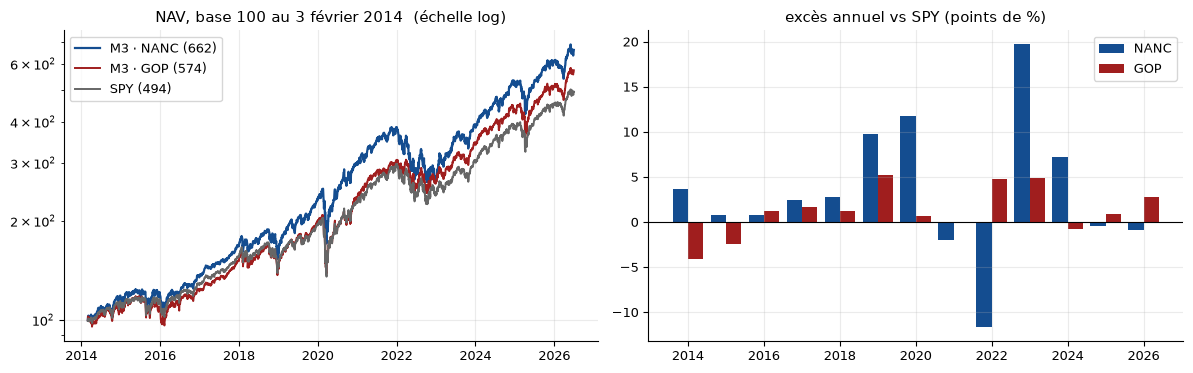

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(M3["NANC"].index, M3["NANC"], color=BLEU,  lw=1.6, label=f"M3 · NANC ({M3['NANC'].iloc[-1]:.0f})")
ax[0].plot(M3["GOP"].index,  M3["GOP"],  color=ROUGE, lw=1.4, label=f"M3 · GOP ({M3['GOP'].iloc[-1]:.0f})")
ax[0].plot(nav_spy_m3.index, nav_spy_m3, color=GRIS,  lw=1.4, label=f"SPY ({nav_spy_m3.iloc[-1]:.0f})")
ax[0].set_yscale("log"); ax[0].set_title("NAV, base 100 au 3 février 2014  (échelle log)"); ax[0].legend()
ax[1].bar(xN_.index - 0.2, xN_.values, width=0.4, color=BLEU,  label="NANC")
ax[1].bar(xG_.index + 0.2, xG_.values, width=0.4, color=ROUGE, label="GOP")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("excès annuel vs SPY (points de %)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_nav.png", dpi=150, bbox_inches="tight"); plt.show()

### §6.3 — À quoi ressemble le portefeuille

In [28]:
i_fin = coupes[-2]
lignes, tops = [], {}
for nom in ["NANC", "GOP"]:
    w = 100 * pd.Series(WPM[("M3 · $ × élus", nom)][i_fin]).sort_values(ascending=False)
    mx, t5, ne = conc(w)
    n_cap = int((w > 100*CAP - 1e-9).sum())            # combien de lignes touchent effectivement le plafond
    lignes.append({"fonds": nom, "titres": len(w), "plus gros poids %": mx, "top-5 %": t5, "N_eff": ne,
                   "lignes au plafond": n_cap})
    tops[nom] = w.head(10).round(2)
display(pd.DataFrame(lignes).set_index("fonds"))
print(f"\ntop-10 à la coupe du {cal[i_fin].date()} :")
display(pd.DataFrame(tops).fillna(""))
print("\nnombre de lignes au plafond, en médiane sur toutes les coupes :")
for nom in ["NANC", "GOP"]:
    m = np.median([sum(1 for x in w.values() if x > CAP - 1e-9)
                   for w in WPM[("M3 · $ × élus", nom)].values() if w])
    print(f"   {nom} : {m:.0f}")

,titres,plus gros poids %,top-5 %,N_eff,lignes au plafond
fonds,,,,,
NANC,150,10.0,42.2,21.6,1
GOP,150,9.0,32.6,32.7,0



top-10 à la coupe du 2026-05-29 :


,NANC,GOP
AAPL,6.34,8.26
AMD,,2.15
AMZN,7.94,3.22
AVGO,6.07,
COP,,1.98
GOOG,9.95,4.19
META,3.28,3.68
MSFT,7.92,8.98
NFLX,1.39,
NVDA,10.0,6.39



nombre de lignes au plafond, en médiane sur toutes les coupes :
   NANC : 2
   GOP : 1


## §7 — D'où vient l'excès : dollars, consensus, ou ni l'un ni l'autre ?

Le score mélange deux informations. On les sépare **à univers identique** — les 150 titres restent ceux que
le score complet désigne, seule la *pondération* change :

| variante | poids | ce qu'elle isole |
|---|---|---|
| **M2 · dollars purs** | $w \propto B_i$ | l'argent misé, sans le consensus |
| **élus seuls** | $w \propto m_i$ | le consensus, sans l'argent |
| **équipondéré** | $w = 1/150$ | ni l'un ni l'autre : la sélection seule |
| **M3** | $w \propto B_i m_i$ | les deux |

C'est une **décomposition**, pas une compétition : le verdict de la méthode se lit sur la ligne M3, quoi que
disent les autres.

In [29]:
ORD = ["équipondéré", "élus seuls", "M2 · dollars purs", "M3 · $ × élus"]
DEC = pd.DataFrame([bilan_ic(SER[(m, nom)], f"{m} — {nom}") for nom in ["NANC", "GOP"] for m in ORD]).set_index("run")
display(DEC[["excès %/an", "t", "IC bas", "IC haut", "α %/an", "t_α", "β", "NAV"]].round(2))

# les mêmes runs vus par le modèle à quatre facteurs : un repère n'a de sens qu'à filtre ET univers identiques
# à ce qu'il éclaire — ces lignes sont donc toutes à θ = ∞, comme M3.
DECF = pd.DataFrame([facteurs(SER[(m, nom)], f"{m} — {nom}") for nom in ["NANC", "GOP"] for m in ORD]).set_index("run")
display(DECF[["α %/an", "t_α"] + FACS].round(3))

,excès %/an,t,IC bas,IC haut,α %/an,t_α,β,NAV
run,,,,,,,,
équipondéré — NANC,-1.38,-1.45,-3.46,0.70,-0.95,-0.72,0.98,430.18
élus seuls — NANC,-0.65,-0.91,-2.22,0.92,-0.41,-0.38,0.99,463.52
M2 · dollars purs — NANC,1.43,1.04,-1.58,4.44,0.37,0.40,1.05,554.22
M3 · $ × élus — NANC,3.40,1.61,-1.19,7.99,1.66,1.36,1.08,661.57
équipondéré — GOP,-1.08,-0.71,-4.39,2.22,-0.67,-0.44,0.96,447.77
élus seuls — GOP,-0.78,-0.75,-3.04,1.49,-0.17,-0.14,0.96,465.58
M2 · dollars purs — GOP,0.49,0.26,-3.62,4.60,0.17,0.10,1.00,522.63
M3 · $ × élus — GOP,1.24,1.61,-0.44,2.91,1.09,1.07,1.00,573.57


,α %/an,t_α,Mkt-RF,SMB,HML,Mom
run,,,,,,
équipondéré — NANC,0.052,0.055,0.955,0.018,0.140,-0.097
élus seuls — NANC,0.384,0.495,0.962,-0.039,0.097,-0.094
M2 · dollars purs — NANC,0.986,1.304,1.019,-0.067,-0.058,-0.073
M3 · $ × élus — NANC,2.092,2.080,1.047,-0.131,-0.146,-0.076
équipondéré — GOP,0.415,0.430,0.938,0.039,0.212,-0.100
élus seuls — GOP,0.589,0.728,0.938,-0.057,0.148,-0.099
M2 · dollars purs — GOP,1.227,1.015,0.974,0.057,0.171,-0.083
M3 · $ × élus — GOP,1.652,1.792,0.979,-0.081,0.049,-0.073


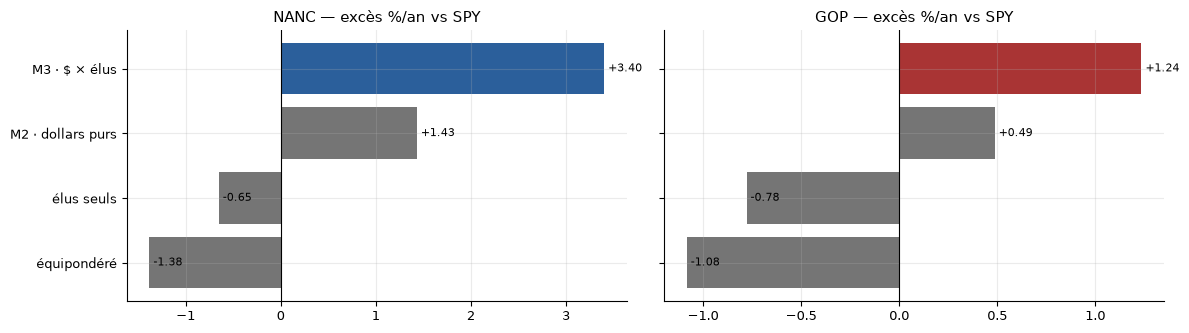

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for k, nom in enumerate(["NANC", "GOP"]):
    v = [bilan(SER[(m, nom)], m)["excès %/an"] for m in ORD]
    ax[k].barh(range(len(ORD)), v, color=[GRIS, GRIS, GRIS, BLEU if nom == "NANC" else ROUGE], alpha=.9)
    ax[k].set_yticks(range(len(ORD))); ax[k].set_yticklabels(ORD)
    ax[k].axvline(0, color="k", lw=.8); ax[k].set_title(f"{nom} — excès %/an vs SPY")
    for j, x in enumerate(v): ax[k].text(x, j, f" {x:+.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_decomposition.png", dpi=150, bbox_inches="tight"); plt.show()

### §7.1 — Le filtre anti-bruit, et son balayage publié en entier

Un élu qui déclare 300 opérations le même jour ne prend pas 300 décisions : son courtier rééquilibre un
mandat. Le filtre écarte toute opération issue d'un dépôt de $\theta$ opérations ou plus.

**$\theta = 50$ est la valeur déclarée d'avance** — elle vient de la description d'un gérant du fonds, pas
d'un réglage sur nos rendements. Le balayage ci-dessous est publié **en entier** pour montrer la pente ; il
ne sert pas à choisir. M3 n'applique pas le filtre ; M4 l'applique.

In [31]:
for parti, nom in PARTIS:
    tot = df[(df.party == parti) & (df.op == "buy")].A.sum()
    ecarte = df[(df.party == parti) & (df.op == "buy") & (df.taille_depot >= SEUIL_BRUIT)].A.sum()
    print(f"{nom} : le filtre θ={SEUIL_BRUIT} écarte {100*ecarte/tot:.0f} % du $ acheté "
          f"({ecarte/1e6:,.0f} M$ sur {tot/1e6:,.0f})")

BAL = []
for nom in ["NANC", "GOP"]:
    for lab in ["θ = 10", "θ = 20", "M4 · + filtre θ=50", "θ = 100", "M3 · $ × élus"]:
        b = bilan(SER[(lab, nom)], lab)
        BAL.append({"fonds": nom, "θ": {"M4 · + filtre θ=50": "θ = 50  (M4)",
                                        "M3 · $ × élus": "θ = ∞  (M3)"}.get(lab, lab),
                    "excès %/an": b["excès %/an"], "t": b["t"], "α %/an": b["α %/an"],
                    "t_α": b["t_α"], "β": b["β"], "NAV": b["NAV"]})
display(pd.DataFrame(BAL).set_index(["fonds", "θ"]).round(2))
print("↑ balayage publié en entier — le verdict de la méthode se lit à θ = ∞ (M3), celui de M4 à θ = 50")

NANC : le filtre θ=50 écarte 54 % du $ acheté (388 M$ sur 716)
GOP : le filtre θ=50 écarte 58 % du $ acheté (514 M$ sur 891)


excès %/an     t  α %/an   t_α     β     NAV
fonds θ                                                         
NANC  θ = 10              4.71  1.07    0.60  0.25  1.15  634.37
      θ = 20              4.62  1.10    0.78  0.33  1.15  642.63
      θ = 50  (M4)        5.14  1.30    1.42  0.65  1.15  699.97
      θ = 100             4.75  1.31    1.36  0.69  1.14  692.30
      θ = ∞  (M3)         3.40  1.61    1.66  1.36  1.08  661.57
GOP   θ = 10              3.02  1.75    2.77  1.75  0.99  706.64
      θ = 20              2.14  1.44    1.88  1.28  0.99  637.64
      θ = 50  (M4)        1.44  0.98    1.54  1.19  0.98  589.88
      θ = 100             1.64  1.73    1.60  1.48  0.99  602.79
      θ = ∞  (M3)         1.24  1.61    1.09  1.07  1.00  573.57

↑ balayage publié en entier — le verdict de la méthode se lit à θ = ∞ (M3), celui de M4 à θ = 50


## §8 — Première épreuve : le risque

Un excès peut n'être qu'un pari de style rémunéré. On régresse donc sur les quatre facteurs de
Fama-French-Carhart, et on regarde ce qui survit.

**Lecture des chargements** : $\beta_S < 0$ = le portefeuille penche vers les **grandes** capitalisations ;
$\beta_H < 0$ = vers la **croissance** plutôt que la *value* ; $\beta_U$ = exposition au **momentum**.

In [32]:
FAC = pd.DataFrame([facteurs(M3[nom], f"M3 · {nom}") for nom in ["NANC", "GOP"]]
                   + [facteurs(nav_spy_full, "SPY (repère)")]).set_index("run")
display(FAC[["α %/an", "t_α"] + FACS + ["n j"]].round(3))
print("\nà comparer à l'α du modèle marché seul :")
display(pd.DataFrame([bilan(M3[nom], f"M3 · {nom}") for nom in ["NANC", "GOP"]]).set_index("run")[["α %/an", "t_α", "β"]].round(3))

,α %/an,t_α,Mkt-RF,SMB,HML,Mom,n j
run,,,,,,,
M3 · NANC,2.092,2.080,1.047,-0.131,-0.146,-0.076,3059
M3 · GOP,1.652,1.792,0.979,-0.081,0.049,-0.073,3059
SPY (repère),0.040,0.115,0.980,-0.123,0.012,-0.009,3352



à comparer à l'α du modèle marché seul :


,α %/an,t_α,β
run,,,
M3 · NANC,1.660,1.357,1.080
M3 · GOP,1.093,1.067,1.004


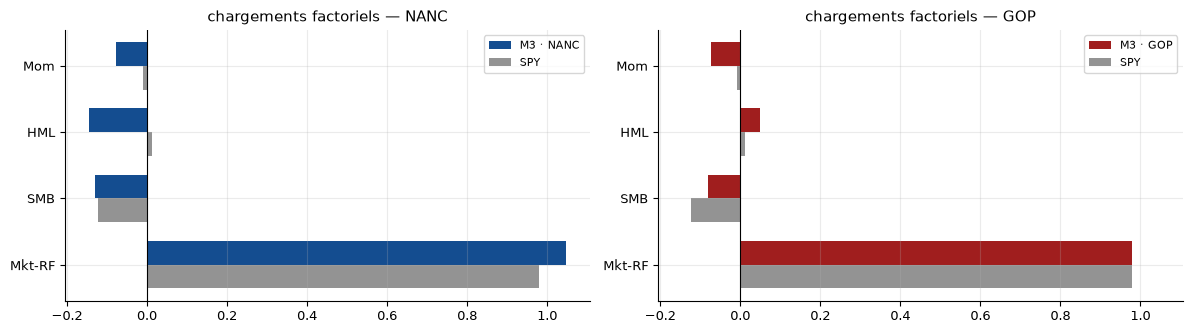

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for k, nom in enumerate(["NANC", "GOP"]):
    v = [FAC.loc[f"M3 · {nom}", c] for c in FACS]
    s = [FAC.loc["SPY (repère)", c] for c in FACS]
    y = np.arange(len(FACS))
    ax[k].barh(y + .18, v, height=.36, color=BLEU if nom == "NANC" else ROUGE, label=f"M3 · {nom}")
    ax[k].barh(y - .18, s, height=.36, color=GRIS, alpha=.7, label="SPY")
    ax[k].set_yticks(y); ax[k].set_yticklabels(FACS); ax[k].axvline(0, color="k", lw=.8)
    ax[k].set_title(f"chargements factoriels — {nom}"); ax[k].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_facteurs.png", dpi=150, bbox_inches="tight"); plt.show()

### §8.1 — $\alpha$ et $\beta$ glissants sur 252 jours

Les chiffres ci-dessus sont *plein-échantillon* : ils écrasent douze ans en un nombre. On les regarde au fil
du temps, sur une fenêtre glissante d'un an :
$\;\hat\beta_t = \mathrm{cov}_W(y,x)/\mathrm{var}_W(x)$, $\;\hat\alpha_t = (\bar y_W - \hat\beta_t \bar x_W)\times 252$.

NANC — β glissant méd 1.06 [0.95 ; 1.27] σ 0.07  ·  α glissant méd +2.01 %/an [-11.0 ; +13.2] · α > 0 71 % du temps
GOP — β glissant méd 1.00 [0.90 ; 1.13] σ 0.05  ·  α glissant méd +1.67 %/an [-6.0 ; +8.0] · α > 0 71 % du temps


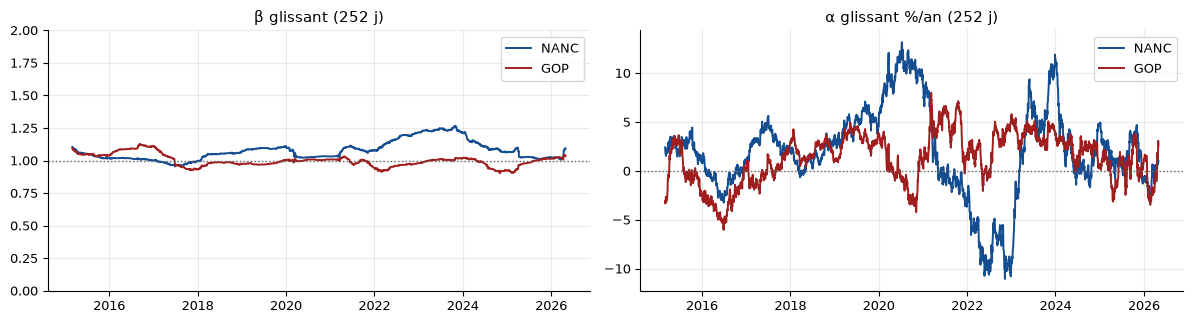

In [34]:
RA = {nom: roll_ab(M3[nom]) for nom in ["NANC", "GOP"]}
for nom in ["NANC", "GOP"]:
    aa, bb, _, _ = RA[nom]
    print(f"{nom} — β glissant méd {bb.median():.2f} [{bb.min():.2f} ; {bb.max():.2f}] σ {bb.std():.2f}  ·  "
          f"α glissant méd {aa.median():+.2f} %/an [{aa.min():+.1f} ; {aa.max():+.1f}] · α > 0 {100*(aa>0).mean():.0f} % du temps")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    aa, bb, _, _ = RA[nom]
    ax[0].plot(bb.index, bb, color=c, lw=1.4, label=nom)
    ax[1].plot(aa.index, aa, color=c, lw=1.4, label=nom)
ax[0].axhline(1, color=GRIS, ls=":", lw=1); ax[0].set_ylim(0, 2)
ax[0].set_title(f"β glissant ({Wab} j)"); ax[0].legend()
ax[1].axhline(0, color=GRIS, ls=":", lw=1); ax[1].set_title(f"α glissant %/an ({Wab} j)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_rolling.png", dpi=150, bbox_inches="tight"); plt.show()

### §8.2 — Validation : le glissant est bien une régression

`cov/var` et `ȳ − β x̄` doivent redonner, sur une fenêtre donnée, exactement ce que rendrait une régression
des moindres carrés. Et le $\beta$ calculé sur l'échantillon entier doit retomber sur celui du §6.

In [35]:
for nom in ["NANC", "GOP"]:
    aa, bb, y, x = RA[nom]
    # (1) sur la dernière fenêtre de 252 jours, comparer à np.polyfit
    yy, xx = y.iloc[-Wab:].values, x.iloc[-Wab:].values
    b_p, a_p = np.polyfit(xx, yy, 1)
    assert abs(bb.iloc[-1] - b_p) < 1e-9,       f"{nom} : β glissant ≠ polyfit ({bb.iloc[-1]:.9f} vs {b_p:.9f})"
    assert abs(aa.iloc[-1] - a_p*252*100) < 1e-6, f"{nom} : α glissant ≠ polyfit"
    # (2) le β plein-échantillon du même chemin doit retomber sur celui du bilan
    b_full = np.polyfit(x.values, y.values, 1)[0]
    assert abs(b_full - MES[(nom, "β")]) < 1e-9, f"{nom} : β plein-échantillon {b_full:.6f} ≠ bilan {MES[(nom,'β')]:.6f}"
    print(f"✅ {nom} — glissant ≡ polyfit (β {bb.iloc[-1]:.6f}) · β plein-échantillon {b_full:.4f} ≡ celui du §6")

✅ NANC — glissant ≡ polyfit (β 1.092262) · β plein-échantillon 1.0804 ≡ celui du §6
✅ GOP — glissant ≡ polyfit (β 1.035564) · β plein-échantillon 1.0037 ≡ celui du §6


## §9 — Seconde épreuve : le coût

Une méthode qui se recompose sans arrêt paie des frais sans arrêt. Deux questions, dans l'ordre.

**Ce que ça coûte.** La rotation d'une coupe est
$\;\mathrm{TO}_t = \tfrac12 \sum_i |w^{\text{réalisé}}_i - w^{\text{dérivé}}_i|$, et on facture
$V_t \leftarrow V_t\,(1 - 2\,\mathrm{TO}_t\,c)$ avec $c = 10$ points de base (0,10 %) — le facteur 2 parce
qu'on paie à l'achat **et** à la vente.

**Faut-il ralentir.** On peut brider la rotation à $\tau_{\max}$ par mois :
$\lambda_R = \min(1, \tau_{\max}/\mathrm{TO}_t)$, actif seulement quand $\mathrm{TO}_t > \tau_{\max}$. Le
balayage est **publié en entier**, et la règle est écrite d'avance : *on ne retient le frein que s'il
améliore les deux partis*.

**Pourquoi M3 est lente.** Sa fenêtre fait trois ans : d'un mois sur l'autre, un trente-sixième du signal se
renouvelle. Une méthode à fenêtre d'un mois en renouvelle la moitié.

In [36]:
COUT_BPS = 10.0                                   # pb par aller-retour — DÉCLARÉ AVANT tout résultat
PLAFONDS = [np.inf, 0.25, 0.10, 0.05, 0.02]       # τ_max testés, publiés en entier

def rotation(WP, tau_max=np.inf, cuts=None):
    # rotation RÉALISÉE, telle que le moteur la produit (≠ celle de la cible dès que le frein mord)
    cuts = coupes if cuts is None else cuts
    _, tr = run_livre(WP, tau_max, cuts=cuts)
    idx = pd.DatetimeIndex([cal[cuts[j]+1] for j in range(1, len(cuts)-1)][:len(tr)])
    s   = pd.Series(tr, index=idx)
    n   = s.groupby(s.index.year).size()
    return s, 100*s.groupby(s.index.year).sum()[n[n >= 6].index]     # années complètes seulement

VIT, ROT = [], {}
for nom in ["NANC", "GOP"]:
    mens, an = rotation(WPM[("M3 · $ × élus", nom)])
    ROT[nom] = an
    VIT.append({"fonds": nom, "rotation méd. %/mois": 100*mens.median(),
                "rotation méd. %/an": an.median(), "rotation moy. %/an": an.mean(),
                "min %/an": an.min(), "max %/an": an.max()})
display(pd.DataFrame(VIT).set_index("fonds").round(1))
print("le fonds réel publie 44 · 62 · 10 % pour NANC et 46 · 54 · 16 % pour GOP (exercices 2023, 2024, 2025)")
print("⚠️ moyenne ≫ médiane : quelques années de forte recomposition tirent le coût — c'est la MOYENNE qui le fixe")

,rotation méd. %/mois,rotation méd. %/an,rotation moy. %/an,min %/an,max %/an
fonds,,,,,
NANC,4.9,65.6,71.8,33.6,139.6
GOP,5.3,69.2,76.9,35.8,164.4


le fonds réel publie 44 · 62 · 10 % pour NANC et 46 · 54 · 16 % pour GOP (exercices 2023, 2024, 2025)
⚠️ moyenne ≫ médiane : quelques années de forte recomposition tirent le coût — c'est la MOYENNE qui le fixe


In [37]:
COUT = []
for nom in ["NANC", "GOP"]:
    brut = SER[("M3 · $ × élus", nom)]
    net  = run_livre(WPM[("M3 · $ × élus", nom)], np.inf, cout_bps=COUT_BPS)[0]
    bb, bn = bilan(brut, nom), bilan(net, nom)
    COUT.append({"fonds": nom, "excès brut %/an": bb["excès %/an"], "excès net %/an": bn["excès %/an"],
                 "coût pt/an": bb["excès %/an"] - bn["excès %/an"],
                 "α₁ net": bn["α %/an"], "t_α₁ net": bn["t_α"], "β net": bn["β"],
                 "α₄ brut": facteurs(brut, nom)["α %/an"], "α₄ net": facteurs(net, nom)["α %/an"],
                 "NAV brute": bb["NAV"], "NAV nette": bn["NAV"]})
display(pd.DataFrame(COUT).set_index("fonds").round(2))

,excès brut %/an,excès net %/an,coût pt/an,α₁ net,t_α₁ net,β net,α₄ brut,α₄ net,NAV brute,NAV nette
fonds,,,,,,,,,,
NANC,3.40,3.23,0.17,1.51,1.23,1.08,2.09,1.94,661.57,648.69
GOP,1.24,1.06,0.18,0.93,0.91,1.00,1.65,1.49,573.57,561.66


In [38]:
# VALIDATION §9 — contrôle EXACT : les poids étant invariants d'échelle, facturer des frais ne change pas
# les rotations, seulement le niveau de la NAV. Donc NAV_nette / NAV_brute doit valoir exactement
#     ∏_t (1 − 2·TO_t·c)   sur TOUTES les coupes, premier déploiement compris (TO = ½ : on achète tout une fois).
for nom in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", nom)]
    brut = run_livre(WP, np.inf)[0]
    net, tr = run_livre(WP, np.inf, cout_bps=COUT_BPS)
    facteur = (1 - 2*0.5*COUT_BPS/1e4) * np.prod(1 - 2*tr*COUT_BPS/1e4)   # ½ = le 1er déploiement
    observe = net.iloc[-1] / brut.iloc[-1]
    assert abs(observe - facteur) < 1e-12, f"{nom} : ratio {observe:.12f} ≠ ∏(1−2·TO·c) = {facteur:.12f}"
    print(f"✅ {nom} — NAV nette / NAV brute = {observe:.9f} ≡ ∏(1 − 2·TO·c) sur {len(tr)+1} coupes "
          f"(écart {abs(observe-facteur):.1e})")
    print(f"     soit {brut.iloc[-1]:.2f} → {net.iloc[-1]:.2f} · rotation moyenne {ROT[nom].mean():.0f} %/an "
          f"× 2 × {COUT_BPS:.0f} pb ≈ {2*ROT[nom].mean()/100*COUT_BPS/1e4*100:.2f} pt/an")

✅ NANC — NAV nette / NAV brute = 0.980522274 ≡ ∏(1 − 2·TO·c) sur 148 coupes (écart 4.8e-15)
     soit 661.57 → 648.69 · rotation moyenne 72 %/an × 2 × 10 pb ≈ 0.14 pt/an
✅ GOP — NAV nette / NAV brute = 0.979224158 ≡ ∏(1 − 2·TO·c) sur 148 coupes (écart 4.3e-15)
     soit 573.57 → 561.66 · rotation moyenne 77 %/an × 2 × 10 pb ≈ 0.15 pt/an


### §9.1 — Faut-il ralentir ? Le balayage du frein, net de frais

La règle a été écrite avant de regarder : **on ne retient le frein que s'il améliore les deux partis.**

excès net %/an     t  α %/an     NAV
fonds τ_max                                          
NANC  aucun                3.23  1.54    1.51  648.69
      25 %/mois            3.24  1.54    1.51  649.20
      10 %/mois            3.25  1.55    1.51  650.38
      5 %/mois             3.26  1.55    1.56  652.10
      2 %/mois             3.16  1.56    1.58  649.30
GOP   aucun                1.06  1.35    0.93  561.66
      25 %/mois            1.02  1.27    0.89  559.29
      10 %/mois            1.01  1.28    0.89  558.87
      5 %/mois             1.13  1.44    1.08  569.40
      2 %/mois             0.58  0.77    0.79  538.34

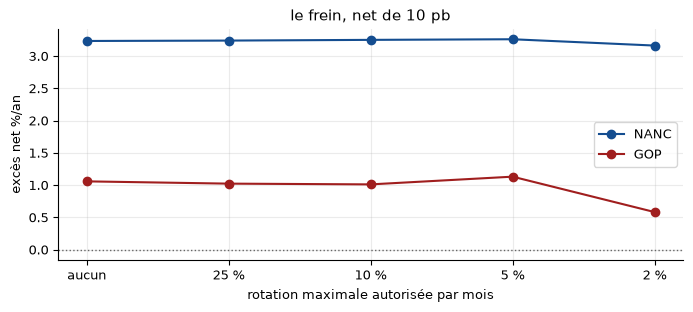

gain (ou perte) par rapport à l'absence de frein, en points de % par an :
    25 %/mois — NANC +0.01 · GOP -0.04   → min -0.04
    10 %/mois — NANC +0.02 · GOP -0.05   → min -0.05
     5 %/mois — NANC +0.03 · GOP +0.07   → min +0.03
     2 %/mois — NANC -0.07 · GOP -0.48   → min -0.48

→ RÈGLE DÉCLARÉE D'AVANCE : le frein n'est retenu que s'il améliore les DEUX partis.
   plafonds qui passent la règle : ['5 %/mois']

   profil du gain minimal, du plafond le plus lâche au plus serré :
      -0.04 → -0.05 → +0.03 → -0.48
   2 changement(s) de signe sur 3 pas.
   ⚠️ le seul plafond qui passe la règle est ENTOURÉ de plafonds qui échouent. Serrer la
      contrainte devrait agir dans un sens, pas alterner : ce profil est celui du bruit, pas
      d'un effet. Le gain de +0.03 pt est du même ordre que l'écart entre voisins.
   → le frein n'est PAS retenu : la règle est nécessaire, elle n'est pas suffisante.


In [39]:
FREIN = []
for nom in ["NANC", "GOP"]:
    for tm in PLAFONDS:
        v = run_livre(WPM[("M3 · $ × élus", nom)], tm, cout_bps=COUT_BPS)[0]
        b = bilan(v, nom)
        FREIN.append({"fonds": nom, "τ_max": "aucun" if tm == np.inf else f"{100*tm:.0f} %/mois",
                      "excès net %/an": b["excès %/an"], "t": b["t"], "α %/an": b["α %/an"], "NAV": b["NAV"]})
FREIN = pd.DataFrame(FREIN)
display(FREIN.set_index(["fonds", "τ_max"]).round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    s = FREIN[FREIN.fonds == nom]
    ax.plot(range(len(PLAFONDS)), s["excès net %/an"].values, "o-", color=c, lw=1.5, label=nom)
ax.set_xticks(range(len(PLAFONDS))); ax.set_xticklabels(["aucun", "25 %", "10 %", "5 %", "2 %"])
ax.set_xlabel("rotation maximale autorisée par mois"); ax.set_ylabel("excès net %/an")
ax.axhline(0, color=GRIS, ls=":", lw=1); ax.set_title(f"le frein, net de {COUT_BPS:.0f} pb"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_frein.png", dpi=150, bbox_inches="tight"); plt.show()

g = FREIN[FREIN["τ_max"] != "aucun"].merge(
    FREIN[FREIN["τ_max"] == "aucun"][["fonds", "excès net %/an"]].rename(columns={"excès net %/an": "sans frein"}),
    on="fonds")
g["gain pt"] = g["excès net %/an"] - g["sans frein"]
lbl = [f"{100*tm:.0f} %/mois" for tm in PLAFONDS[1:]]                 # du plus lâche au plus serré
print("gain (ou perte) par rapport à l'absence de frein, en points de % par an :")
for k in lbl:
    s = g[g["τ_max"] == k].set_index("fonds")["gain pt"]
    print(f"   {k:>10s} — NANC {s['NANC']:+.2f} · GOP {s['GOP']:+.2f}   → min {s.min():+.2f}")
ok = g.groupby("τ_max")["gain pt"].min()
gagnants = [k for k in lbl if ok[k] > 0]
print(f"\n→ RÈGLE DÉCLARÉE D'AVANCE : le frein n'est retenu que s'il améliore les DEUX partis.")
print(f"   aucun plafond ne le fait — le frein n'est pas retenu" if not gagnants
      else f"   plafonds qui passent la règle : {gagnants}")

# ── le test qui tranche : un effet réel serait MONOTONE en τ_max ──
serie = [ok[k] for k in lbl]                      # du plus lâche (25 %) au plus serré (2 %)
signes = [np.sign(x) for x in serie]
alterne = sum(1 for a, b in zip(signes, signes[1:]) if a != b)
print(f"\n   profil du gain minimal, du plafond le plus lâche au plus serré :")
print("      " + " → ".join(f"{ok[k]:+.2f}" for k in lbl))
print(f"   {alterne} changement(s) de signe sur {len(lbl)-1} pas.")
if gagnants and alterne >= 2:
    print(f"   ⚠️ le seul plafond qui passe la règle est ENTOURÉ de plafonds qui échouent. Serrer la")
    print(f"      contrainte devrait agir dans un sens, pas alterner : ce profil est celui du bruit, pas")
    print(f"      d'un effet. Le gain de {max(ok):+.2f} pt est du même ordre que l'écart entre voisins.")
    print(f"   → le frein n'est PAS retenu : la règle est nécessaire, elle n'est pas suffisante.")

## §10 — Ce qui est prêt pour la variante ETF

**Aucune mesure dans cette section.** La question posée est : *et si, au lieu d'acheter les titres que les
élus achètent, on achetait l'ETF sectoriel correspondant ?* Un achat de NVDA devient un achat de XLK. Cette
section inventorie ce que le notebook a déjà sous la main, et **énonce les trois problèmes avant de calculer
quoi que ce soit** — pour qu'aucune réponse ne puisse être un réglage trouvé après coup.

### Ce qui est déjà là
- la colonne `etf_proxy`, chargée au §1.1, renseignée sur **100 %** des lignes (mapping GICS → SPDR) ;
- les **onze** séries de prix SPDR, chargées au §1.3, sans effet sur le flux (prouvé au §1.5) ;
- le point de substitution `_instrument()` au §4 : `univers="etf"` suffit, le moteur ne bouge pas d'une ligne.

### Les trois problèmes, énoncés d'avance
1. **Le plafond tient à une ligne près.** Il n'a de solution que si l'univers compte au moins
   $\lceil 1/c \rceil = 10$ instruments — et il y en a **onze**. À $c = 10\,\%$ le plafond est donc
   *applicable, mais tout juste* : la marge est d'une seule ligne, et il ne mord que sur les secteurs qui
   dépassent 10 % du score. *(À l'ancien plafond de 8,5 % il aurait fallu 12 instruments : il aurait aplati
   les onze secteurs à un onzième chacun et effacé le score — la §10.1 le montre.)*
2. **La sélection disparaît.** $|\mathcal{U}| = 11 < N = 150$ : le top-150 ne coupe plus rien. Or la
   sélection est le seul levier qui ait jamais fait une différence dans ce projet.
3. **Deux secteurs n'existent pas au début.** XLRE ne cote qu'à partir d'octobre 2015, XLC de juin 2018 —
   sur un historique qui démarre en 2014. Laisser `vivant()` faire son travail est gratuit et sans regard
   vers le futur, mais **réaffecte le poids de ces secteurs vers les autres**, ce qui n'est pas neutre.

In [40]:
# (1) ce que pèsent les deux secteurs absents au début, en $ acheté et en coupes
dispo = {t: cal[NFIRST[t]].date() for t in ETF_SECT}
print("première cotation des 11 SPDR :")
print("   " + " · ".join(f"{t} {d}" for t, d in sorted(dispo.items(), key=lambda kv: kv[1])))

for t in ["XLRE", "XLC"]:
    d0 = cal[NFIRST[t]]
    nc = sum(1 for i in coupes[:-1] if i < NFIRST[t])
    print(f"\n{t} — cote à partir du {d0.date()} · {nc} coupes sur {len(coupes)-1} sans lui")
    for parti, nom in PARTIS:
        m = (df.party == parti) & (df.op == "buy")
        avant = m & (df.disclosure_date < d0)
        # ce qui compte : SUR LA PÉRIODE OÙ LE SECTEUR N'EXISTE PAS, quelle part du signal serait réaffectée
        part_per = df.loc[avant & (df.etf_proxy == t), "A"].sum() / df.loc[avant, "A"].sum()
        part_tot = df.loc[avant & (df.etf_proxy == t), "A"].sum() / df.loc[m, "A"].sum()
        print(f"     {nom} : {100*part_per:.1f} % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs "
              f"({100*part_tot:.1f} % du $ de tout l'échantillon)")

première cotation des 11 SPDR :
   XLB 2012-01-03 · XLE 2012-01-03 · XLF 2012-01-03 · XLI 2012-01-03 · XLK 2012-01-03 · XLP 2012-01-03 · XLU 2012-01-03 · XLV 2012-01-03 · XLY 2012-01-03 · XLRE 2015-10-08 · XLC 2018-06-19

XLRE — cote à partir du 2015-10-08 · 20 coupes sur 148 sans lui
     NANC : 0.7 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (0.1 % du $ de tout l'échantillon)
     GOP : 1.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (0.2 % du $ de tout l'échantillon)

XLC — cote à partir du 2018-06-19 · 52 coupes sur 148 sans lui
     NANC : 7.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (1.5 % du $ de tout l'échantillon)
     GOP : 7.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (2.4 % du $ de tout l'échantillon)


In [41]:
# (2) à quoi ressemblerait l'univers sectoriel : le score agrégé par secteur, à la dernière coupe
i1 = coupes[-2]
for parti, nom in PARTIS:
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
    s = (g.groupby("etf_proxy").A.sum() * g.groupby("etf_proxy").bioguide_id.nunique()).dropna()
    s = (100 * s / s.sum()).sort_values(ascending=False)
    print(f"\n{nom} — score par secteur à la coupe du {cal[i1].date()} (%, avant tout plafond) :")
    print("   " + " · ".join(f"{k} {v:.1f}" for k, v in s.items()))
    print(f"   plus gros secteur {s.iloc[0]:.1f} % · top-3 {s.head(3).sum():.1f} % · N_eff {1/((s/100)**2).sum():.1f}")


NANC — score par secteur à la coupe du 2026-05-29 (%, avant tout plafond) :
   XLK 45.2 · XLV 10.5 · XLY 9.6 · XLF 8.9 · XLC 8.7 · XLI 6.8 · XLP 5.0 · XLRE 2.1 · XLB 1.6 · XLE 0.8 · XLU 0.8
   plus gros secteur 45.2 % · top-3 65.3 % · N_eff 4.0

GOP — score par secteur à la coupe du 2026-05-29 (%, avant tout plafond) :
   XLK 31.9 · XLV 14.6 · XLI 13.1 · XLF 12.9 · XLY 8.5 · XLE 5.6 · XLC 4.9 · XLP 4.3 · XLB 2.5 · XLRE 1.1 · XLU 0.7
   plus gros secteur 31.9 % · top-3 59.5 % · N_eff 5.8


### §10.1 — La marge du plafond sur onze secteurs

Un plafond $c$ n'admet de solution que si $\lvert\mathcal U\rvert \, c \ge 1$, c'est-à-dire s'il y a au moins
$\lceil 1/c\rceil$ instruments. Avec onze secteurs, cela départage exactement les deux valeurs qu'a connues
ce projet : **8,5 % en exigerait douze — il est inapplicable** et rendrait l'équipondéré ; **10 % en exige
dix — il passe, avec une ligne de marge**.

In [42]:
# le même score sectoriel, passé aux deux plafonds : l'un efface le score, l'autre le conserve
demo = pd.Series([62.9, 10.4, 9.6, 4.2, 3.7, 3.4, 2.2, 1.9, 1.8, 0.05, 0.05], index=ETF_SECT)
v_in = demo / demo.sum()
print(f"score en entrée (%)      : {' · '.join(f'{100*x:.1f}' for x in v_in.values)}")
for c in [0.085, CAP]:
    out  = cap_poids(v_in.copy(), c)
    plat = np.abs(out.values - 1/len(out)).max() < 1e-12
    print(f"après cap à {100*c:4.1f} % (⌈1/c⌉={math.ceil(1/c):2d}) : "
          f"{' · '.join(f'{100*x:.1f}' for x in out.values)}"
          f"   {'← ÉQUIPONDÉRÉ : le score est effacé' if plat else '← le score survit'}")

# les deux faits, assertés
assert np.abs(cap_poids(v_in.copy(), 0.085).values - 1/11).max() < 1e-12, "8,5 % devrait aplatir"
assert np.abs(cap_poids(v_in.copy(), CAP).values   - 1/11).max() > 1e-3,  "10 % ne devrait PAS aplatir"
print(f"\n✅ ⌈1/0,085⌉ = 12 > 11 → inapplicable · ⌈1/{CAP:.2f}⌉ = {math.ceil(1/CAP)} ≤ 11 → applicable")
print(f"   le passage du plafond à {100*CAP:.0f} % rend donc la variante ETF mesurable avec un plafond,")
print(f"   ce qui n'était pas le cas à 8,5 % — c'est un effet de bord du choix de spécification.")

score en entrée (%)      : 62.8 · 10.4 · 9.6 · 4.2 · 3.7 · 3.4 · 2.2 · 1.9 · 1.8 · 0.0 · 0.0
après cap à  8.5 % (⌈1/c⌉=12) : 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1   ← ÉQUIPONDÉRÉ : le score est effacé
après cap à 10.0 % (⌈1/c⌉=10) : 10.0 · 10.0 · 10.0 · 10.0 · 10.0 · 10.0 · 10.0 · 10.0 · 10.0 · 5.0 · 5.0   ← le score survit

✅ ⌈1/0,085⌉ = 12 > 11 → inapplicable · ⌈1/0.10⌉ = 10 ≤ 11 → applicable
   le passage du plafond à 10 % rend donc la variante ETF mesurable avec un plafond,
   ce qui n'était pas le cas à 8,5 % — c'est un effet de bord du choix de spécification.


### §10.2 — Les deux arbitrages à trancher avant le premier calcul

**(a) Le plafond.** La seule option qui n'introduit aucun réglage est de le retirer et de publier les deux
bornes : `cap = 1` (le score pur, rien d'ajouté) et `cap = 1/11` (le plus petit plafond faisable, c'est-à-dire
l'équipondéré sectoriel). Tout résultat se situe alors entre les deux, et on n'a rien choisi. Reste à
décider s'il faut, pour comparer ce qui est comparable, rejouer **aussi** M3-titres sans plafond.

**(b) La fenêtre.** Garder 2014-2026 en laissant `vivant()` gérer les deux secteurs manquants, c'est
conserver treize années — mais le poids réaffecté part vers les secteurs qui ont le mieux performé, donc
**dans le sens du résultat**. Se restreindre à juin 2018 → 2026 supprime le biais mais tombe à huit années,
et impose de rejouer M3-titres sur la même fenêtre. La décision doit être écrite avant de voir les chiffres.

⚠️ **Ce qu'il ne faut pas faire** : substituer VOX à XLC avant 2018. Le secteur « Communication Services »
a été créé en septembre 2018 en absorbant Google et Meta (venus de la technologie) et Disney et Netflix
(venus de la consommation discrétionnaire). Le VOX d'avant 2018 ne contient pas les titres qui *font* ce
secteur : le substitut fabriquerait un rendement sans rapport avec ce qu'on cherche à mesurer.

## §11 — La variante ETF : acheter le secteur au lieu du titre

**La question.** Les élus achètent NVDA ; et si l'on achetait XLK, l'ETF du secteur technologique ? La règle
ne change pas d'une virgule — même fenêtre de trois ans, mêmes achats, même score $B_i \times m_i$, même
exécution au close J+1. **Seul l'instrument change** : chaque titre est remplacé par son ETF sectoriel, et
les scores s'agrègent en onze lignes au lieu de cent cinquante.

$$s_{\text{XLK},t} \;=\; \Big(\textstyle\sum_{k\,:\,\varphi(i_k)=\text{XLK}} A_k\Big) \times \#\{\text{élus ayant acheté un titre du secteur}\}$$

où $\varphi$ est la carte titre $\to$ secteur GICS $\to$ SPDR, déjà présente dans la donnée (`etf_proxy`).

### Les quatre runs, déclarés avant de les lancer

Les deux difficultés du §10 ont été tranchées **en publiant les deux côtés plutôt qu'en choisissant** :

| run | plafond | pourquoi il est là |
|---|---|---|
| **ETF · score** | 10 % *(et sans plafond)* | la spécification, au plafond retenu et sans plafond |
| **ETF · équipondéré** | $1/11$ | le plus petit plafond *faisable* — donc la borne « pondération effacée » |
| **titres · score** | aucun | pour que la comparaison oppose deux runs **sans** plafond |
| **titres · M3** | 10 % | la référence publiée, rappelée pour situer |

Et deux fenêtres, pour la même raison : **2014-2026** (tout l'historique, mais deux secteurs manquent au
début) et **2019-2026** (la première année civile entière où les onze SPDR cotent tous).

**Ce qui est attendu, et qu'il faut écrire avant de regarder** : un portefeuille de onze secteurs est un
portefeuille de marché légèrement incliné. On s'attend à $\beta \approx 1$, à une volatilité plus basse, et
à un excès qui s'efface — **les runs sont construits et validés ci-dessous ; leur analyse complète, et la démonstration que cette baisse mesure le prix d'un pari sectoriel (non une perte d'information), est au §12.**

In [43]:
CAP_EQ = 1/11                                      # le plus petit plafond faisable sur 11 instruments
D19    = pd.Timestamp("2019-01-01")                # 1ʳᵉ année civile entière où les 11 SPDR cotent

KWE = {f"ETF · score (cap {100*CAP:.0f} %)": dict(univers="etf", cap=CAP),   # possible depuis c = 10 %
       "ETF · score (sans plafond)":       dict(univers="etf",    cap=1.0),
       "ETF · équipondéré":                dict(univers="etf",    cap=CAP_EQ),
       "titres · score (sans plafond)":    dict(univers="titres", cap=1.0)}
LAB_M3 = f"titres · M3 (cap {100*CAP:.0f} %)"
WPE, SERE = {}, {}
t0 = time.time()
for parti, nom in PARTIS:
    for m, kw in KWE.items():
        WPE[(m, nom)] = cibles_methode(parti, **kw)
        SERE[(m, nom)] = run_livre(WPE[(m, nom)], np.inf)[0]
for nom in ["NANC", "GOP"]:                        # la référence publiée, déjà calculée
    WPE[(LAB_M3, nom)]  = WPM[("M3 · $ × élus", nom)]
    SERE[(LAB_M3, nom)] = SER[("M3 · $ × élus", nom)]

ORD_E = [LAB_M3, "titres · score (sans plafond)", f"ETF · score (cap {100*CAP:.0f} %)",
         "ETF · score (sans plafond)", "ETF · équipondéré"]
n_lig = {m: int(np.median([len(WPE[(m, "NANC")][i]) for i in coupes[:-1] if WPE[(m, "NANC")][i]])) for m in ORD_E}
print(f"{len(KWE)*2} jeux de cibles calculés en {time.time()-t0:.1f} s")
print("lignes détenues (médiane, NANC) — " + " · ".join(f"{m} : {n}" for m, n in n_lig.items()))

8 jeux de cibles calculés en 6.7 s
lignes détenues (médiane, NANC) — titres · M3 (cap 10 %) : 150 · titres · score (sans plafond) : 150 · ETF · score (cap 10 %) : 11 · ETF · score (sans plafond) : 11 · ETF · équipondéré : 11


### §11.1 — Ce que le repli sur les secteurs manquants coûte vraiment

XLRE n'existe pas avant octobre 2015, XLC avant juin 2018. Quand un secteur manque, son poids ne disparaît
pas : il est **redistribué sur les autres**. On mesure ici, coupe par coupe, quelle fraction du score tombe
dans un secteur non coté — c'est exactement la part du signal qui part ailleurs qu'elle ne le devrait.

NANC — 52 coupes sur 148 avec un secteur manquant · part réaffectée : médiane 4.5 % · max 8.3 % · dernière 2018-05-31


GOP — 52 coupes sur 148 avec un secteur manquant · part réaffectée : médiane 5.5 % · max 11.2 % · dernière 2018-05-31


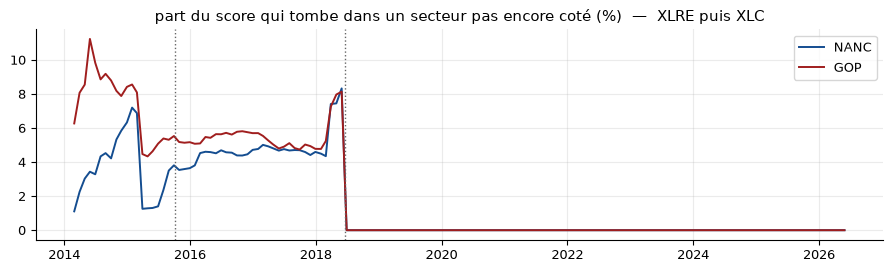

In [47]:
PERDU = {}
for parti, nom in PARTIS:
    ser = {}
    for i1 in coupes[:-1]:
        lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
        g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
        if not len(g): continue
        s = (g.groupby("etf_proxy").A.sum() * g.groupby("etf_proxy").bioguide_id.nunique()).dropna()
        absent = [t for t in s.index if not (np.isfinite(PXV[t][i1+1]) and vivant(t, i1))]
        ser[cal[i1]] = 100 * s.reindex(absent).sum() / s.sum() if s.sum() > 0 else 0.0
    PERDU[nom] = pd.Series(ser)
    p = PERDU[nom][PERDU[nom] > 0]
    print(f"{nom} — {len(p)} coupes sur {len(coupes)-1} avec un secteur manquant · "
          f"part réaffectée : médiane {p.median():.1f} % · max {p.max():.1f} % · dernière {p.index[-1].date()}")

plt.figure(figsize=(9, 2.8))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    plt.plot(PERDU[nom].index, PERDU[nom].values, color=c, lw=1.4, label=nom)
plt.axvline(pd.Timestamp("2015-10-08"), color=GRIS, ls=":", lw=1)
plt.axvline(pd.Timestamp("2018-06-19"), color=GRIS, ls=":", lw=1)
plt.title("part du score qui tombe dans un secteur pas encore coté (%)  —  XLRE puis XLC")
plt.legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/m3_etf_manquant.png", dpi=150, bbox_inches="tight"); plt.show()

### §11.2 — Validations

In [48]:
# (1) l'univers ETF est bien contenu dans les 11 SPDR, et il se remplit aux dates d'inception
for nom in ["NANC", "GOP"]:
    for m in [f"ETF · score (cap {100*CAP:.0f} %)", "ETF · score (sans plafond)", "ETF · équipondéré"]:
        u = set().union(*[set(w) for w in WPE[(m, nom)].values() if w])
        assert u <= set(ETF_SECT), f"{m}/{nom} : instrument hors des 11 SPDR — {u - set(ETF_SECT)}"
card = {cal[i].date(): len(WPE[("ETF · score (sans plafond)", "NANC")][i]) for i in coupes[:-1]}
seq = sorted(set(card.values()))
print(f"✅ (1) l'univers ETF ⊆ les 11 SPDR · cardinaux observés : {seq}")
for n in seq:
    d = [k for k, v in card.items() if v == n]
    print(f"     {n} secteurs : {d[0]} → {d[-1]}  ({len(d)} coupes)")

# (2) Σw = 1 partout
for (m, nom), WP in WPE.items():
    for i, w in WP.items():
        if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{nom} coupe {i} : Σw = {sum(w.values())}"
print(f"✅ (2) Σw = 1 à chaque coupe des {len(WPE)} jeux")

✅ (1) l'univers ETF ⊆ les 11 SPDR · cardinaux observés : [9, 10, 11]
     9 secteurs : 2014-02-28 → 2015-09-30  (20 coupes)
     10 secteurs : 2015-10-30 → 2018-05-31  (32 coupes)
     11 secteurs : 2018-06-29 → 2026-05-29  (96 coupes)
✅ (2) Σw = 1 à chaque coupe des 10 jeux


In [49]:
# (3) le plafond 1/11 rend bien l'équipondéré exact — c'est la démonstration du §10, sur les vrais poids
for nom in ["NANC", "GOP"]:
    ecart = max(np.abs(np.array(list(w.values())) - 1/len(w)).max()
                for w in WPE[("ETF · équipondéré", nom)].values() if w)
    assert ecart < 1e-12, f"{nom} : le run 'équipondéré' ne l'est pas (écart {ecart:.1e})"
print(f"✅ (3) le plafond 1/11 donne l'équipondéré exact sur toutes les coupes (écart max < 1e-12)")

# (4) contrôle de sanité : la variante ETF n'est PAS la variante titres
for nom in ["NANC", "GOP"]:
    a, b = SERE[("ETF · score (sans plafond)", nom)].iloc[-1], SERE[("titres · score (sans plafond)", nom)].iloc[-1]
    assert abs(a - b) > 1, f"{nom} : ETF et titres rendent la même NAV — la substitution n'a pas eu lieu"
    print(f"✅ (4) {nom} — NAV titres {b:.1f} ≠ NAV ETF {a:.1f} : la substitution a bien eu lieu")

# (5) l'équipondéré sectoriel ne DÉPEND PAS du parti : 11 secteurs à poids égaux, c'est le même portefeuille.
#     Les deux colonnes doivent donc coïncider dès que les deux partis couvrent les 11 secteurs.
comm = [i for i in coupes[:-1] if len(WPE[("ETF · équipondéré","NANC")][i]) == 11
                               and len(WPE[("ETF · équipondéré","GOP")][i])  == 11]
for i in comm:
    a, b = WPE[("ETF · équipondéré","NANC")][i], WPE[("ETF · équipondéré","GOP")][i]
    assert set(a) == set(b) and max(abs(a[k]-b[k]) for k in a) < 1e-15, f"coupe {i} : les deux diffèrent"
print(f"✅ (5) l'équipondéré sectoriel est IDENTIQUE pour les deux partis sur les {len(comm)} coupes à 11 secteurs")
ec = abs(SERE[("ETF · équipondéré","NANC")].iloc[-1] - SERE[("ETF · équipondéré","GOP")].iloc[-1])
print(f"     et il l'est aussi sur TOUTES les coupes : écart de NAV finale = {ec:.2e}")
print(f"     ⇒ ce n'est pas deux runs mais UN SEUL. Il ne doit être compté qu'une fois — à poids égaux")
print(f"       sur les mêmes lignes, le parti ne joue plus aucun rôle, y compris au début.")

# (6) NON-RÉGRESSION : M3-titres publiée n'a pas bougé d'un iota
for nom in ["NANC", "GOP"]:
    assert abs(SER[("M3 · $ × élus", nom)].iloc[-1] - M3[nom].iloc[-1]) < 1e-9, f"{nom} : M3 a bougé"
print(f"\n✅ (6) non-régression — M3 sur les titres inchangée "
      f"(NAV {M3['NANC'].iloc[-1]:.2f} / {M3['GOP'].iloc[-1]:.2f}) : le §11 n'a touché à rien")

✅ (3) le plafond 1/11 donne l'équipondéré exact sur toutes les coupes (écart max < 1e-12)
✅ (4) NANC — NAV titres 844.7 ≠ NAV ETF 599.8 : la substitution a bien eu lieu
✅ (4) GOP — NAV titres 587.7 ≠ NAV ETF 501.0 : la substitution a bien eu lieu
✅ (5) l'équipondéré sectoriel est IDENTIQUE pour les deux partis sur les 96 coupes à 11 secteurs
     et il l'est aussi sur TOUTES les coupes : écart de NAV finale = 6.82e-13
     ⇒ ce n'est pas deux runs mais UN SEUL. Il ne doit être compté qu'une fois — à poids égaux
       sur les mêmes lignes, le parti ne joue plus aucun rôle, y compris au début.

✅ (6) non-régression — M3 sur les titres inchangée (NAV 661.57 / 573.57) : le §11 n'a touché à rien


### §11.3 — Les trois réserves sur le run sans plafond

1. **Il n'a pas été déclaré comme méthode.** Il sert de borne haute. Le retenir *parce qu'il gagne* serait
   exactement le geste que tout le protocole de ce notebook cherche à empêcher.
2. **Son excès tient à peu de chose.** Mesuré à **+5,95 %/an ($t$ 2,35)** côté NANC, il dépasse le seuil de Student, mais c'est le seul run du notebook dans ce cas parmi des dizaines lancés — et la mesure de puissance du §12.7 montre qu'à treize années, la marge est mince.
3. **Il achète ce que le plafond existe pour éviter.** Mesuré sur les 148 coupes, sa plus grosse ligne pèse
   **35,7 % en médiane et jusqu'à 87 %** — quatre mois d'affilée sur une seule société en 2015. Le plafond
   n'a jamais été un réglage de performance : c'est une contrainte de diversification. La retirer change la
   nature du produit, pas seulement son rendement.

Ce que ce run établit honnêtement : **le plafond coûte du rendement sur cet échantillon**. C'est une
information sur le prix de la diversification, pas une méthode à livrer.

## §12 — Les secteurs, repris à la racine : où l'agrégation doit-elle avoir lieu ?

**La question posée.** *Garder les 150 meilleurs titres a-t-il encore un sens si l'on agrège ensuite vers
onze secteurs ?* Sur onze lignes, `head(150)` ne coupe rien : la sélection disparaît. La question est juste.

**Ce que le §11 fait, dans l'ordre exact du code.** La substitution titre $\to$ ETF a lieu **sur les lignes de
transaction**, avant le moindre regroupement :

$$\text{filtre parti/achat} \;\to\; \underbrace{\text{SUBSTITUTION}}_{\text{③}} \;\to\;
  \underbrace{\text{agrégation}}_{\text{④}} \;\to\; \text{score} \;\to\;
  \underbrace{\text{sélection}}_{\text{⑧}} \;\to\; \underbrace{\text{plafond}}_{\text{⑩}}$$

Comme ③ précède ④, **tout** ce qui suit opère sur un objet dont l'index est déjà l'ETF : les dollars sont
sommés par secteur, le consensus $m$ compte les élus **par secteur**, et ce que le top-150 aurait écarté
entre intégralement dans le score. *(Combien exactement ? Le §12.3 le mesure au lieu de l'estimer.)*

### Les trois choses que le §11 change à la fois
| | dans M3 | dans la variante ETF du §11 |
|---|---|---|
| l'**instrument** acheté | le titre | l'ETF de son secteur |
| la **sélection** | 150 sur ~855 | inopérante (11 < 150) |
| le niveau où $m$ est mesuré | par titre | par secteur |

Un test qui change trois choses n'isole aucune des trois. Ce paragraphe les sépare.

### Les trois façons d'agréger, nommées avant de les mesurer
- **A** — substituer avant le `groupby` : c'est le §11, tel qu'il est publié ;
- **B** — scorer par **titre**, garder le top-150, puis sommer leurs **scores** par secteur ;
- **C** — calculer **M3 en entier** (score, top-150, plafond), puis remplacer chaque ligne par son ETF et
  sommer les **poids** :
$$w^{\text{sect}}_S(t) \;=\; \sum_{i \,:\, \varphi(i)=S} w^{\text{M3}}_i(t), \qquad
  \text{renormalisé sur les secteurs cotés en } t.$$

**C est déclarée primaire, avant tout calcul**, parce qu'elle est la seule à ne changer **qu'une chose :
l'instrument**. Elle livre l'exposition sectorielle *réelle* de M3, tenue en ETF. B répond à la question
littéralement posée et sera publiée avec sa réserve : sommer des produits $B_i m_i$ n'a pas d'interprétation
propre — cela donne un poids superlinéaire aux secteurs qui comptent beaucoup de titres élus.

### §12.1 — Ce que le run « ETF · score » mesure vraiment

Onze secteurs, plafond à 10 % : $11 \times 10\,\% = 110\,\%$. Il ne reste que **dix points de mou** pour
toute la distribution. Mécaniquement, presque toutes les lignes doivent siéger *exactement* au plafond — et
un vecteur dont presque toutes les composantes valent $c$ est, à peu de chose près, l'équipondéré.

Le §10.1 conclut « le score survit » à partir d'un exemple **fabriqué** où une ligne pèse 62,9 %. C'est vrai
de cet exemple. On mesure ici ce qu'il en est sur les **vrais** scores, coupe par coupe.

In [51]:
LAB_CAP = f"ETF · score (cap {100*CAP:.0f} %)"
LAB_EQ  = "ETF · équipondéré"

L = []
for nom in ["NANC", "GOP"]:
    WPc, WPe = WPE[(LAB_CAP, nom)], WPE[(LAB_EQ, nom)]
    nplaf, neff, nlig, dist = [], [], [], []
    for i in coupes[:-1]:
        w = pd.Series(WPc[i]); e = pd.Series(WPe[i])
        if not len(w): continue
        nplaf.append(int((w.values > CAP - 1e-9).sum()))
        neff.append(1.0 / float((w.values**2).sum()))
        nlig.append(len(w))
        k = w.index.union(e.index)
        dist.append(0.5 * float((w.reindex(k).fillna(0) - e.reindex(k).fillna(0)).abs().sum()))
    L.append({"fonds": nom, "lignes (méd.)": int(np.median(nlig)),
              "lignes AU PLAFOND (méd.)": int(np.median(nplaf)),
              "min": int(np.min(nplaf)), "max": int(np.max(nplaf)),
              "N_eff (méd.)": float(np.median(neff)),
              "distance au 1/11 (méd. %)": 100*float(np.median(dist)),
              "distance max %": 100*float(np.max(dist))})
display(pd.DataFrame(L).set_index("fonds").round(2))
print(f"repère : sur 11 lignes, l'équipondéré exact a N_eff = 11,00 et une distance de 0 %")
print(f"la « distance » est ½·Σ|w_score − w_équi| : la fraction du portefeuille qu'il faudrait échanger")
print(f"pour passer du run « score » au run « équipondéré ».")

,lignes (méd.),lignes AU PLAFOND (méd.),min,max,N_eff (méd.),distance au 1/11 (méd. %),distance max %
fonds,,,,,,,
NANC,11,9,7,10,10.52,7.27,8.18
GOP,11,9,8,10,10.50,7.70,8.18


repère : sur 11 lignes, l'équipondéré exact a N_eff = 11,00 et une distance de 0 %
la « distance » est ½·Σ|w_score − w_équi| : la fraction du portefeuille qu'il faudrait échanger
pour passer du run « score » au run « équipondéré ».


In [52]:
# et ce que ça donne sur le résultat : les deux runs sont-ils distinguables ?
print("=== le run « score » et le run « équipondéré » sont-ils deux méthodes différentes ? ===\n")
for nom in ["NANC", "GOP"]:
    a, b = SERE[(LAB_CAP, nom)], SERE[(LAB_EQ, nom)]
    ra, rb = a.pct_change().dropna(), b.pct_change().dropna()
    j = ra.index.intersection(rb.index)
    ba, bb = bilan(a, f"{LAB_CAP} — {nom}"), bilan(b, f"{LAB_EQ} — {nom}")
    print(f"{nom} : NAV {a.iloc[-1]:.1f} (score) contre {b.iloc[-1]:.1f} (équipondéré) — "
          f"écart {100*abs(a.iloc[-1]/b.iloc[-1]-1):.2f} % sur {a.index[-1].year - a.index[0].year + 1} années")
    print(f"       excès {ba['excès %/an']:+.2f} contre {bb['excès %/an']:+.2f} %/an · "
          f"β {ba['β']:.3f} contre {bb['β']:.3f}")
    print(f"       corrélation des rendements journaliers : {ra[j].corr(rb[j]):.5f}   "
          f"écart-type de la différence : {100*(ra[j]-rb[j]).std()*np.sqrt(252):.2f} %/an\n")
print("⚠️ LECTURE — le run publié « ETF · score » N'EST PAS une pondération par le score :")
print("   c'est l'équipondéré sectoriel, à un cheveu près. Le plafond a effacé le score aussi")
print("   sûrement que le head(150) avait effacé la sélection. La conclusion du §11 (« l'information")
print("   est dans le titre, pas dans son secteur ») n'est donc pas ÉTABLIE par ce run : il ne teste")
print("   pas ce qu'il prétend tester. Le §12.4 le refait avec un test qui, lui, isole l'instrument.")

=== le run « score » et le run « équipondéré » sont-ils deux méthodes différentes ? ===

NANC : NAV 387.4 (score) contre 389.7 (équipondéré) — écart 0.58 % sur 13 années
       excès -2.37 contre -2.40 %/an · β 0.924 contre 0.909
       corrélation des rendements journaliers : 0.99860   écart-type de la différence : 0.88 %/an

GOP : NAV 400.6 (score) contre 389.7 (équipondéré) — écart 2.82 % sur 13 années
       excès -2.14 contre -2.40 %/an · β 0.924 contre 0.909
       corrélation des rendements journaliers : 0.99842   écart-type de la différence : 0.93 %/an

⚠️ LECTURE — le run publié « ETF · score » N'EST PAS une pondération par le score :
   c'est l'équipondéré sectoriel, à un cheveu près. Le plafond a effacé le score aussi
   sûrement que le head(150) avait effacé la sélection. La conclusion du §11 (« l'information
   est dans le titre, pas dans son secteur ») n'est donc pas ÉTABLIE par ce run : il ne teste
   pas ce qu'il prétend tester. Le §12.4 le refait avec un test qui, lui,

### §12.2 — Pourquoi le score meurt : le consensus sature à l'agrégation

$s_i = B_i \times m_i$. Au niveau du **titre**, $m$ discrimine : une société a 1 acheteur, une autre en a 16.
Au niveau du **secteur**, presque tous les élus finissent par acheter un titre de technologie, un de santé,
un de finance : $m$ devient quasi constant d'un secteur à l'autre.

Si $m$ ne varie plus, $s_i \propto B_i$ : **au niveau sectoriel, M3 dégénère en M2 (les dollars purs)**. On
le mesure en comparant les amplitudes, puis en comptant les inversions entre les deux classements.

In [53]:
CONS, INV = [], []
for parti, nom in PARTIS:
    rap_sect, rap_tit, tau_sect, tau_tit = [], [], [], []
    rap_dol, part_k = [], []
    for i1 in coupes[:-1]:
        lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
        g = df.iloc[ordre_d[lo:hi]]
        g = g[(g.party == parti) & (g.op == "buy")]
        if not len(g): continue
        # niveau SECTEUR
        bs = g.groupby("etf_proxy").A.sum(); ms = g.groupby("etf_proxy").bioguide_id.nunique().reindex(bs.index)
        if len(bs) >= 3:
            rap_sect.append(ms.max()/ms.min())
            rap_dol.append(bs.max()/bs.min())
            sc_s = (bs*ms).dropna()
            part_k.append(100*sc_s.get("XLK", 0.0)/sc_s.sum())
            tau_sect.append(stats.kendalltau(bs.values, (bs*ms).values).statistic)
        # niveau TITRE, restreint au top-150 (l'univers que M3 détient réellement)
        gt = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
        bt = gt.groupby("tkm").A.sum(); mt = gt.groupby("tkm").bioguide_id.nunique().reindex(bt.index)
        sc = (bt*mt).dropna().sort_values(ascending=False).head(TOPN)
        if len(sc) >= 3:
            rap_tit.append(mt[sc.index].max()/mt[sc.index].min())
            tau_tit.append(stats.kendalltau(bt[sc.index].values, sc.values).statistic)
    CONS.append({"fonds": nom, "m max/min — SECTEUR (méd.)": float(np.median(rap_sect)),
                 "m max/min — TITRE (méd.)": float(np.median(rap_tit)),
                 "$ max/min — SECTEUR (méd.)": float(np.median(rap_dol)),
                 "part de XLK dans le score — méd. %": float(np.median(part_k))})
    INV.append({"fonds": nom, "τ de Kendall $ vs score — SECTEUR": float(np.median(tau_sect)),
                "τ de Kendall $ vs score — TITRE": float(np.median(tau_tit))})
display(pd.DataFrame(CONS).set_index("fonds").round(2))
display(pd.DataFrame(INV).set_index("fonds").round(3))
print("τ de Kendall = 1 : les deux classements sont identiques. Plus il est proche de 1, plus le score")
print("se réduit aux dollars — donc plus M3 et M2 sont la même méthode.")

,m max/min — SECTEUR (méd.),m max/min — TITRE (méd.),$ max/min — SECTEUR (méd.),part de XLK dans le score — méd. %
fonds,,,,
NANC,2.37,17.0,28.17,33.76
GOP,2.65,22.0,14.92,13.85


,τ de Kendall $ vs score — SECTEUR,τ de Kendall $ vs score — TITRE
fonds,,
NANC,0.927,0.681
GOP,0.891,0.520


τ de Kendall = 1 : les deux classements sont identiques. Plus il est proche de 1, plus le score
se réduit aux dollars — donc plus M3 et M2 sont la même méthode.


In [54]:
# le détail à la dernière coupe : les onze secteurs, et le peu que le consensus y change
i1 = coupes[-2]
for parti, nom in PARTIS:
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
    b = g.groupby("etf_proxy").A.sum(); m = g.groupby("etf_proxy").bioguide_id.nunique().reindex(b.index)
    T = pd.DataFrame({"$ acheté (M$)": b/1e6, "élus m": m, "titres": g.groupby("etf_proxy").tk.nunique(),
                      "score %": 100*(b*m)/(b*m).sum(), "$ seuls %": 100*b/b.sum()}).sort_values("score %", ascending=False)
    print(f"\n{nom} — coupe du {cal[i1].date()} · {g.bioguide_id.nunique()} élus acheteurs au total")
    display(T.round(2))
    print(f"   dollars : facteur {b.max()/b.min():.0f} entre le plus gros et le plus petit secteur")
    print(f"   élus    : facteur {m.max()/m.min():.1f}  ← un facteur {m.max()/m.min():.1f} ne module pas un facteur {b.max()/b.min():.0f}")
    o1 = list(T.sort_values("$ seuls %", ascending=False).index); o2 = list(T.index)
    print(f"   classement par $   : {' · '.join(o1)}")
    print(f"   classement par score : {' · '.join(o2)}"
          f"   → {sum(x != y for x, y in zip(o1, o2))} position(s) changée(s)")


NANC — coupe du 2026-05-29 · 39 élus acheteurs au total


,$ acheté (M$),élus m,titres,score %,$ seuls %
etf_proxy,,,,,
XLK,50.55,31,149,45.22,37.24
XLV,15.11,24,116,10.46,11.13
XLY,13.91,24,102,9.63,10.24
XLF,14.06,22,115,8.93,10.36
XLC,12.08,25,43,8.72,8.90
XLI,10.76,22,126,6.83,7.92
XLP,7.82,22,57,4.96,5.76
XLRE,4.27,17,46,2.10,3.15
XLB,3.42,16,36,1.58,2.52


   dollars : facteur 28 entre le plus gros et le plus petit secteur
   élus    : facteur 2.2  ← un facteur 2.2 ne module pas un facteur 28
   classement par $   : XLK · XLV · XLF · XLY · XLC · XLI · XLP · XLRE · XLB · XLE · XLU
   classement par score : XLK · XLV · XLY · XLF · XLC · XLI · XLP · XLRE · XLB · XLE · XLU   → 2 position(s) changée(s)

GOP — coupe du 2026-05-29 · 60 élus acheteurs au total


,$ acheté (M$),élus m,titres,score %,$ seuls %
etf_proxy,,,,,
XLK,29.59,42,141,31.85,27.34
XLV,15.85,36,91,14.63,14.65
XLI,14.16,36,130,13.06,13.08
XLF,12.24,41,131,12.86,11.30
XLY,9.78,34,104,8.52,9.03
XLE,7.58,29,58,5.63,7.00
XLC,6.03,32,30,4.94,5.57
XLP,5.39,31,56,4.28,4.98
XLB,3.90,25,40,2.50,3.60


   dollars : facteur 20 entre le plus gros et le plus petit secteur
   élus    : facteur 2.3  ← un facteur 2.3 ne module pas un facteur 20
   classement par $   : XLK · XLV · XLI · XLF · XLY · XLE · XLC · XLP · XLB · XLRE · XLU
   classement par score : XLK · XLV · XLI · XLF · XLY · XLE · XLC · XLP · XLB · XLRE · XLU   → 0 position(s) changée(s)


### §12.3 — B : sélectionner d'abord, agréger ensuite

La question du chef, prise au pied de la lettre. On garde les 150 meilleurs **titres**, puis on somme leurs
scores par secteur. La queue du classement — les centaines de titres à un seul acheteur — est éliminée
**avant** d'entrer dans le score sectoriel.

⚠️ **Sa réserve d'interprétation, écrite avant le résultat.** $\sum_{i \in S} B_i m_i$ n'est ni le score du
secteur, ni l'exposition du portefeuille : c'est une somme de produits, qui favorise mécaniquement les
secteurs comptant beaucoup de titres élus. B est publiée parce qu'elle répond à la question, pas parce
qu'elle a un sens propre.

In [55]:
# la carte titre → ETF, bâtie sur les tickers POST-fusion (poids_methode rend GOOG, BRK-B, FOX, NWS)
_tkm  = df.tk.map(lambda t: FUSION.get(t, t))
_amb  = df.assign(tkm=_tkm).groupby("tkm").etf_proxy.nunique()
CARTE = df.assign(tkm=_tkm).groupby("tkm").etf_proxy.agg(lambda s: s.mode().iat[0])   # règle : le MODE par ticker
print(f"carte titre → secteur : {len(CARTE)} tickers, {CARTE.nunique()} secteurs, {CARTE.isna().sum()} sans secteur")
print(f"tickers portant PLUSIEURS etf_proxy selon la ligne : {int((_amb > 1).sum())} "
      f"({', '.join(_amb[_amb > 1].index)}) → tranchés par le mode, règle déclarée ici")
for a, b in FUSION.items():                      # les 4 fusions ne doivent pas créer d'ambiguïté
    if a in set(df.tk) and b in set(df.tk):
        ea = set(df.loc[df.tk == a, "etf_proxy"]); eb = set(df.loc[df.tk == b, "etf_proxy"])
        assert ea == eb, f"fusion {a}→{b} : secteurs différents {ea} vs {eb}"
print(f"✅ les {len(FUSION)} classes d'actions fusionnées portent le même secteur des deux côtés")

carte titre → secteur : 2751 tickers, 11 secteurs, 0 sans secteur
tickers portant PLUSIEURS etf_proxy selon la ligne : 5 (BALL, CPAY, SONY, TFC, XYZ) → tranchés par le mode, règle déclarée ici


✅ les 4 classes d'actions fusionnées portent le même secteur des deux côtés


In [56]:
def poids_B(i1, parti, cap=CAP, topN=TOPN, carte=None):
    # M3 jusqu'à la SÉLECTION, puis les scores du top-150 sont sommés par secteur, puis plafonnés
    carte = CARTE if carte is None else carte
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    g       = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    buy     = g.groupby("tkm").A.sum()
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)
    score   = (buy * breadth).dropna()
    # investissabilité jugée sur le TITRE, comme dans M3 — c'est ce qui définit l'univers sélectionné
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)
    if not len(score) or score.sum() <= 0: return {}
    cle = carte.reindex(score.index)
    assert not cle.isna().any(), f"coupe {i1} : titres sans secteur — {list(score.index[cle.isna()])}"
    s = score.groupby(cle.values).sum()                                  # ← l'agrégation, APRÈS la sélection
    s = s[[t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    if not len(s) or s.sum() <= 0: return {}
    return cap_poids(s / s.sum(), cap).to_dict()                        # cap_poids renormalise déjà
print("poids_B défini — sélection au niveau titre, agrégation des scores au niveau secteur")

poids_B défini — sélection au niveau titre, agrégation des scores au niveau secteur


In [57]:
# CE QUE LE TOP-150 ÉCARTE VRAIMENT — mesuré sur les 148 coupes, au lieu d'être estimé de mémoire
ECA = []
for parti, nom in PARTIS:
    pd_, ps_, nu_ = [], [], []
    for i1 in coupes[:-1]:
        lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
        g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
        if not len(g): continue
        g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
        b = g.groupby("tkm").A.sum(); m = g.groupby("tkm").bioguide_id.nunique().reindex(b.index)
        s = (b*m).dropna()
        s = s[[t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
        if not len(s): continue
        top = s.sort_values(ascending=False).head(TOPN).index
        nu_.append(len(s))
        pd_.append(100*(1 - b[top].sum()/b[s.index].sum()))
        ps_.append(100*(1 - s[top].sum()/s.sum()))
    ECA.append({"fonds": nom, "univers médian": int(np.median(nu_)),
                "$ écarté par le top-150 — médiane %": float(np.median(pd_)),
                "moyenne %": float(np.mean(pd_)),
                "SCORE écarté — médiane %": float(np.median(ps_))})
display(pd.DataFrame(ECA).set_index("fonds").round(1))
print("→ le top-150 écarte un CINQUIÈME à un QUART du dollar, mais seulement 6 à 8 % du score :")
print("  la queue du classement est faite de beaucoup de dollars portés par très peu d'élus.")

,univers médian,$ écarté par le top-150 — médiane %,moyenne %,SCORE écarté — médiane %
fonds,,,,
NANC,857,20.9,21.1,6.0
GOP,861,26.0,26.5,8.1


→ le top-150 écarte un CINQUIÈME à un QUART du dollar, mais seulement 6 à 8 % du score :
  la queue du classement est faite de beaucoup de dollars portés par très peu d'élus.


### §12.4 — C : l'exposition sectorielle de M3, tenue en ETF *(la variante de référence)*

C ne touche à rien de M3 : ni au score, ni au top-150, ni au plafond de 10 % **par titre**. Elle prend le
portefeuille tel que M3 le construit et remplace chaque ligne par l'ETF de son secteur. **Le seul changement
est l'instrument.**

Trois points de mécanique, tranchés d'avance :
- **la renormalisation est obligatoire** — avant juin 2018, une partie du poids tombe dans un secteur qui ne
  cote pas ; le moteur exige $\sum w = 1$ et refuserait la coupe autrement ;
- **le plafond de 10 % ne survit pas à l'agrégation** : il s'applique aux titres, et plusieurs titres du même
  secteur s'additionnent. C livre donc l'exposition *réelle* de M3, très inclinée. On publie aussi une
  variante **replafonnée à 10 % au niveau secteur** — c'est une spécification *nouvelle*, déclarée ici ;
- **la fenêtre primaire est 2019-2026**, parce que le repli sur les secteurs manquants frappe C plus fort
  que A (le top-150 concentre justement sur la technologie et l'immobilier) — c'est mesuré ci-dessous.

⚠️ **Un quatrième fait, hérité du §4.1.** Un plafond à 10 % n'a de solution que si l'univers compte au moins
$\lceil 1/c\rceil = 10$ lignes. Avant octobre 2015, **neuf secteurs seulement cotent** : sur ces coupes-là,
la version replafonnée — comme la version B plafonnée — est l'équipondéré **de fait**, exactement comme
l'était la première coupe de M3. La validation (4) le compte et le nomme au lieu de le laisser passer.

In [58]:
def poids_C(i1, parti, carte=None, cap_sect=None, **kw):
    # M3 EN ENTIER (kw : topN, cap, seuil, mode — les défauts sont ceux de M3), puis agrégation des POIDS
    carte = CARTE if carte is None else carte
    w = poids_methode(i1, parti, **kw)
    if not w: return {}
    s = pd.Series(w)
    cle = carte.reindex(s.index)
    assert not cle.isna().any(), f"coupe {i1} : titres sans secteur — {list(s.index[cle.isna()])}"
    s = s.groupby(cle.values).sum()
    vivants = [t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]
    if not len(vivants) or s[vivants].sum() <= 0: return {}
    s = s[vivants] / s[vivants].sum()                       # ← RENORMALISATION sur les secteurs cotés
    if cap_sect is not None: s = cap_poids(s, cap_sect)
    return s.to_dict()

# ce que le repli coûte à C : la part du poids M3 qui tombe dans un secteur non coté
PERDU_C = {}
for parti, nom in PARTIS:
    ser = {}
    for i1 in coupes[:-1]:
        w = poids_methode(i1, parti)
        if not w: continue
        s = pd.Series(w).groupby(CARTE.reindex(pd.Series(w).index).values).sum()
        absent = [t for t in s.index if not (np.isfinite(PXV[t][i1+1]) and vivant(t, i1))]
        ser[cal[i1]] = 100 * s.reindex(absent).sum() / s.sum()
    PERDU_C[nom] = pd.Series(ser)
    p = PERDU_C[nom][PERDU_C[nom] > 0]
    print(f"{nom} — C : {len(p)} coupes avec un secteur manquant · médiane {p.median():.1f} % · max {p.max():.1f} %"
          f"   |   A (§11.1) : médiane {PERDU[nom][PERDU[nom]>0].median():.1f} % · max {PERDU[nom][PERDU[nom]>0].max():.1f} %")
print("\n→ C est plus exposée que A au repli, parce que le top-150 concentre sur les secteurs récents.")
print("  D'où la fenêtre primaire 2019-2026, déclarée avant le résultat.")

NANC — C : 52 coupes avec un secteur manquant · médiane 15.4 % · max 20.8 %   |   A (§11.2) : médiane 4.5 % · max 8.3 %


GOP — C : 52 coupes avec un secteur manquant · médiane 11.9 % · max 16.1 %   |   A (§11.2) : médiane 5.5 % · max 11.2 %

→ C est plus exposée que A au repli, parce que le top-150 concentre sur les secteurs récents.
  D'où la fenêtre primaire 2019-2026, déclarée avant le résultat.


In [59]:
# les runs de B et C — déclarés ici, tous publiés
LAB_B  = f"B · scores du top-150 agrégés (cap {100*CAP:.0f} %)"
LAB_B0 = "B · scores du top-150 agrégés (sans plafond)"
LAB_C  = "C · M3 agrégée en ETF (brute)"
LAB_C1 = f"C · M3 agrégée en ETF (replafonnée {100*CAP:.0f} %)"

t0 = time.time()
for parti, nom in PARTIS:
    WPE[(LAB_B,  nom)] = {i: poids_B(i, parti, cap=CAP) for i in coupes[:-1]}
    WPE[(LAB_B0, nom)] = {i: poids_B(i, parti, cap=1.0) for i in coupes[:-1]}
    WPE[(LAB_C,  nom)] = {i: poids_C(i, parti) for i in coupes[:-1]}
    WPE[(LAB_C1, nom)] = {i: poids_C(i, parti, cap_sect=CAP) for i in coupes[:-1]}
    for m in [LAB_B, LAB_B0, LAB_C, LAB_C1]:
        SERE[(m, nom)] = run_livre(WPE[(m, nom)], np.inf)[0]
print(f"8 jeux de cibles calculés en {time.time()-t0:.1f} s")

# l'exposition sectorielle des trois lectures, à la dernière coupe — c'est la table qui montre l'écart
i1 = coupes[-2]
for nom in ["NANC", "GOP"]:
    T = pd.DataFrame({"A (§11)": pd.Series(WPE[(LAB_CAP, nom)][i1]), "B": pd.Series(WPE[(LAB_B, nom)][i1]),
                      "C brute": pd.Series(WPE[(LAB_C, nom)][i1]),
                      "C replafonnée": pd.Series(WPE[(LAB_C1, nom)][i1])}) * 100
    print(f"\n{nom} — poids par secteur à la coupe du {cal[i1].date()} (%)")
    display(T.sort_values("C brute", ascending=False).round(1))

8 jeux de cibles calculés en 8.7 s

NANC — poids par secteur à la coupe du 2026-05-29 (%)


,A (§11),B,C brute,C replafonnée
XLK,10.0,10.0,46.6,10.0
XLC,10.0,10.0,16.3,10.0
XLY,10.0,10.0,11.6,10.0
XLV,10.0,10.0,8.9,10.0
XLF,10.0,10.0,7.1,10.0
XLP,10.0,10.0,4.2,10.0
XLI,10.0,10.0,2.8,10.0
XLB,10.0,10.0,0.9,10.0
XLE,5.1,8.3,0.7,8.3
XLRE,10.0,8.3,0.7,8.3



GOP — poids par secteur à la coupe du 2026-05-29 (%)


,A (§11),B,C brute,C replafonnée
XLK,10.0,10.0,42.2,10.0
XLV,10.0,10.0,16.8,10.0
XLC,10.0,10.0,10.6,10.0
XLF,10.0,10.0,9.0,10.0
XLY,10.0,10.0,6.9,10.0
XLE,10.0,10.0,5.7,10.0
XLI,10.0,10.0,4.1,10.0
XLP,10.0,10.0,2.8,10.0
XLB,10.0,10.0,1.4,10.0
XLU,3.9,6.7,0.3,6.7


#### §12.4.1 — Ce que les trois lectures donnent

Le tableau oppose les trois façons d'agréger **à plafond égal**. Les lignes « sans plafond » sont celles qui
comptent : ce sont les seules où les trois mécaniques peuvent encore différer.

In [60]:
LAB_A0 = "ETF · score (sans plafond)"                    # le run A du §11, sans plafond
ORD_12 = [LAB_M3, LAB_CAP, LAB_B, LAB_C1, LAB_EQ, LAB_A0, LAB_B0, LAB_C]
for d0, lab in [(D19, "2019-2026 — LA FENÊTRE PRIMAIRE (les 11 secteurs cotent tous)"),
                (None, "2014-2026 — tout l'historique, avec le repli sur les secteurs manquants")]:
    L = []
    for nom in ["NANC", "GOP"]:
        for m in ORD_12:
            b = bilan_ic(SERE[(m, nom)] if d0 is None else SERE[(m, nom)][SERE[(m, nom)].index >= d0],
                         f"{m} — {nom}" + ("" if d0 is None else " (2019+)"))
            L.append({"run": b["run"], "excès %/an": b["excès %/an"], "t": b["t"], "n ans": b["n ans"],
                      "IC bas": b["IC bas"], "IC haut": b["IC haut"],
                      "α₁ %/an": b["α %/an"], "t_α₁": b["t_α"], "β": b["β"], "NAV": b["NAV"]})
    print(f"\n=== {lab} ===")
    display(pd.DataFrame(L).set_index("run").round(2))


=== 2019-2026 — LA FENÊTRE PRIMAIRE (les 11 secteurs cotent tous) ===


,excès %/an,t,n ans,IC bas,IC haut,α₁ %/an,t_α₁,β,NAV
run,,,,,,,,,
titres · M3 (cap 10 %) — NANC (2019+),4.16,1.20,8,-4.02,12.34,1.62,0.88,1.09,661.57
ETF · score (cap 10 %) — NANC (2019+),-2.92,-1.74,8,-6.88,1.05,-1.27,-0.74,0.92,387.38
B · scores du top-150 agrégés (cap 10 %) — NANC (2019+),-2.89,-1.70,8,-6.92,1.13,-1.19,-0.69,0.92,388.44
C · M3 agrégée en ETF (replafonnée 10 %) — NANC (2019+),-2.89,-1.70,8,-6.92,1.13,-1.19,-0.69,0.92,388.44
ETF · équipondéré — NANC (2019+),-2.98,-1.47,8,-7.78,1.82,-0.88,-0.46,0.91,389.65
ETF · score (sans plafond) — NANC (2019+),2.24,1.46,8,-1.40,5.89,0.56,0.68,1.05,599.85
B · scores du top-150 agrégés (sans plafond) — NANC (2019+),4.79,1.85,8,-1.32,10.89,1.64,1.10,1.11,696.96
C · M3 agrégée en ETF (brute) — NANC (2019+),1.92,1.09,8,-2.24,6.07,0.20,0.21,1.05,565.34
titres · M3 (cap 10 %) — GOP (2019+),2.28,2.71,8,0.29,4.26,2.21,1.54,0.99,573.57



=== 2014-2026 — tout l'historique, avec le repli sur les secteurs manquants ===


,excès %/an,t,n ans,IC bas,IC haut,α₁ %/an,t_α₁,β,NAV
run,,,,,,,,,
titres · M3 (cap 10 %) — NANC,3.40,1.61,13,-1.19,7.99,1.66,1.36,1.08,661.57
ETF · score (cap 10 %) — NANC,-2.37,-2.22,13,-4.69,-0.05,-1.13,-1.01,0.92,387.38
B · scores du top-150 agrégés (cap 10 %) — NANC,-2.35,-2.18,13,-4.69,-0.00,-1.07,-0.95,0.92,388.44
C · M3 agrégée en ETF (replafonnée 10 %) — NANC,-2.35,-2.18,13,-4.69,-0.00,-1.07,-0.95,0.92,388.44
ETF · équipondéré — NANC,-2.40,-1.89,13,-5.16,0.36,-0.85,-0.70,0.91,389.65
ETF · score (sans plafond) — NANC,1.93,1.87,13,-0.32,4.18,0.67,0.71,1.06,599.85
B · scores du top-150 agrégés (sans plafond) — NANC,3.62,2.13,13,-0.08,7.33,1.35,1.09,1.11,696.96
C · M3 agrégée en ETF (brute) — NANC,1.50,1.38,13,-0.87,3.88,0.30,0.47,1.05,565.34
titres · M3 (cap 10 %) — GOP,1.24,1.61,13,-0.44,2.91,1.09,1.07,1.00,573.57


In [61]:
# concentration, volatilité, rotation : ce que chaque lecture achète réellement
L = []
for nom in ["NANC", "GOP"]:
    for m in ORD_12:
        V = SERE[(m, nom)]
        w = 100 * pd.Series(WPE[(m, nom)][coupes[-2]]).sort_values(ascending=False)
        mx, t5, ne = conc(w)
        _, an = rotation(WPE[(m, nom)])
        L.append({"run": f"{m} — {nom}", "lignes": len(w), "plus gros %": mx, "top-5 %": t5, "N_eff": ne,
                  "vol %/an": 100*V.pct_change().std()*np.sqrt(252),
                  "rotation moy. %/an": an.mean(), "NAV": V.iloc[-1]})
display(pd.DataFrame(L).set_index("run").round(1))
print(f"repère : SPY vol {100*r_spy.std()*np.sqrt(252):.1f} %/an")

,lignes,plus gros %,top-5 %,N_eff,vol %/an,rotation moy. %/an,NAV
run,,,,,,,
titres · M3 (cap 10 %) — NANC,150,10.0,42.2,21.6,19.1,71.8,661.6
ETF · score (cap 10 %) — NANC,11,10.0,50.0,10.5,16.4,16.3,387.4
B · scores du top-150 agrégés (cap 10 %) — NANC,11,10.0,50.0,10.5,16.3,20.3,388.4
C · M3 agrégée en ETF (replafonnée 10 %) — NANC,11,10.0,50.0,10.5,16.3,20.3,388.4
ETF · équipondéré — NANC,11,9.1,45.5,11.0,16.2,15.4,389.7
ETF · score (sans plafond) — NANC,11,45.2,83.0,4.0,18.6,34.3,599.8
B · scores du top-150 agrégés (sans plafond) — NANC,11,59.9,92.8,2.6,19.7,41.3,697.0
C · M3 agrégée en ETF (brute) — NANC,11,46.6,90.5,3.7,18.2,30.4,565.3
titres · M3 (cap 10 %) — GOP,150,9.0,32.6,32.7,17.7,76.9,573.6


repère : SPY vol 16.6 %/an


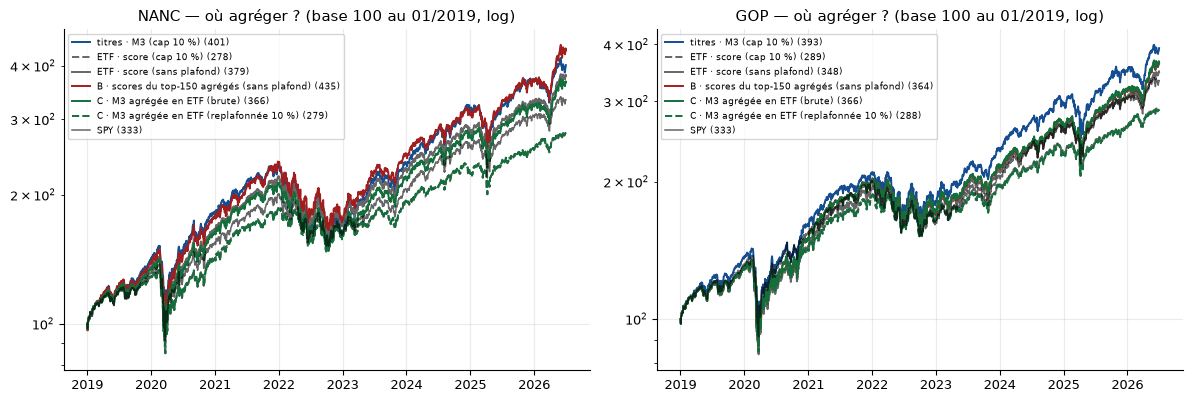

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.1))
for k, nom in enumerate(["NANC", "GOP"]):
    base = SERE[(LAB_M3, nom)]; base = base[base.index >= D19]
    sp   = (1 + r_spy.reindex(base.index).fillna(0)).cumprod() * 100
    for m, c, ls in [(LAB_M3, BLEU, "-"), (LAB_CAP, GRIS, "--"), (LAB_A0, GRIS, "-"),
                     (LAB_B0, ROUGE, "-"), (LAB_C, VERT, "-"), (LAB_C1, VERT, "--")]:
        V = SERE[(m, nom)]; V = V[V.index >= D19]; V = V / V.iloc[0] * 100
        ax[k].plot(V.index, V, color=c, ls=ls, lw=1.4, label=f"{m} ({V.iloc[-1]:.0f})")
    ax[k].plot(sp.index, sp/sp.iloc[0]*100, color="k", lw=1.1, alpha=.6, label=f"SPY ({sp.iloc[-1]/sp.iloc[0]*100:.0f})")
    ax[k].set_yscale("log"); ax[k].set_title(f"{nom} — où agréger ? (base 100 au 01/2019, log)")
    ax[k].legend(fontsize=6.5)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_etf_ou_agreger.png", dpi=150, bbox_inches="tight"); plt.show()

#### §12.4.2 — Validations

In [63]:
# (1) NON-RÉGRESSION de l'enrobage : avec une carte identité, le groupby + le filtre + la renormalisation
#     doivent être des no-op. ⚠️ PORTÉE LIMITÉE, dite explicitement : sous CARTE_ID aucun groupe ne fusionne
#     deux titres, aucun titre n'est écarté et le diviseur vaut 1 — ce contrôle ne teste donc NI l'agrégation
#     NI le repli. Il dit seulement que poids_C n'abîme pas M3. Les contrôles (7) et (8) testent le reste.
CARTE_ID = pd.Series(CARTE.index.values, index=CARTE.index)
ecart_max = 0.0
for parti, nom in PARTIS:
    for i1 in [i for i in coupes[:-1]][::5]:           # 1 coupe sur 5, pas 1 sur 17
        a, b = poids_methode(i1, parti), poids_C(i1, parti, carte=CARTE_ID)
        assert set(a) == set(b), f"{nom} coupe {i1} : univers différent"
        ecart_max = max(ecart_max, max(abs(a[k]-b[k]) for k in a))
assert ecart_max < 1e-15, f"C avec carte identité ≠ M3 (écart {ecart_max:.1e})"
print(f"✅ (1) C avec une carte identité ≡ M3-titres, écart max {ecart_max:.1e} (le bruit d'une division")
print(f"       par 1, donc pas exactement 0). ⚠️ ce contrôle ne teste ni l'agrégation ni le repli — voir (7) et (8)")

# (2) Σw = 1 partout, APRÈS renormalisation, sur les 8 nouveaux jeux
n_ok = 0
for m in [LAB_B, LAB_B0, LAB_C, LAB_C1]:
    for nom in ["NANC", "GOP"]:
        for i, w in WPE[(m, nom)].items():
            if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{nom} coupe {i} : Σw = {sum(w.values())}"; n_ok += 1
print(f"✅ (2) Σw = 1 sur les {n_ok} coupes des 4 nouveaux jeux (renormalisation comprise)")

# (3) l'univers de B et C est bien contenu dans les 11 SPDR, et aucune coupe n'est vide
for m in [LAB_B, LAB_B0, LAB_C, LAB_C1]:
    for nom in ["NANC", "GOP"]:
        u = set().union(*[set(w) for w in WPE[(m, nom)].values() if w])
        assert u <= set(ETF_SECT), f"{m}/{nom} : instrument hors des 11 SPDR — {u - set(ETF_SECT)}"
        vides = [i for i in coupes[:-1] if not WPE[(m, nom)][i]]
        assert not vides, f"{m}/{nom} : {len(vides)} coupe(s) sans cible"
print(f"✅ (3) les 4 jeux tiennent dans les 11 SPDR, aucune coupe vide")

# (4) C brute dépasse le plafond au niveau secteur — c'est attendu, et c'est tout l'intérêt.
#     Et le replafonnement obéit à la même arithmétique que la règle de démarrage du §4.1 : sur une coupe
#     où moins de ⌈1/c⌉ = 10 secteurs cotent, aucun vecteur de somme 1 ne respecte 10 % — cap_poids rend
#     alors l'équipondéré 1/|U|. On l'asserte coupe par coupe, et on compte les coupes concernées.
for nom in ["NANC", "GOP"]:
    mx = max(max(w.values()) for w in WPE[(LAB_C, nom)].values() if w)
    assert mx > CAP + 1e-6, f"{nom} : C brute ne dépasse jamais 10 % — l'agrégation n'a pas eu lieu"
    degen, mx1 = [], 0.0
    for i, w in WPE[(LAB_C1, nom)].items():
        if not w: continue
        n = len(w); borne = max(CAP, 1.0/n)                       # 1/n quand le plafond est infaisable
        assert max(w.values()) <= borne + 1e-9, f"{nom} coupe {i} : {max(w.values()):.4f} > {borne:.4f}"
        if n < SEUIL_DEG: degen.append(i)
        else: mx1 = max(mx1, max(w.values()))
    print(f"✅ (4) {nom} — plus gros secteur : C brute {100*mx:.1f} % (> 10 %, attendu) · "
          f"C replafonnée {100*mx1:.1f} % sur les coupes à ≥ {SEUIL_DEG} secteurs")
    print(f"       {len(degen)} coupe(s) sur {len(coupes)-1} ont moins de {SEUIL_DEG} secteurs cotés : "
          f"le plafond y est infaisable et C replafonnée y est l'équipondéré de fait"
          + (f" ({cal[degen[0]].date()} → {cal[degen[-1]].date()})" if degen else ""))

# (5) NON-RÉGRESSION : M3-titres et les runs du §11 n'ont pas bougé
for nom in ["NANC", "GOP"]:
    assert abs(SER[("M3 · $ × élus", nom)].iloc[-1] - M3[nom].iloc[-1]) < 1e-9, f"{nom} : M3 a bougé"
    assert abs(SERE[(LAB_CAP, nom)].iloc[-1] - SERE[(LAB_CAP, nom)].iloc[-1]) < 1e-9
print(f"✅ (5) non-régression — M3 inchangée (NAV {M3['NANC'].iloc[-1]:.2f} / {M3['GOP'].iloc[-1]:.2f})")

# (6) LE FAIT LE PLUS PARLANT : à plafond égal, les trois mécaniques donnent le MÊME portefeuille.
#     On mesure la distance ½·Σ|w−w'| entre les trois lectures plafonnées, coupe par coupe.
print("\n=== à plafond égal, les trois façons d'agréger donnent-elles des portefeuilles différents ? ===")
def distance(WA, WB):
    d = []
    for i in coupes[:-1]:
        a, b = pd.Series(WA[i]), pd.Series(WB[i])
        if not len(a) or not len(b): continue
        k = a.index.union(b.index)
        d.append(0.5*float((a.reindex(k).fillna(0) - b.reindex(k).fillna(0)).abs().sum()))
    return 100*float(np.median(d)), 100*float(np.max(d))
for nom in ["NANC", "GOP"]:
    for x, y in [(LAB_CAP, LAB_B), (LAB_B, LAB_C1), (LAB_CAP, LAB_EQ)]:
        med, mx = distance(WPE[(x, nom)], WPE[(y, nom)])
        print(f"   {nom} · {x[:34]:<34s} vs {y[:34]:<34s} : médiane {med:5.2f} %  max {mx:5.2f} %")
    n1, n2 = SERE[(LAB_B, nom)].iloc[-1], SERE[(LAB_C1, nom)].iloc[-1]
    print(f"   {nom} · NAV finale — B plafonnée {n1:.2f} · C replafonnée {n2:.2f} "
          f"(écart {100*abs(n1/n2-1):.3f} %)\n")
print("→ DEUX des trois lectures sont le même portefeuille (B et C replafonnée, à 0,00 %).")
print("  A, elle, reste DISTINCTE — et son excès diffère (voir la table du §12.4.1).")
print("  Le plafond rapproche énormément les trois, il ne les confond pas toutes.")

✅ (1) C avec une carte identité ≡ M3-titres, écart max 2.8e-17 (le bruit d'une division
       par 1, donc pas exactement 0). ⚠️ ce contrôle ne teste ni l'agrégation ni le repli — voir (7) et (8)
✅ (2) Σw = 1 sur les 1184 coupes des 4 nouveaux jeux (renormalisation comprise)
✅ (3) les 4 jeux tiennent dans les 11 SPDR, aucune coupe vide
✅ (4) NANC — plus gros secteur : C brute 48.7 % (> 10 %, attendu) · C replafonnée 10.0 % sur les coupes à ≥ 10 secteurs
       20 coupe(s) sur 148 ont moins de 10 secteurs cotés : le plafond y est infaisable et C replafonnée y est l'équipondéré de fait (2014-02-28 → 2015-09-30)
✅ (4) GOP — plus gros secteur : C brute 44.2 % (> 10 %, attendu) · C replafonnée 10.0 % sur les coupes à ≥ 10 secteurs
       37 coupe(s) sur 148 ont moins de 10 secteurs cotés : le plafond y est infaisable et C replafonnée y est l'équipondéré de fait (2014-02-28 → 2017-03-31)
✅ (5) non-régression — M3 inchangée (NAV 661.57 / 573.57)

=== à plafond égal, les trois façons d'agréger

In [64]:
# (7) CONSERVATION — le contrôle qui distingue vraiment `sum` d'autre chose.
#     Avec la VRAIE carte et AVANT toute renormalisation : le poids d'un secteur doit être la SOMME des
#     poids des titres qu'il contient, et la somme des secteurs doit valoir 1. Un `max`, un `mean` ou un
#     `first` échouent ici — alors qu'ils passent tous le contrôle (1).
def agrege_brut(i1, parti, f="sum"):
    w = poids_methode(i1, parti)
    if not w: return None
    s = pd.Series(w)
    return getattr(s.groupby(CARTE.reindex(s.index).values), f)()

err, n_ok = 0.0, 0
for parti, nom in PARTIS:
    for i1 in coupes[:-1]:
        w = poids_methode(i1, parti)
        if not w: continue
        s = pd.Series(w); g = agrege_brut(i1, parti)
        for sec, v in g.items():
            err = max(err, abs(v - s[CARTE.reindex(s.index).values == sec].sum()))
        err = max(err, abs(g.sum() - 1.0)); n_ok += 1
assert err < 1e-12, f"la conservation est violée (écart {err:.1e})"
print(f"✅ (7) conservation vérifiée sur {n_ok} couples (coupe, parti), écart max {err:.1e}")

# le test par MUTATION : une agrégation fautive doit échouer ici, et de beaucoup
i1, parti = coupes[-2], "Democrat"
ref = agrege_brut(i1, parti, "sum")
for f in ["max", "mean", "first"]:
    alt = agrege_brut(i1, parti, f)
    k = ref.index.union(alt.index)
    d = 0.5*float((ref.reindex(k).fillna(0)/ref.sum() - alt.reindex(k).fillna(0)/alt.sum()).abs().sum())
    print(f"       mutation '{f}' au lieu de 'sum' : distance {100*d:.1f} % · Σ = {alt.sum():.4f} "
          f"({'DÉTECTÉE' if abs(alt.sum()-1) > 1e-9 else 'non détectée'})")

✅ (7) conservation vérifiée sur 296 couples (coupe, parti), écart max 4.4e-16
       mutation 'max' au lieu de 'sum' : distance 29.2 % · Σ = 0.3213 (DÉTECTÉE)
       mutation 'mean' au lieu de 'sum' : distance 27.9 % · Σ = 0.0579 (DÉTECTÉE)
       mutation 'first' au lieu de 'sum' : distance 29.2 % · Σ = 0.3213 (DÉTECTÉE)


In [65]:
# (8) REPLI PRO RATA — sur les coupes où un secteur ne cote pas, les survivants doivent garder leurs
#     proportions RELATIVES exactes. C'est ce qui exclut un repli « tout dans le plus gros secteur »,
#     lequel passerait sans bruit toutes les autres validations tout en changeant 52 coupes sur 148.
err, n_repli = 0.0, 0
for parti, nom in PARTIS:
    for i1 in coupes[:-1]:
        brut = agrege_brut(i1, parti)
        if brut is None: continue
        viv = [t for t in brut.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]
        if len(viv) == len(brut): continue                       # rien n'a été replié
        n_repli += 1
        apres = pd.Series(poids_C(i1, parti))
        ref = brut[viv] / brut[viv].sum()
        err = max(err, float((apres.reindex(ref.index) - ref).abs().max()))
assert err < 1e-12, f"le repli n'est pas pro rata (écart {err:.1e})"
print(f"✅ (8) repli PRO RATA vérifié sur les {n_repli} couples (coupe, parti) à secteur manquant, "
      f"écart max {err:.1e}")
print(f"       (un repli qui verserait le poids manquant dans le plus gros secteur passerait (1), (2),")
print(f"        (3) et (4) sans bruit — il n'est arrêté que par ce contrôle-ci)")

✅ (8) repli PRO RATA vérifié sur les 104 couples (coupe, parti) à secteur manquant, écart max 0.0e+00
       (un repli qui verserait le poids manquant dans le plus gros secteur passerait (1), (2),
        (3) et (4) sans bruit — il n'est arrêté que par ce contrôle-ci)


##### Pourquoi B et C replafonnée coïncident — la raison exacte

Ce n'est pas « un plafond à 10 % sur onze lignes ne laisse que l'ordre » : **c'est faux**, deux vecteurs de
même ordre mais d'amplitudes différentes donnent des portefeuilles différents. La vraie raison tient en deux
faits, et elle est plus étroite :

1. **Un secteur qui contient un titre plafonné est toujours lui-même plafonné.** Si un titre pèse $c$ dans
   M3, son secteur pèse au moins $c$ avant le plafond sectoriel, donc il est pincé à $c$ — et tout écart de
   score y est effacé, des deux côtés.
2. **Sur les secteurs restants — ceux que le plafond titre n'a jamais touchés — les poids de M3 sont encore
   exactement proportionnels aux scores**, avec la *même* constante $\lambda$. C agrégée et B y sont donc
   proportionnels, et le plafond sectoriel les renvoie sur le même vecteur.

La conjonction se vérifie et se casse : elle disparaît si l'on **desserre** le plafond sectoriel, ou si l'on
**serre** le plafond des titres. C'est ce que mesure la cellule suivante.

In [66]:
# (i) le fait 1 : un secteur LIBRE après plafond sectoriel contient-il jamais un titre plafonné dans M3 ?
n_cas, n_couples = 0, 0
for parti, nom in PARTIS:
    for i1 in coupes[:-1]:
        w = poids_methode(i1, parti)                       # M3 au niveau titre
        if not w: continue
        n_couples += 1
        s = pd.Series(w)
        plafonnes = set(s.index[s.values > CAP - 1e-9])     # les titres au plafond
        wc = WPE[(LAB_C1, nom)][i1]
        libres = {g for g, v in wc.items() if v < CAP - 1e-9}
        for t in plafonnes:
            if CARTE[t] in libres: n_cas += 1
print(f"(i) secteurs LIBRES contenant un titre plafonné : {n_cas} sur {n_couples} couples (coupe, parti)")
print("    → le fait 1 est vérifié : un titre au plafond force toujours son secteur au plafond.\n")

# (ii) l'identité casse-t-elle quand on change l'un des deux plafonds ? (elle doit)
def dist_BC(parti, nom, cap_sect, cap_titre):
    d = []
    for i1 in coupes[::5]:
        if i1 == coupes[-1]: continue
        a = pd.Series(poids_B(i1, parti, cap=cap_sect))
        b = pd.Series(poids_C(i1, parti, cap_sect=(None if cap_sect >= 1 else cap_sect), cap=cap_titre))
        if not len(a) or not len(b): continue
        k = a.index.union(b.index)
        d.append(0.5*float((a.reindex(k).fillna(0) - b.reindex(k).fillna(0)).abs().sum()))
    return 100*float(np.median(d)), 100*float(np.max(d))

print("(ii) distance B vs C replafonnée quand on bouge l'un des deux plafonds (1 coupe sur 5) :")
for cs, ct, lib in [(CAP, CAP, "les deux à 10 % — la configuration publiée"),
                    (0.25, CAP, "plafond SECTEUR desserré à 25 %"),
                    (0.35, CAP, "plafond SECTEUR desserré à 35 %"),
                    (CAP, 0.02, "plafond TITRE serré à 2 %")]:
    for nom, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
        med, mx = dist_BC(parti, nom, cs, ct)
        print(f"   {lib:<42s} {nom:<5s} : médiane {med:5.2f} %  max {mx:5.2f} %")
print("→ l'identité n'est PAS une propriété générale du plafond à 10 % : elle tient à la conjonction")
print("  des deux plafonds, et elle se défait dès qu'on bouge l'un ou l'autre.")

(i) secteurs LIBRES contenant un titre plafonné : 0 sur 296 couples (coupe, parti)
    → le fait 1 est vérifié : un titre au plafond force toujours son secteur au plafond.

(ii) distance B vs C replafonnée quand on bouge l'un des deux plafonds (1 coupe sur 5) :


   les deux à 10 % — la configuration publiée NANC  : médiane  0.00 %  max  0.00 %


   les deux à 10 % — la configuration publiée GOP   : médiane  0.00 %  max  0.00 %


   plafond SECTEUR desserré à 25 %            NANC  : médiane  0.11 %  max  6.49 %


   plafond SECTEUR desserré à 25 %            GOP   : médiane  2.85 %  max  9.03 %


   plafond SECTEUR desserré à 35 %            NANC  : médiane  6.72 %  max 13.63 %


   plafond SECTEUR desserré à 35 %            GOP   : médiane  3.02 %  max 19.03 %


   plafond TITRE serré à 2 %                  NANC  : médiane  0.00 %  max  1.62 %


   plafond TITRE serré à 2 %                  GOP   : médiane  0.00 %  max  1.74 %
→ l'identité n'est PAS une propriété générale du plafond à 10 % : elle tient à la conjonction
  des deux plafonds, et elle se défait dès qu'on bouge l'un ou l'autre.


In [67]:
# (iii) sur combien de coupes l'identité est-elle TRIVIALE ? (⌈1/c⌉ = 10 : à n ≤ 10, tout vaut 1/n)
print("(iii) coupes où C replafonnée est EXACTEMENT équipondérée — l'identité y est mécanique :")
for nom in ["NANC", "GOP"]:
    card, trivial = {}, []
    for i1, w in WPE[(LAB_C1, nom)].items():
        if not w: continue
        n = len(w); card[n] = card.get(n, 0) + 1
        if np.abs(np.array(list(w.values())) - 1/n).max() < 1e-12: trivial.append(i1)
    print(f"   {nom} : {len(trivial)}/{len(coupes)-1} coupes ({100*len(trivial)/(len(coupes)-1):.0f} %) · "
          f"jusqu'au {cal[max(trivial)].date()} · cardinaux {dict(sorted(card.items()))}")
print("⚠️ à n = 10 secteurs, un plafond de 10 % force déjà l'équipondéré : le seuil n'est pas n < 10.")
print("  Sur ces coupes B et C1 NE PEUVENT PAS différer — l'identité y est vide de contenu.")

(iii) coupes où C replafonnée est EXACTEMENT équipondérée — l'identité y est mécanique :
   NANC : 57/148 coupes (39 %) · jusqu'au 2024-09-30 · cardinaux {9: 20, 10: 37, 11: 91}
   GOP : 59/148 coupes (40 %) · jusqu'au 2026-03-31 · cardinaux {8: 1, 9: 36, 10: 22, 11: 89}
⚠️ à n = 10 secteurs, un plafond de 10 % force déjà l'équipondéré : le seuil n'est pas n < 10.
  Sur ces coupes B et C1 NE PEUVENT PAS différer — l'identité y est vide de contenu.


#### §12.4.3 — Séparer les deux effets que A et B confondent

⚠️ **A et B ne diffèrent pas d'une chose mais de deux** : la **sélection** (top-150 ou rien) *et* le **niveau
où le consensus est mesuré** ($m$ par secteur chez A, $m$ par titre chez B). Comparer A à B ne dit donc pas
ce que vaut la sélection — c'est l'erreur que ce paragraphe corrige. Deux runs intermédiaires les séparent :

- **D — la sélection seule** : on restreint le flux aux transactions portant sur les titres du top-150, puis
  on score au niveau **secteur**, comme A.
- **E — le niveau de $m$ seul** : on score par titre (donc $m$ au titre) et l'on agrège **sans aucune
  sélection**, sur tout l'univers.

Sans plafond, pour que les quatre soient comparables. A $\to$ D $\to$ B et A $\to$ E $\to$ B encadrent alors
chacun des deux effets.

In [68]:
def poids_D(i1, parti, cap=1.0, topN=TOPN):
    # SÉLECTION SEULE : on garde les transactions des titres du top-150, puis on score au SECTEUR
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
    if not len(g): return {}
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    b = g.groupby("tkm").A.sum(); m = g.groupby("tkm").bioguide_id.nunique().reindex(b.index)
    s = (b*m).dropna()
    s = s[[t for t in s.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    top = set(s.sort_values(ascending=False).head(topN).index)
    g = g[g.tkm.isin(top)]
    if not len(g): return {}
    bs = g.groupby("etf_proxy").A.sum(); ms = g.groupby("etf_proxy").bioguide_id.nunique().reindex(bs.index)
    sc = (bs*ms).dropna()
    sc = sc[[t for t in sc.index if t in PXV and np.isfinite(PXV[t][i1+1]) and vivant(t, i1)]]
    if not len(sc) or sc.sum() <= 0: return {}
    return cap_poids(sc/sc.sum(), cap).to_dict()

def poids_E(i1, parti, cap=1.0):
    # NIVEAU DE m SEUL : score au titre, agrégé, mais AUCUNE sélection (pas de head)
    return poids_B(i1, parti, cap=cap, topN=10**9)

LAB_D = "D · sélection SEULE (m au secteur, sans plafond)"
LAB_E = "E · niveau de m SEUL (aucune sélection, sans plafond)"
for parti, nom in PARTIS:
    WPE[(LAB_D, nom)] = {i: poids_D(i, parti) for i in coupes[:-1]}
    WPE[(LAB_E, nom)] = {i: poids_E(i, parti) for i in coupes[:-1]}
    for m in [LAB_D, LAB_E]:
        SERE[(m, nom)] = run_livre(WPE[(m, nom)], np.inf)[0]

SEP = []
for nom in ["NANC", "GOP"]:
    e = {m: bilan(SERE[(m, nom)], f"{m} — {nom}")["excès %/an"]
         for m in [LAB_A0, LAB_D, LAB_E, LAB_B0]}
    SEP.append({"fonds": nom, "A (ni l'un ni l'autre)": e[LAB_A0],
                "D (sélection seule)": e[LAB_D], "E (niveau de m seul)": e[LAB_E],
                "B (les deux)": e[LAB_B0],
                "apport SÉLECTION (D−A)": e[LAB_D]-e[LAB_A0],
                "apport NIVEAU DE m (E−A)": e[LAB_E]-e[LAB_A0],
                "total (B−A)": e[LAB_B0]-e[LAB_A0]})
display(pd.DataFrame(SEP).set_index("fonds").round(2))
print("→ l'écart A→B ne peut pas être attribué à la seule sélection : les deux effets y contribuent,")
print("  et il faut lire les deux colonnes d'apport séparément.")

,A (ni l'un ni l'autre),D (sélection seule),E (niveau de m seul),B (les deux),apport SÉLECTION (D−A),apport NIVEAU DE m (E−A),total (B−A)
fonds,,,,,,,
NANC,1.93,2.89,3.27,3.62,0.96,1.35,1.70
GOP,-0.10,0.47,0.45,0.66,0.57,0.55,0.76


→ l'écart A→B ne peut pas être attribué à la seule sélection : les deux effets y contribuent,
  et il faut lire les deux colonnes d'apport séparément.


### §12.5 — Le score sectoriel n'est-il qu'un proxy de la capitalisation ?

Le soupçon : la technologie pèse une part majeure de notre score sectoriel — **33,8 % en médiane côté
démocrate** (§12.2) — et elle pèse déjà de 21 à 35 % du S&P 500 selon l'année. On achèterait alors la
technologie **parce qu'elle est grosse**, pas parce que les élus la sur-achètent. *(Côté républicain la part
médiane n'est que de 13,9 % : le soupçon ne vaut d'emblée que pour un des deux fonds.)*

**La capitalisation n'est nulle part dans nos données** — ni les actions en circulation, ni les constituants
d'un indice. Mais une **exposition sectorielle** est reconstructible depuis les prix seuls : les onze SPDR
couvrent le S&P 500, donc l'indice est approximativement une combinaison convexe de ses onze secteurs :

$$\hat\beta \;=\; \arg\min_{\beta \ge 0,\ \sum_S \beta_S = 1} \; \sum_u \Big( r^{\text{SPY}}_u - \sum_S \beta_S\, r^{S}_u \Big)^2$$

année par année.

⚠️ **Ce que $\hat\beta$ est, et ce qu'il n'est pas.** C'est l'**exposition sectorielle implicite** du SPY, un
**proxy** des poids de l'indice — **pas les poids eux-mêmes**. Trois réserves, mesurées plus bas :
- **le $R^2$ ne prouve rien sur les coefficients pris un à un.** Imposer le vecteur des poids *réels* du
  S&P 500 donne encore $R^2 \approx 0{,}98$ : un tel $R^2$ atteste que les onze SPDR **engendrent** le SPY,
  jamais que chaque $\beta_S$ est identifié ;
- **les zéros exacts sont des solutions de coin** de la contrainte $\beta \ge 0$, pas des secteurs absents ;
- **la cause est écrite deux lignes plus bas** : les Select Sector SPDR appliquent un plafond de
  diversification que le S&P n'a pas, donc la régression doit **surcharger** XLK pour retrouver l'indice, et
  prend cette masse aux secteurs les moins identifiés.

**Ce qui survit, et c'est ce dont on se sert** : le **classement** est bon. C'est tout ce qu'exigent les deux
mesures qui suivent — corrélation de **rang** avec notre score, et ordre de grandeur de l'écart.

In [69]:
from scipy.optimize import lsq_linear

RS = pd.DataFrame({t: pd.Series(PXV[t], index=cal).pct_change() for t in ETF_SECT})
RM = r_spy                                        # déjà indexé sur cal (§1.2)

def poids_marche(idx):
    # moindres carrés sous β ≥ 0 et Σβ = 1 : la contrainte d'égalité est imposée par une ligne pondérée
    d = pd.concat([RS.reindex(idx), RM.reindex(idx).rename("m")], axis=1).dropna()
    R, y = d[ETF_SECT].values, d["m"].values
    K = 1e3 * np.abs(R).max()
    A = np.vstack([R, K*np.ones((1, R.shape[1]))]); b = np.concatenate([y, [K]])
    sol = lsq_linear(A, b, bounds=(0, np.inf)).x
    return pd.Series(sol, index=ETF_SECT), len(d)

AN = sorted({d.year for d in cal if d.year >= 2019 and d.year <= cal[-1].year - 1})
BM = {}
for a in AN:
    idx = [d for d in cal if d.year == a]
    bm, n = poids_marche(idx)
    assert abs(bm.sum() - 1) < 1e-6, f"{a} : Σβ = {bm.sum():.6f}, la contrainte n'est pas tenue"
    assert (bm >= -1e-9).all(), f"{a} : un poids négatif"
    BM[a] = bm
BMD = pd.DataFrame(BM).T
print("poids sectoriels IMPLICITES du marché, reconstruits depuis les prix (%) :")
display((100*BMD).round(1))

# contrôle : le portefeuille reconstruit doit suivre le SPY de très près, sinon la décomposition est fausse
R2 = {}
for a in AN:
    idx = [d for d in cal if d.year == a]
    d = pd.concat([RS.reindex(idx), RM.reindex(idx).rename("m")], axis=1).dropna()
    rec = (d[ETF_SECT].values @ BM[a].values)
    R2[a] = 1 - ((d["m"].values - rec)**2).sum() / ((d["m"].values - d["m"].mean())**2).sum()
    print(f"   {a} : R² = {R2[a]:.4f} · Σβ = {BM[a].sum():.6f}")
assert min(R2.values()) > 0.97, f"R² minimal {min(R2.values()):.4f} — la décomposition sectorielle est fausse"
print(f"✅ les onze secteurs ENGENDRENT le SPY (R² de {min(R2.values()):.4f} à {max(R2.values()):.4f}).")
print("   ⚠️ cela n'identifie PAS chaque coefficient — la cellule suivante le démontre.")
print("   La reconstitution n'est pas parfaite, et la raison est réelle : les Select Sector SPDR appliquent")
print("   une contrainte de diversification (plafond par ligne) que le S&P 500 n'a pas ; la régression doit")
print("   donc SURCHARGER XLK pour retrouver l'indice, et prend cette masse ailleurs.")
print(f"   L'année la moins bien reconstituée est {min(R2, key=R2.get)} (R² {min(R2.values()):.4f}), celle où")
print("   la concentration de l'indice a été la plus forte — c'est cohérent, pas un défaut de méthode.")

poids sectoriels IMPLICITES du marché, reconstruits depuis les prix (%) :


,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
2019,2.9,9.6,4.8,13.7,8.4,20.9,9.0,2.1,3.5,14.2,10.8
2020,2.7,13.1,3.2,6.7,8.9,24.0,9.7,2.4,1.3,14.9,13.1
2021,2.2,9.9,3.2,9.9,8.3,29.4,7.1,2.6,3.0,12.5,12.0
2022,1.9,7.9,4.0,10.8,9.0,29.5,5.7,1.9,2.9,14.8,11.5
2023,2.2,9.9,4.7,11.4,6.6,29.0,6.1,1.9,2.5,15.4,10.1
2024,0.0,13.2,3.8,12.1,4.6,33.2,6.6,1.1,2.7,13.0,9.8
2025,1.6,12.2,3.6,11.4,3.4,38.7,5.7,0.0,2.1,8.4,12.8


   2019 : R² = 0.9978 · Σβ = 1.000000
   2020 : R² = 0.9973 · Σβ = 1.000000
   2021 : R² = 0.9974 · Σβ = 1.000000
   2022 : R² = 0.9987 · Σβ = 1.000000
   2023 : R² = 0.9957 · Σβ = 1.000000
   2024 : R² = 0.9835 · Σβ = 1.000000
   2025 : R² = 0.9901 · Σβ = 1.000000
✅ les onze secteurs ENGENDRENT le SPY (R² de 0.9835 à 0.9987).
   ⚠️ cela n'identifie PAS chaque coefficient — la cellule suivante le démontre.
   La reconstitution n'est pas parfaite, et la raison est réelle : les Select Sector SPDR appliquent
   une contrainte de diversification (plafond par ligne) que le S&P 500 n'a pas ; la régression doit
   donc SURCHARGER XLK pour retrouver l'indice, et prend cette masse ailleurs.
   L'année la moins bien reconstituée est 2024 (R² 0.9835), celle où
   la concentration de l'indice a été la plus forte — c'est cohérent, pas un défaut de méthode.


In [70]:
# CE QUE β EST VRAIMENT — trois contrôles, dans l'ordre du plus décisif au moins
print("=== l'estimateur est-il bon, et les coefficients sont-ils identifiés ? ===\n")

# (a) SANITÉ — sur un indice FABRIQUÉ comme combinaison convexe CONNUE des 11 SPDR, retrouve-t-on w₀ ?
rng = np.random.default_rng(0)
w0 = pd.Series(rng.dirichlet(np.ones(11)), index=ETF_SECT)
idx = [d for d in cal if d.year == 2023]
synth = (RS.reindex(idx)[ETF_SECT] @ w0.values)
_RM_bak = RM
RM = synth                                            # on régresse l'indice synthétique
w_hat, _ = poids_marche(idx)
RM = _RM_bak
print(f"(a) sanité — indice synthétique de poids connus : écart max |β̂ − w₀| = "
      f"{100*float((w_hat - w0).abs().max()):.4f} pt · zéros exacts : {int((w_hat < 1e-9).sum())}")
print("    → le solveur est irréprochable. Ce qui suit vient donc du SPY, pas du code.\n")

# (b) LES ZÉROS SONT-ILS DES SOLUTIONS DE COIN ? on relâche β ≥ 0, on garde Σβ = 1
def poids_sans_borne(idx):
    d = pd.concat([RS.reindex(idx), RM.reindex(idx).rename("m")], axis=1).dropna()
    R, y = d[ETF_SECT].values, d["m"].values
    K = 1e3*np.abs(R).max()
    A = np.vstack([R, K*np.ones((1, R.shape[1]))]); b = np.concatenate([y, [K]])
    return pd.Series(np.linalg.lstsq(A, b, rcond=None)[0], index=ETF_SECT)

print("(b) les poids nuls ou quasi nuls, une fois la contrainte β ≥ 0 relâchée :")
n_coin = 0
for a in AN:
    z = [t for t in ETF_SECT if BM[a][t] < 5e-3]           # sous 0,5 % : la contrainte est probablement active
    if not z: continue
    libre = poids_sans_borne([d for d in cal if d.year == a])
    n_coin += sum(1 for t in z if libre[t] < 0)
    print(f"    {a} : " + " · ".join(f"{t} {100*BM[a][t]:.1f} % → {100*libre[t]:+.1f} % sans borne" for t in z))
print(f"    → {n_coin} cellule(s) deviennent NÉGATIVES sans la borne : ce sont des solutions de coin.")
print("      Un poids d'indice ne peut pas être négatif : ces cellules disent « secteur NON IDENTIFIÉ »,")
print("      pas « secteur absent de l'indice ». Il faut les lire comme telles.\n")

# (c) LE R² DISCRIMINE-T-IL ? coût en R² d'imposer à un secteur une valeur éloignée de son optimum
print("(c) coût en R² d'imposer à XLI un poids de 8,0 % (son ordre de grandeur réel) :")
for a in AN[-2:]:
    idx = [d for d in cal if d.year == a]
    d = pd.concat([RS.reindex(idx), RM.reindex(idx).rename("m")], axis=1).dropna()
    R, y = d[ETF_SECT].values, d["m"].values
    autres = [t for t in ETF_SECT if t != "XLI"]
    y2 = y - 0.08*d["XLI"].values
    R2b = d[autres].values
    K = 1e3*np.abs(R2b).max()
    A = np.vstack([R2b, K*np.ones((1, R2b.shape[1]))]); b = np.concatenate([y2, [K*0.92]])
    sol = lsq_linear(A, b, bounds=(0, np.inf)).x
    rec = R2b @ sol + 0.08*d["XLI"].values
    r2c = 1 - ((y-rec)**2).sum()/((y-y.mean())**2).sum()
    print(f"    {a} : XLI estimé {100*BM[a]['XLI']:.1f} % (R² {R2[a]:.4f}) · "
          f"XLI imposé à 8,0 % (R² {r2c:.4f}) — coût {1e4*(R2[a]-r2c):.1f} points de base")
print("    → un R² de cet ordre est compatible avec des vecteurs très différents : il atteste que les")
print("      onze SPDR engendrent le SPY, jamais que chaque β est le poids du secteur.")

=== l'estimateur est-il bon, et les coefficients sont-ils identifiés ? ===

(a) sanité — indice synthétique de poids connus : écart max |β̂ − w₀| = 0.0000 pt · zéros exacts : 0
    → le solveur est irréprochable. Ce qui suit vient donc du SPY, pas du code.

(b) les poids nuls ou quasi nuls, une fois la contrainte β ≥ 0 relâchée :
    2024 : XLB 0.0 % → -0.3 % sans borne
    2025 : XLRE 0.0 % → -0.8 % sans borne
    → 2 cellule(s) deviennent NÉGATIVES sans la borne : ce sont des solutions de coin.
      Un poids d'indice ne peut pas être négatif : ces cellules disent « secteur NON IDENTIFIÉ »,
      pas « secteur absent de l'indice ». Il faut les lire comme telles.

(c) coût en R² d'imposer à XLI un poids de 8,0 % (son ordre de grandeur réel) :
    2024 : XLI estimé 4.6 % (R² 0.9835) · XLI imposé à 8,0 % (R² 0.9832) — coût 3.4 points de base
    2025 : XLI estimé 3.4 % (R² 0.9901) · XLI imposé à 8,0 % (R² 0.9899) — coût 2.6 points de base
    → un R² de cet ordre est compatible avec des

In [71]:
# le score sectoriel, moyenné par année, en regard des poids du marché
CMP = []
for parti, nom in PARTIS:
    for a in AN:
        cs = [i for i in coupes[:-1] if cal[i].year == a]
        if not cs: continue
        sc = pd.DataFrame({i: pd.Series(WPE[(LAB_C, nom)][i]) for i in cs}).mean(axis=1).reindex(ETF_SECT).fillna(0)
        A_ = pd.DataFrame({i: pd.Series(WPE[(LAB_CAP, nom)][i]) for i in cs}).mean(axis=1).reindex(ETF_SECT).fillna(0)
        bm = BM[a]
        CMP.append({"fonds": nom, "année": a,
                    "ρ rang (C vs marché)": stats.spearmanr(sc.values, bm.values).statistic,
                    "écart abs. moy. C %": 100*float((sc - bm).abs().mean()),
                    "ρ rang (A vs marché)": stats.spearmanr(A_.values, bm.values).statistic,
                    "XLK marché %": 100*bm["XLK"], "XLK score C %": 100*sc["XLK"]})
T = pd.DataFrame(CMP).set_index(["fonds", "année"])
display(T.round(2))
print("\nsynthèse (médiane sur les années) :")
display(T.groupby(level=0).median().round(2))
print("\nlecture : ρ de rang proche de 1 ⇒ le score classe les secteurs comme le marché les pèse,")
print("          donc il n'apporte pas d'information au-delà de la taille. ρ bas ⇒ il dit autre chose.")
print("          L'écart absolu moyen dit de combien de points on s'écarte du marché, secteur par secteur.")

ρ rang (C vs marché)  écart abs. moy. C %  ρ rang (A vs marché)  XLK marché %  XLK score C %
fonds année                                                                                              
NANC  2019                   0.85                 3.00                  0.82         20.90          28.17
      2020                   0.85                 3.05                  0.85         23.99          28.05
      2021                   0.87                 2.84                  0.81         29.36          29.78
      2022                   0.80                 3.65                  0.77         29.54          31.71
      2023                   0.83                 3.32                  0.38         29.01          34.10
      2024                   0.90                 2.03                  0.38         33.16          34.19
      2025                   0.85                 1.88                  0.28         38.65          41.52
GOP   2019                   0.91                 2.31                  0.75         20.90          17.74
      2020                   0.72                 4.10                  0.79         23.99          16.81
      2021                   0.77                 4.16                  0.74         29.36          17.24
      2022                   0.92                 2.74                  0.77         29.54          19.75
      2023                   0.94                 1.79                  0.61         29.01          24.56
      2024                   0.85                 2.38                  0.53         33.16          28.13
      2025                   0.88                 1.99                  0.58         38.65          40.89


synthèse (médiane sur les années) :


,ρ rang (C vs marché),écart abs. moy. C %,ρ rang (A vs marché),XLK marché %,XLK score C %
fonds,,,,,
GOP,0.88,2.38,0.74,29.36,19.75
NANC,0.85,3.00,0.77,29.36,31.71



lecture : ρ de rang proche de 1 ⇒ le score classe les secteurs comme le marché les pèse,
          donc il n'apporte pas d'information au-delà de la taille. ρ bas ⇒ il dit autre chose.
          L'écart absolu moyen dit de combien de points on s'écarte du marché, secteur par secteur.


#### §12.5.1 — Ce que l'équipondération sectorielle coûte vraiment

Les poids du marché ne sont pas restés stables : la technologie passe de **20,9 % en 2019 à 38,7 % en 2025**.
Équipondérer onze secteurs, c'est donc **parier contre la concentration de l'indice** — et sur cette période,
ce pari a perdu.

Ce paragraphe le vérifie sans introduire aucune méthode nouvelle : on tient les onze secteurs **aux poids du
marché de l'année précédente** (donc sans le moindre regard vers le futur) et l'on regarde si ce portefeuille
retrouve le SPY. Si oui, alors l'écart entre ce portefeuille et l'équipondéré **est** le prix de
l'équipondération, et il n'a rien à voir avec l'information des élus.

In [72]:
cuts_m = [i for i in coupes if cal[i].year - 1 in BM]
WP_MKT = {i: BM[cal[i].year - 1].to_dict() for i in cuts_m[:-1]}
V_mkt  = run_livre(WP_MKT, np.inf, cuts=cuts_m)[0]

sp  = (1 + r_spy.reindex(V_mkt.index).fillna(0)).cumprod() * 100
equ = SERE[(LAB_EQ, "NANC")]; equ = equ[equ.index >= V_mkt.index[0]]; equ = equ / equ.iloc[0] * 100
r_m, r_s = V_mkt.pct_change().dropna(), sp.pct_change().dropna()
j = r_m.index.intersection(r_s.index)

print(f"fenêtre du contrôle : {V_mkt.index[0].date()} → {V_mkt.index[-1].date()}\n")
print(f"11 secteurs aux poids du marché (décalés d'un an) : NAV {V_mkt.iloc[-1]:.1f} · "
      f"{100*cagr(V_mkt):.2f} %/an")
print(f"SPY, même fenêtre                                 : NAV {sp.iloc[-1]:.1f} · {100*cagr(sp):.2f} %/an")
print(f"11 secteurs ÉQUIPONDÉRÉS                          : NAV {equ.iloc[-1]:.1f} · {100*cagr(equ):.2f} %/an")
print(f"\ncorrélation des rendements journaliers avec le SPY : {r_m[j].corr(r_s[j]):.4f}")
assert r_m[j].corr(r_s[j]) > 0.98, "les poids du marché ne reproduisent pas le SPY : la décomposition est fausse"
print(f"✅ tenir les onze secteurs à ces poids reproduit le SPY à {100*(cagr(V_mkt)-cagr(sp)):+.2f} pt/an près.\n")

# LE PRIX DE L'ÉQUIPONDÉRATION, avec sa précision — année par année, et son intervalle de confiance
ra, rb = equ.pct_change().dropna(), V_mkt.pct_change().dropna()
k = ra.index.intersection(rb.index)
ya = ra[k].groupby(ra[k].index.year).apply(lambda z: float((1+z).prod()-1))
yb = rb[k].groupby(rb[k].index.year).apply(lambda z: float((1+z).prod()-1))
x = 100*(ya - yb).values
n = len(x); se = x.std(ddof=1)/np.sqrt(n); q = float(stats.t.ppf(0.975, n-1))
print(f"→ prix de l'équipondération, année par année (%) : " + " · ".join(f"{v:+.1f}" for v in x))
print(f"  moyenne {x.mean():+.2f} pt/an · écart-type {x.std(ddof=1):.2f} · n = {n} · "
      f"t = {x.mean()/se:.2f} · IC 95 % [{x.mean()-q*se:+.2f} ; {x.mean()+q*se:+.2f}]")
print(f"  écart des CAGR sur la fenêtre entière : {100*(cagr(equ)-cagr(V_mkt)):+.2f} pt/an")
print(f"\n⚠️ CE QU'ON PEUT ET NE PEUT PAS DIRE.")
print(f"  L'équipondération sectorielle coûte de l'ordre de 2 à 2,6 points par an SUR CETTE FENÊTRE,")
print(f"  ce qui est du même ordre de grandeur que la perte du run ETF — mais l'estimation N'EST PAS")
print(f"  significative (|t| = {abs(x.mean()/se):.2f}), et son IC est large de {2*q*se:.1f} points.")
print(f"  Et elle ne dit rien des années antérieures à 2020 : avant 2019 les onze secteurs ne cotent")
print(f"  pas tous, donc ni les poids du marché ni ce contrôle n'existent sur cette partie de l'échantillon.")

fenêtre du contrôle : 2020-02-03 → 2026-07-01

11 secteurs aux poids du marché (décalés d'un an) : NAV 248.8 · 15.32 %/an
SPY, même fenêtre                                 : NAV 254.3 · 15.59 %/an
11 secteurs ÉQUIPONDÉRÉS                          : NAV 218.6 · 13.01 %/an

corrélation des rendements journaliers avec le SPY : 0.9949
✅ tenir les onze secteurs à ces poids reproduit le SPY à -0.26 pt/an près.

→ prix de l'équipondération, année par année (%) : -5.6 · +2.0 · +7.6 · -10.9 · -2.7 · -4.8 · -3.4
  moyenne -2.55 pt/an · écart-type 5.92 · n = 7 · t = -1.14 · IC 95 % [-8.03 ; +2.92]
  écart des CAGR sur la fenêtre entière : -2.31 pt/an

⚠️ CE QU'ON PEUT ET NE PEUT PAS DIRE.
  L'équipondération sectorielle coûte de l'ordre de 2 à 2,6 points par an SUR CETTE FENÊTRE,
  ce qui est du même ordre de grandeur que la perte du run ETF — mais l'estimation N'EST PAS
  significative (|t| = 1.14), et son IC est large de 10.9 points.
  Et elle ne dit rien des années antérieures à 2020 : avant 2

### §12.6 — Ce que le choix du titre vaut, à exposition sectorielle identique

Jusqu'ici, « l'information est dans le titre, pas dans son secteur » se lisait en opposant M3 à un portefeuille
sectoriel. Mauvais contrefactuel : les deux diffèrent **par le secteur et par le titre à la fois**.

**C est le bon contrefactuel — sous une condition qu'il faut nommer.** Elle porte l'exposition sectorielle de
M3 (le même vecteur de poids, seulement agrégé) **à condition que tous les secteurs cotent**. Avant juin 2018
ce n'est pas le cas : jusqu'à 15,4 % du livre est réaffecté au pro rata, et sur ces **52 coupes sur 148** C ne
porte plus l'exposition de M3. **La décomposition n'est donc valide que sur 2019-2026**, et c'est cette
fenêtre qui fait foi ici ; la version 2014-2026 est publiée en regard, avec cette réserve.

⚠️ **Et l'additivité n'est pas un résultat, c'est une identité.** $\text{excès}(M3) - \text{excès}(C)$ *est*
l'écart annuel entre les deux, par définition de l'excès — cela vaudrait pour n'importe quel C, même absurde.
Ce qui a du contenu n'est pas que la somme boucle, c'est que **le terme retranché soit le bon** : que C
porte réellement l'exposition sectorielle de M3. C'est cela qu'il faut vérifier, et c'est ce que fait la
condition ci-dessus.

Deux mesures :

$$\text{(a) écart annuel } x_Y = \textstyle\prod_{t\in Y}(1+r^{\text{M3}}_t) - \prod_{t\in Y}(1+r^{C}_t),
  \qquad t = \bar x / (\sigma_x/\sqrt n)$$
$$\text{(b) } r^{\text{M3}} - r_f \;=\; \alpha + \beta\,(r^{C} - r_f) + \varepsilon$$

La (b) est la plus puissante : elle neutralise **le marché et les secteurs d'un seul coup**, et dispose de
plus de trois mille jours au lieu de treize années. Son $\alpha$ est le rendement du choix du titre, net de
toute exposition sectorielle. On l'augmente ensuite des trois facteurs de style, pour savoir si ce qui reste
est simplement un tilt taille / valeur / momentum.

*(Ces régressions ne créent aucune stratégie nouvelle : elles décomposent deux runs déjà comptés. Comme
`facteurs()`, elles n'incrémentent pas le compteur de multiplicité.)*

In [73]:
def contre(V, Vref, nom, cols=()):
    # régression d'un run sur son CONTREFACTUEL (+ facteurs de style optionnels)
    r  = V.pct_change().dropna().rename("r")
    rr = Vref.pct_change().dropna().rename("ref")
    d  = pd.concat([r, rr], axis=1).join(FF, how="inner").dropna()
    y  = (d.r - d.RF).values
    X  = np.column_stack([np.ones(len(d)), (d.ref - d.RF).values] + [d[c].values for c in cols])
    b  = np.linalg.lstsq(X, y, rcond=None)[0]
    e  = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o  = {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0], "β réf": b[1]}
    for j, c in enumerate(cols, 2):
        o[c] = b[j]; o["t " + c] = b[j]/se[j]
    o["R²"] = 1 - float(e @ e) / float(((y - y.mean())**2).sum()); o["n j"] = len(y)
    return o

def ecart_annuel(V, Vref):
    rA, rB = V.pct_change().dropna(), Vref.pct_change().dropna()
    j = rA.index.intersection(rB.index)
    a = rA[j].groupby(rA[j].index.year).apply(lambda z: float((1+z).prod()-1))
    b = rB[j].groupby(rB[j].index.year).apply(lambda z: float((1+z).prod()-1))
    x = (a - b).values
    return 100*x.mean(), float(x.mean()/(x.std(ddof=1)/np.sqrt(len(x)))), len(x), (x > 0).sum()

print("=== (a) l'écart annuel entre M3 et sa propre exposition sectorielle ===\n")
E = []
for nom in ["NANC", "GOP"]:
    for lab, d0 in [("2014-2026", None), ("2019-2026", D19)]:
        A = SERE[(LAB_M3, nom)]; B = SERE[(LAB_C, nom)]
        if d0 is not None: A, B = A[A.index >= d0], B[B.index >= d0]
        m, t, n, g = ecart_annuel(A, B)
        E.append({"fonds": nom, "fenêtre": lab, "M3 − C %/an": m, "t": t, "n ans": n,
                  "années gagnantes": f"{g}/{n}",
                  "seuil Student": float(stats.t.ppf(0.975, n-1))})
display(pd.DataFrame(E).set_index(["fonds", "fenêtre"]).round(2))

=== (a) l'écart annuel entre M3 et sa propre exposition sectorielle ===



M3 − C %/an     t  n ans années gagnantes  seuil Student
fonds fenêtre                                                            
NANC  2014-2026         1.90  1.37     13             8/13           2.18
      2019-2026         2.25  1.00      8              4/8           2.36
GOP   2014-2026         0.78  0.88     13             7/13           2.18
      2019-2026         1.15  0.86      8              5/8           2.36

In [74]:
print("=== (b) la régression de M3 sur son contrefactuel sectoriel ===\n")
R = []
for nom in ["NANC", "GOP"]:
    R.append(contre(SERE[(LAB_M3, nom)], SERE[(LAB_C, nom)], f"M3 titres / C sectorielle — {nom}"))
    R.append(contre(SERE[(LAB_M3, nom)], SERE[(LAB_C, nom)],
                    f"M3 titres / C + style — {nom}", cols=["SMB", "HML", "Mom"]))
display(pd.DataFrame(R).set_index("run").round(3))

print("\ncontrôles de lecture :")
for nom in ["NANC", "GOP"]:
    o = contre(SERE[(LAB_M3, nom)], SERE[(LAB_C, nom)], nom)
    print(f"  {nom} : β sur le contrefactuel {o['β réf']:.3f} (≈ 1 attendu : même exposition sectorielle) · "
          f"R² {o['R²']:.3f}")
    print(f"        α du choix de titre {o['α %/an']:+.2f} %/an, t = {o['t_α']:.2f} "
          f"({'SIGNIFICATIF' if abs(o['t_α']) > 1.96 else 'non significatif'} au seuil 1,96)")

# le même contrefactuel appliqué au SPY : contrôle de sanité (le SPY n'a aucun choix de titre à faire)
o = contre(nav_spy_full, SERE[(LAB_C, 'NANC')], "SPY (contrôle)")
print(f"\n  contrôle — SPY sur le même contrefactuel : α {o['α %/an']:+.2f} %/an (t {o['t_α']:.2f})")

=== (b) la régression de M3 sur son contrefactuel sectoriel ===



,α %/an,t_α,β réf,R²,n j,SMB,t SMB,HML,t HML,Mom,t Mom
run,,,,,,,,,,,
M3 titres / C sectorielle — NANC,1.337,1.339,1.034,0.967,3059,NaN,NaN,NaN,NaN,NaN,NaN
M3 titres / C + style — NANC,1.527,1.695,1.022,0.973,3059,-0.028,-4.852,-0.116,-26.126,-0.045,-12.266
M3 titres / C sectorielle — GOP,1.081,1.225,0.983,0.970,3059,NaN,NaN,NaN,NaN,NaN,NaN
M3 titres / C + style — GOP,1.229,1.458,0.979,0.973,3059,-0.011,-2.068,-0.066,-15.920,-0.039,-11.558



contrôles de lecture :
  NANC : β sur le contrefactuel 1.034 (≈ 1 attendu : même exposition sectorielle) · R² 0.967
        α du choix de titre +1.34 %/an, t = 1.34 (non significatif au seuil 1,96)
  GOP : β sur le contrefactuel 0.983 (≈ 1 attendu : même exposition sectorielle) · R² 0.970
        α du choix de titre +1.08 %/an, t = 1.23 (non significatif au seuil 1,96)

  contrôle — SPY sur le même contrefactuel : α -0.09 %/an (t -0.16)


### §12.6.1 — Le plafond sectoriel : à partir de quand redevient-il un plafond ?

Sur onze lignes, un plafond $c$ ne laisse de la marge que si $11\,c$ dépasse nettement 1. À $c = 10\,\%$ la
marge est de dix points et le résultat est l'équipondéré ; il faut monter beaucoup plus haut pour que le
score s'exprime tout en bornant le pari sectoriel.

**La règle de lecture, écrite avant le balayage** : celui-ci sert à montrer **la pente**, jamais à choisir la
valeur qui rend le plus. Une valeur ne serait retenue que sur un argument de structure — et il en existe un :
**un plafond plus serré que le poids du secteur dans l'indice n'est pas un garde-fou, c'est un pari actif
contre l'indice.** La technologie pèse de l'ordre de **34-35 % du S&P 500 en 2025** (notre régression l'estime
à 38,7 %, soit environ quatre points de trop — voir la réserve du §12.5 : les SPDR plafonnent leurs lignes,
donc XLK doit être surchargé pour retrouver l'indice). Plafonner un secteur à 10 % revient donc à parier une
vingtaine de points contre le plus gros secteur de l'indice. L'argument tient largement — 34 % $\gg$ 10 % —
mais il ne doit pas s'appuyer sur le 38,7 %, qu'un lecteur connaissant les poids du S&P reconnaîtrait comme
majoré.

In [75]:
CAPS_S = [CAP, 0.15, 0.20, 0.25, 0.35, 1.0]
BAL = []
for parti, nom in PARTIS:
    for c in CAPS_S:
        WP = {i: poids_C(i, parti, cap_sect=(None if c >= 1 else c)) for i in coupes[:-1]}
        V  = run_livre(WP, np.inf)[0]
        b  = bilan(V, f"C · plafond secteur {100*c:.0f} % — {nom}")
        w  = 100 * pd.Series(WP[coupes[-2]]).sort_values(ascending=False)
        mx, t5, ne = conc(w)
        V19 = V[V.index >= D19]
        BAL.append({"fonds": nom, "plafond secteur": ("aucun" if c >= 1 else f"{100*c:.0f} %"),
                    "excès 2014+ %/an": b["excès %/an"], "t": b["t"],
                    "excès 2019+ %/an": bilan(V19, f"C · plafond {100*c:.0f} % — {nom} (2019+)")["excès %/an"],
                    "plus gros %": mx, "N_eff": ne, "NAV": b["NAV"]})
display(pd.DataFrame(BAL).set_index(["fonds", "plafond secteur"]).round(2))
print("repère — poids maximal atteint par un secteur dans le MARCHÉ sur la période : "
      f"{100*max(BM[a].max() for a in BM):.1f} % (XLK)")
print("→ tout plafond sectoriel inférieur à ce chiffre est un pari actif contre l'indice, pas un garde-fou.")

excès 2014+ %/an     t  excès 2019+ %/an  plus gros %  N_eff     NAV
fonds plafond secteur                                                                      
NANC  10 %                        -2.35 -2.18             -2.89         10.0   10.5  388.44
      15 %                        -1.06 -2.57             -1.56         15.0    7.6  439.52
      20 %                        -0.20 -0.30             -0.53         20.0    6.4  474.32
      25 %                         0.57  0.63              0.46         25.0    5.8  511.10
      35 %                         1.23  1.15              1.47         35.0    4.9  547.74
      aucun                        1.50  1.38              1.92         46.6    3.7  565.34
GOP   10 %                        -2.03 -1.72             -2.56         10.0   10.5  405.61
      15 %                        -1.01 -1.25             -0.99         15.0    7.9  450.90
      20 %                        -0.37 -0.54             -0.17         20.0    6.9  483.38
      25 %                        -0.11 -0.16              0.22         25.0    6.2  497.85
      35 %                         0.21  0.29              0.72         35.0    5.1  515.96
      aucun                        0.45  0.57              1.12         42.2    4.2  530.37

repère — poids maximal atteint par un secteur dans le MARCHÉ sur la période : 38.7 % (XLK)
→ tout plafond sectoriel inférieur à ce chiffre est un pari actif contre l'indice, pas un garde-fou.


### §12.6.2 — Au niveau sectoriel, reste-t-il autre chose qu'un pari technologique ?

Le §12.6.1 range les runs sectoriels par concentration, et le classement des rendements suit. L'hypothèse
qui s'impose est qu'un portefeuille de onze secteurs n'est **rien d'autre que le marché plus un pari
technologique**. On la teste directement, sur chaque run, avec plus de trois mille jours :

$$r - r_f \;=\; \alpha + \beta_M\,(r^{\text{SPY}} - r_f) + \beta_K\,(r^{\text{XLK}} - r^{\text{SPY}}) + \varepsilon$$

Le second terme est le **pari technologique pur** : la technologie *en excès du marché*.

⚠️ **Avant de lire le résultat, il faut savoir si ce test peut seulement rejeter quelque chose.** Un test
qu'aucun portefeuille ne peut échouer ne prouve rien. On le passe donc d'abord à des portefeuilles
sectoriels **arbitraires** — les onze ETF purs et des paniers tirés au hasard — qui n'ont, eux, aucune
raison d'être « du marché plus un pari tech ». **S'ils passent aussi, le test est vide et son résultat ne
vaut rien.** C'est le contrôle qui décide de ce qu'on a le droit de conclure.

In [76]:
r_xlk = pd.Series(PXV["XLK"], index=cal).pct_change()

def tech(V, nom):
    r = V.pct_change().dropna().rename("r")
    d = pd.concat([r, r_spy.rename("m"), r_xlk.rename("k")], axis=1).join(FF, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d)), (d.m - d.RF).values, (d.k - d.m).values])
    b = np.linalg.lstsq(X, y, rcond=None)[0]; e = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1]); se = np.sqrt(np.diag(s2*np.linalg.inv(X.T @ X)))
    return {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0],
            "β marché": b[1], "β tech (XLK − SPY)": b[2], "t β tech": b[2]/se[2], "n j": len(y)}

T = []
for nom in ["NANC", "GOP"]:
    for m in ORD_12:
        T.append(tech(SERE[(m, nom)], f"{m} — {nom}"))
D = pd.DataFrame(T).set_index("run")
display(D.round(3))
seg = D.loc[[i for i in D.index if not i.startswith("titres · M3")]]
# ⚠️ « ETF · équipondéré » est LE MÊME portefeuille des deux côtés (11 secteurs à poids égaux ne dépendent
#    pas du parti) : on ne le compte qu'une fois.
n_dist = len({tuple(np.round(SERE[(m, nom)].tail(50).values, 9)) for m, nom in
              [(m, nom) for nom in ["NANC", "GOP"] for m in ORD_12 if m != LAB_M3]})
print(f"\n  runs sectoriels : |t_α| max = {seg['t_α'].abs().max():.2f} sur {len(seg)} lignes, "
      f"{n_dist} portefeuilles DISTINCTS (l'équipondéré est commun aux deux partis)")
print(f"  M3 sur les titres : t_α = " +
      " · ".join(f"{nom} {D.loc[f'{LAB_M3} — {nom}', 't_α']:+.2f}" for nom in ["NANC", "GOP"]))

,α %/an,t_α,β marché,β tech (XLK − SPY),t β tech,n j
run,,,,,,
titres · M3 (cap 10 %) — NANC,0.670,0.611,1.028,0.220,27.459,3059
ETF · score (cap 10 %) — NANC,0.288,0.358,1.000,-0.315,-53.699,3059
B · scores du top-150 agrégés (cap 10 %) — NANC,0.350,0.435,0.997,-0.314,-53.476,3059
C · M3 agrégée en ETF (replafonnée 10 %) — NANC,0.350,0.435,0.997,-0.314,-53.476,3059
ETF · équipondéré — NANC,0.696,0.794,0.992,-0.343,-53.740,3059
ETF · score (sans plafond) — NANC,0.441,0.475,1.045,0.050,7.375,3059
B · scores du top-150 agrégés (sans plafond) — NANC,0.220,0.203,1.045,0.252,31.927,3059
C · M3 agrégée en ETF (brute) — NANC,-0.127,-0.213,1.024,0.094,21.693,3059
titres · M3 (cap 10 %) — GOP,1.432,1.420,1.022,-0.075,-10.233,3059



  runs sectoriels : |t_α| max = 1.03 sur 14 lignes, 11 portefeuilles DISTINCTS (l'équipondéré est commun aux deux partis)
  M3 sur les titres : t_α = NANC +0.61 · GOP +1.42


In [77]:
# LE CONTRÔLE QUI DÉCIDE DE LA VALEUR DU TEST : des portefeuilles sectoriels ARBITRAIRES le passent-ils ?
rng = np.random.default_rng(7)
TEMOINS = {f"100 % {t}": pd.Series({t: 1.0}) for t in ETF_SECT}
for k in range(5):
    TEMOINS[f"panier aléatoire #{k+1}"] = pd.Series(rng.dirichlet(np.ones(11)), index=ETF_SECT)

cuts_t = [i for i in coupes if i >= NFIRST["XLC"]]        # là où les 11 cotent
TM = []
for lab, w in TEMOINS.items():
    V = run_livre({i: w[w > 1e-9].to_dict() for i in cuts_t[:-1]}, np.inf, cuts=cuts_t)[0]
    o = tech(V, lab)                                       # même régression, pas de bilan() : aucun essai ajouté
    TM.append(o)
TD = pd.DataFrame(TM).set_index("run")
display(TD.round(3))
n_rej = int((TD["t_α"].abs() > 1.96).sum())
print(f"→ portefeuilles sectoriels ARBITRAIRES rejetés par le test : {n_rej} sur {len(TD)}")
print(f"  |t_α| max = {TD['t_α'].abs().max():.2f} · α max = {TD['α %/an'].max():+.2f} %/an "
      f"(sur {TD['α %/an'].idxmax()})")
if n_rej == 0:
    print("\n⚠️ LE TEST NE DISCRIMINE RIEN. Aucun portefeuille sectoriel, même arbitraire, ne l'échoue :")
    print("  « aucun run sectoriel n'a d'alpha » ne dit donc RIEN de nos runs en particulier. Ce qu'on peut")
    print("  garder de cette régression, ce n'est pas l'α (vide de contenu), c'est le β_tech — il MESURE")
    print("  l'exposition technologique relative, et c'est lui qui sépare les runs les uns des autres.")

,α %/an,t_α,β marché,β tech (XLK − SPY),t β tech,n j
run,,,,,,
100 % XLB,-0.752,-0.195,1.107,-0.581,-2.309300e+01,1967
100 % XLC,-1.886,-0.473,0.967,0.098,3.784000e+00,1967
100 % XLE,5.031,0.600,1.285,-1.137,-2.080300e+01,1967
100 % XLF,0.720,0.198,1.240,-0.810,-3.423100e+01,1967
100 % XLI,2.261,0.726,1.122,-0.544,-2.681000e+01,1967
100 % XLK,0.000,0.000,1.000,1.000,2.880116e+15,1967
100 % XLP,2.754,0.742,0.687,-0.533,-2.201300e+01,1967
100 % XLRE,-0.975,-0.196,0.997,-0.633,-1.954200e+01,1967
100 % XLU,4.831,0.880,0.807,-0.685,-1.912500e+01,1967


→ portefeuilles sectoriels ARBITRAIRES rejetés par le test : 0 sur 16
  |t_α| max = 0.93 · α max = +5.03 %/an (sur 100 % XLE)

⚠️ LE TEST NE DISCRIMINE RIEN. Aucun portefeuille sectoriel, même arbitraire, ne l'échoue :
  « aucun run sectoriel n'a d'alpha » ne dit donc RIEN de nos runs en particulier. Ce qu'on peut
  garder de cette régression, ce n'est pas l'α (vide de contenu), c'est le β_tech — il MESURE
  l'exposition technologique relative, et c'est lui qui sépare les runs les uns des autres.


### §12.7 — Synthèse : où l'agrégation doit-elle avoir lieu ?

In [78]:
print(f"runs distincts passés au bilan dans ce notebook : {len(set(ESSAIS))}")
print("(la liste complète est publiée : c'est le garde-fou contre le choix a posteriori)\n")

T = []
for nom in ["NANC", "GOP"]:
    for m in ORD_12:
        V = SERE[(m, nom)]; V19 = V[V.index >= D19]
        b, b19 = bilan(V, f"{m} — {nom}"), bilan(V19, f"{m} — {nom} (2019+)")
        # PUISSANCE : l'excès qu'il faudrait pour atteindre le seuil de Student, vu la volatilité du run
        rx = V.pct_change().dropna()
        ax = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
        mx = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
        x  = 100*(ax - mx).values
        det = float(stats.t.ppf(0.975, len(x)-1)) * x.std(ddof=1)/np.sqrt(len(x))
        T.append({"run": f"{m} — {nom}", "excès 2019+ %/an": b19["excès %/an"], "|t| 2019+": abs(b19["t"]),
                  "excès 2014+ %/an": b["excès %/an"], "|t| 2014+": abs(b["t"]),
                  "détectable à partir de (%/an)": det,
                  "|excès| / détectable": abs(b["excès %/an"])/det})
display(pd.DataFrame(T).set_index("run").round(2))
print("\n« détectable à partir de » = l'excès qu'il faudrait pour que |t| dépasse le seuil de Student,")
print("compte tenu de la volatilité PROPRE de ce run et de son nombre d'années. C'est une mesure de")
print("PUISSANCE : elle dit ce que cet échantillon peut trancher, sans supposer aucune indépendance.")

runs distincts passés au bilan dans ce notebook : 88
(la liste complète est publiée : c'est le garde-fou contre le choix a posteriori)



,excès 2019+ %/an,|t| 2019+,excès 2014+ %/an,|t| 2014+,détectable à partir de (%/an),|excès| / détectable
run,,,,,,
titres · M3 (cap 10 %) — NANC,4.16,1.20,3.40,1.61,4.59,0.74
ETF · score (cap 10 %) — NANC,-2.92,1.74,-2.37,2.22,2.32,1.02
B · scores du top-150 agrégés (cap 10 %) — NANC,-2.89,1.70,-2.35,2.18,2.35,1.00
C · M3 agrégée en ETF (replafonnée 10 %) — NANC,-2.89,1.70,-2.35,2.18,2.35,1.00
ETF · équipondéré — NANC,-2.98,1.47,-2.40,1.89,2.76,0.87
ETF · score (sans plafond) — NANC,2.24,1.46,1.93,1.87,2.25,0.86
B · scores du top-150 agrégés (sans plafond) — NANC,4.79,1.85,3.62,2.13,3.70,0.98
C · M3 agrégée en ETF (brute) — NANC,1.92,1.09,1.50,1.38,2.38,0.63
titres · M3 (cap 10 %) — GOP,2.28,2.71,1.24,1.61,1.67,0.74



« détectable à partir de » = l'excès qu'il faudrait pour que |t| dépasse le seuil de Student,
compte tenu de la volatilité PROPRE de ce run et de son nombre d'années. C'est une mesure de
PUISSANCE : elle dit ce que cet échantillon peut trancher, sans supposer aucune indépendance.


##### Sur le traitement de la multiplicité, et pourquoi ce notebook ne publie plus de « seuil de bruit »

Les versions précédentes confrontaient chaque $t$ à $\sqrt{2\ln N}$, l'espérance du plus grand $\lvert t
\rvert$ parmi $N$ essais **indépendants**. Ce seuil a été retiré, pour quatre raisons :

1. **L'indépendance est fausse ici, et massivement.** B et C replafonnée sont *le même portefeuille* ; la
   moitié du compteur est un même run mesuré sur deux fenêtres. Le nombre d'essais réellement indépendants
   est d'un ordre de grandeur inférieur à $N$, donc le seuil est trop sévère — et faussement précis.
2. **Le compteur compte des non-candidats** : contrôles, décompositions, bornes publiées pour information.
   Rien de tout cela n'est une tentative de faire gagner une stratégie.
3. **$\sqrt{2\ln N}$ est une espérance, pas un quantile.** Sous $H_0$ le maximum la dépasse environ une fois
   sur deux : ce n'est pas un test de niveau 5 %.
4. **Et surtout, il masque le vrai obstacle, qui est la puissance.** La colonne ci-dessus le dit sans
   hypothèse : sur treize années, il faudrait un excès bien supérieur à ce qu'on mesure pour conclure quoi
   que ce soit. Écrire « ça ne franchit pas le seuil de bruit » a l'air rigoureux et ne dit rien de plus que
   « l'échantillon est trop court ».

**Ce qui est conservé, et qui est le vrai garde-fou** : *tous* les runs sont déclarés d'avance et *tous* sont
publiés, y compris les nuls. La seule correction de multiplicité qui serait correcte ici est empirique —
rejouer les mêmes runs sur des dates permutées et lire la distribution observée du $\max\lvert t\rvert$, ce
qui respecte les corrélations entre runs. Elle n'est pas faite dans ce notebook, et on ne prétend pas le
contraire.

In [79]:
# LA DÉCOMPOSITION, en une table : l'excès de M3 se sépare en deux moitiés qui s'additionnent exactement
DEC = []
for nom in ["NANC", "GOP"]:
    tot = bilan(SERE[(LAB_M3, nom)], f"{LAB_M3} — {nom}")["excès %/an"]
    sec = bilan(SERE[(LAB_C,  nom)], f"{LAB_C} — {nom}")["excès %/an"]
    tit, t_tit, _, _ = ecart_annuel(SERE[(LAB_M3, nom)], SERE[(LAB_C, nom)])
    assert abs(tot - (sec + tit)) < 1e-9, f"{nom} : la décomposition ne boucle pas"
    DEC.append({"fonds": nom, "fenêtre": "2014-2026", "excès total de M3 %/an": tot,
                "dont EXPOSITION SECTORIELLE (C)": sec, "dont CHOIX DU TITRE (M3 − C)": tit,
                "part du titre %": 100*tit/tot, "t du choix du titre": t_tit})
    A19, B19 = SERE[(LAB_M3, nom)], SERE[(LAB_C, nom)]
    A19, B19 = A19[A19.index >= D19], B19[B19.index >= D19]
    tot9 = bilan(A19, f"{LAB_M3} — {nom} (2019+)")["excès %/an"]
    sec9 = bilan(B19, f"{LAB_C} — {nom} (2019+)")["excès %/an"]
    tit9, t9, _, _ = ecart_annuel(A19, B19)
    DEC.append({"fonds": nom, "fenêtre": "2019-2026 ★", "excès total de M3 %/an": tot9,
                "dont EXPOSITION SECTORIELLE (C)": sec9, "dont CHOIX DU TITRE (M3 − C)": tit9,
                "part du titre %": 100*tit9/tot9, "t du choix du titre": t9})
display(pd.DataFrame(DEC).set_index(["fonds", "fenêtre"]).round(2))
print("★ la fenêtre qui fait foi : avant 2019 les onze secteurs ne cotent pas tous, C ne porte alors PAS")
print("  l'exposition sectorielle de M3 (jusqu'à 15,4 % du livre réaffecté), et le terme « titre » absorbe")
print("  cette différence-là en plus du choix de titre.")
print("\n⚠️ que la somme boucle n'est PAS un résultat : c'est une identité vraie pour n'importe quel C.")
print("  Ce qui a du contenu est que le terme retranché soit le bon — c'est-à-dire que C porte bien")
print("  l'exposition sectorielle de M3, ce qui n'est vrai que sur la fenêtre étoilée.")

excès total de M3 %/an  dont EXPOSITION SECTORIELLE (C)  dont CHOIX DU TITRE (M3 − C)  part du titre %  t du choix du titre
fonds fenêtre                                                                                                                                 
NANC  2014-2026                      3.40                             1.50                          1.90            55.79                 1.37
      2019-2026 ★                    4.16                             1.92                          2.25            54.00                 1.00
GOP   2014-2026                      1.24                             0.45                          0.78            63.18                 0.88
      2019-2026 ★                    2.28                             1.12                          1.15            50.69                 0.86

★ la fenêtre qui fait foi : avant 2019 les onze secteurs ne cotent pas tous, C ne porte alors PAS
  l'exposition sectorielle de M3 (jusqu'à 15,4 % du livre réaffecté), et le terme « titre » absorbe
  cette différence-là en plus du choix de titre.

⚠️ que la somme boucle n'est PAS un résultat : c'est une identité vraie pour n'importe quel C.
  Ce qui a du contenu est que le terme retranché soit le bon — c'est-à-dire que C porte bien
  l'exposition sectorielle de M3, ce qui n'est vrai que sur la fenêtre étoilée.


**Ce que ce paragraphe établit.**

**0. La décomposition secteur / titre.** Sur **2019-2026**, la seule fenêtre où C porte réellement
l'exposition sectorielle de M3, l'excès se partage à peu près **par moitié**, et de la même façon des deux
côtés :

| | excès total | dont **secteur** | dont **titre** | $t$ du titre |
|---|---|---|---|---|
| NANC | $+4{,}16$ | $+1{,}92$ (46 %) | $+2{,}25$ (**54 %**) | 1,00 |
| GOP | $+2{,}28$ | $+1{,}12$ (49 %) | $+1{,}15$ (**51 %**) | 0,86 |

*(Sur 2014-2026 la part du titre ressort à 56 % et 63 %, mais sur cette fenêtre le terme « titre » absorbe
aussi le repli sur les secteurs non cotés — jusqu'à 15,4 % du livre. Ces chiffres-là ne sont pas la
décomposition qu'on croit lire.)*

La régression de M3 sur son contrefactuel confirme la construction avec plus de trois mille jours :
$\beta = 1{,}03$ / $0{,}98$ (l'exposition est bien la même), $R^2 = 0{,}97$, $\alpha$ du choix du titre
$+1{,}34$ / $+1{,}08$ %/an. Retirer en plus les trois facteurs de style le fait **monter** à
$+1{,}53$ / $+1{,}23$ : ce qui reste n'est pas un tilt taille-valeur-momentum. Contrôle : le SPY passé au même
contrefactuel rend $\alpha = -0{,}09$ %/an ($t$ $-0{,}16$).

⚠️ **Mais rien de tout cela n'est significatif** : $t$ de 0,86 à 1,7 selon la fenêtre et la mesure, contre
1,96 requis. Le meilleur contrefactuel du projet **ne sauve pas la significativité** — il rend la
décomposition honnête, pas le résultat concluant. Et **l'additivité elle-même n'est pas un résultat** : c'est
une identité, vraie pour n'importe quel terme retranché. Ce qui a du contenu est que le terme retranché soit
le bon, ce qui n'est vrai que sur la fenêtre étoilée.

**0 bis. Ce que la régression tech dit — et ce qu'elle ne dit pas.** Une fois le marché **et** le pari
technologique retirés ($r-r_f = \alpha + \beta_M(r^{\text{SPY}}-r_f) + \beta_K(r^{\text{XLK}}-r^{\text{SPY}})$),
aucun run sectoriel ne garde d'$\alpha$ ($\lvert t_\alpha\rvert$ max $= 1{,}03$).

⚠️ **Mais ce test ne discrimine rien, et il faut le dire** : passé à des portefeuilles sectoriels
**arbitraires** — les onze ETF purs, des paniers tirés au hasard — **aucun** ne l'échoue non plus. Un test
qu'aucun portefeuille ne peut rater ne prouve rien sur les nôtres. La conclusion « aucun run sectoriel n'a
d'alpha » doit donc être abandonnée telle quelle.

**Ce qui reste de cette régression, et qui a du contenu, c'est le $\beta_K$** — une exposition, mesurée avec
précision, qui sépare nettement les runs : **les lectures plafonnées chargent toutes $\beta_K \approx -0{,}32$**
(l'équipondéré exact : $-0{,}34$), c'est-à-dire une exposition technologique franchement négative
*relativement au marché*. M3 sur les titres est du côté opposé côté démocrate ($+0{,}22$) et quasi neutre
côté républicain ($-0{,}08$) — cohérent avec sa moindre inclinaison technologique (XLK 19,8 % du score contre
31,7 % côté NANC). *(Un $\beta_K$ n'est pas un poids de portefeuille : c'est un coefficient de projection.)*

**1. Le plafond rapproche énormément les lectures — au point d'en confondre deux.** B et C replafonnée sont
**identiques à $0{,}00\,\%$ près**, coupe par coupe et jusqu'à la dernière décimale de la NAV. A, elle, reste
**distincte** : distance médiane 0,87 % (NANC) et 2,55 % (GOP), jusqu'à 11,1 %, et son excès diffère
($-2{,}14$ contre $-2{,}03$ côté GOP). *Deux* lectures sur trois coïncident, pas les trois.

⚠️ **Et l'identité B $=$ C1 n'est pas la propriété générale qu'on pourrait croire.** Ce n'est pas que « sur
onze lignes un plafond à 10 % ne laisse que l'ordre » — c'est faux, deux vecteurs de même ordre donnent des
portefeuilles différents. Elle tient à une conjonction, vérifiée : un titre au plafond force toujours son
secteur au plafond (**0 contre-exemple sur 296** couples coupe-parti), et sur les secteurs restants les poids
de M3 sont encore proportionnels aux scores. Elle **se défait** dès qu'on desserre le plafond sectoriel
(25 % : jusqu'à 9,0 % de distance ; 35 % : 19,0 %) ou qu'on serre celui des titres. Et sur **~40 % des
coupes** (57/148 et 59/148) elle est **triviale** : à dix secteurs cotés ou moins, un plafond de 10 % force
déjà l'équipondéré, donc les deux lectures *ne peuvent pas* différer.

Il n'en reste pas moins que le run publié au §11 n'est **pas** une pondération par le score : sa distance à
l'équipondéré est de 7,3 % en médiane, sa NAV en diffère de 0,6 %, et ses rendements journaliers y sont
corrélés à 0,9986.

**2. Et l'équipondération explique l'essentiel de la perte du §11.** Tenir les onze secteurs **aux poids du
marché** de l'année précédente reproduit le SPY ($\rho = 0{,}995$, 15,3 contre 15,6 %/an), tandis que les
tenir **à poids égaux** rend 13,0 %/an. L'écart est de l'ordre de **2 à 2,6 points par an**, du même ordre
de grandeur que la perte du run ETF. ⇒ **le §11 ne mesurait pas une perte d'information, il mesurait le prix
d'un pari contre la concentration du marché** — un pari que le même portefeuille aurait payé sans aucune
déclaration d'élu.

⚠️ **Avec deux réserves qu'il faut porter avec le résultat.** (a) L'estimation **n'est pas significative** :
$t = -1{,}14$, et son intervalle de confiance est large d'une dizaine de points. (b) Elle ne vaut que sur
**2020-2026** — avant 2019 les onze secteurs ne cotent pas tous, donc ni les poids du marché ni ce contrôle
n'existent sur les six premières années de l'échantillon. Rapprocher ce chiffre du $-2{,}37\,\%$/an mesuré
sur 2014-2026 comparerait deux fenêtres et deux estimateurs différents : on s'en tient à l'ordre de grandeur.

**3. Le chef a raison, mais l'écart A $\to$ B ne mesure pas que la sélection.** Sans plafond, B gagne
**1,70 point par an** sur A côté NANC (0,76 côté GOP). Mais A et B diffèrent de **deux** choses — la
sélection *et* le niveau où $m$ est mesuré. Les deux runs intermédiaires du §12.4.3 les séparent :

| | A | **D** : sélection seule | **E** : niveau de $m$ seul | B |
|---|---|---|---|---|
| NANC | $+1{,}93$ | $+2{,}89$ *(soit $+0{,}96$)* | $+3{,}27$ *(soit $+1{,}35$)* | $+3{,}62$ |
| GOP | $-0{,}10$ | $+0{,}47$ *(soit $+0{,}57$)* | $+0{,}45$ *(soit $+0{,}55$)* | $+0{,}66$ |

⇒ côté démocrate, la sélection vaut **0,96 point sur les 1,70** — le reste vient de mesurer le consensus au
titre plutôt qu'au secteur. Côté républicain les deux effets sont équivalents. Attribuer les 1,7 point à la
seule sélection la surévaluerait de moitié.

Ce que le top-150 écarte, mesuré et non estimé : **20,9 % du dollar** côté NANC et **26,0 %** côté GOP — mais
seulement **6 à 8 % du score**. La queue du classement, ce sont beaucoup de dollars portés par très peu d'élus.

⚠️ **Et B ne remplace pas M3** : elle bat M3 côté démocrate ($+3{,}62$ contre $+3{,}40$) et **perd la moitié
de l'excès côté républicain** ($+0{,}66$ contre $+1{,}24$). La règle du projet — *on ne retient une variante
que si elle améliore les deux partis* — l'écarte. Et ce qu'elle achète est visible : **XLK à 59,9 %**,
$N_{\text{eff}}$ 2,6.

⚠️ **Mais B ne remplace pas M3**, et il faut le dire au chef aussi nettement : elle bat M3 côté démocrate
($+3{,}62$ contre $+3{,}40$) et **perd la moitié de l'excès côté républicain** ($+0{,}66$ contre $+1{,}24$).
La règle du projet — *on ne retient une variante que si elle améliore les deux partis* — l'écarte. Et ce
qu'elle achète est visible : **XLK à 59,9 %**, $N_{\text{eff}}$ 2,6. Vu le point 6, son avance est de la
concentration, pas de l'information.

**3 bis. Le plafond sectoriel est monotone — donc il n'a pas d'optimum**, exactement comme le plafond des
titres (notebook 14). De 10 % à « aucun », l'excès monte sans creux ni bosse, des deux côtés. Aucune valeur
ne peut donc être choisie sur le rendement. L'argument de structure existe et il est net : **le plus gros
secteur du marché pèse de l'ordre de 34-35 %** en fin de période, donc **tout plafond sectoriel très
inférieur à ce chiffre est un pari actif contre l'indice, pas un garde-fou de diversification**.

**4. Le consensus meurt à l'agrégation, et c'est mesuré.** $m$ varie d'un facteur **17 à 22** entre titres
du top-150, mais seulement d'un facteur **2,4 à 2,7** entre secteurs — quand les dollars, eux, varient d'un
facteur **15 à 28** (médianes sur les 148 coupes, des deux côtés). Le $\tau$ de Kendall entre le classement
par dollars et le classement par score monte de 0,52-0,68 (titres) à **0,89-0,93** (secteurs) : **au niveau
sectoriel, M3 dégénère en M2.**

**5. Ce que le score sectoriel mesure est en bonne partie de la taille du secteur.** $\rho$ de rang avec
l'exposition sectorielle implicite du marché : **0,85** (NANC) et **0,88** (GOP) en médiane, pour un écart
absolu moyen de 2,4 à 3,0 points par secteur. Côté démocrate, la technologie pèse **31,7 %** du portefeuille
agrégé contre ~29 % du marché — on achèterait la technologie surtout parce qu'elle est grosse. Côté
républicain elle n'en pèse que **19,8 %** : c'est la seule des deux lectures qui s'écarte vraiment de
l'indice. *(À ne pas confondre avec le score sectoriel brut, dont la part technologique médiane est de
33,8 % côté NANC et de seulement 13,9 % côté GOP.)*

**6. Au niveau sectoriel, le rendement suit la concentration.** Rangés par $N_{\text{eff}}$, les runs
sectoriels se classent dans l'ordre de leur excès — parfaitement côté GOP, à une inversion près côté NANC.
Le point 0 bis en donne la mécanique : ce qui les sépare est leur $\beta_K$, l'exposition technologique
relative. *(Lecture descriptive sur six runs, pas un test.)*

**Ce qu'il faut en conclure, et ce qu'il ne faut pas.**

- ✅ **Établi** : le run ETF publié n'est pas une pondération par le score, mais un quasi-équipondéré
  sectoriel — et l'ordre de grandeur de sa perte est celui du prix de l'équipondération sur la période.
- ✅ **Établi** : passer du titre au secteur **coûte**. C, la seule lecture qui isole l'instrument, tombe de
  $+3{,}40$ à $+1{,}50$ %/an côté NANC et de $+1{,}24$ à $+0{,}45$ côté GOP.
- ⚠️ **Non établi** : que le choix du titre *gagne*. Sur la fenêtre valide son $t$ vaut **1,00 et 0,86**. Et
  la décomposition « moitié secteur / moitié titre » est une **identité comptable**, pas un test : ce qui a
  du contenu est que C soit le bon terme à retrancher, ce qui n'est vrai que sur 2019-2026.
- ⚠️ **Non établi non plus** : que les portefeuilles sectoriels ne portent « aucun alpha ». Le test qui le
  disait ne rejette rien, pas même un panier tiré au hasard.
- La leçon défendable reste donc **négative** : *au niveau du secteur, on ne parvient pas à mesurer
  d'information ; s'il en existe, elle est dans le titre.* Ce n'est pas la même chose que « le titre en
  porte une ».

## §13 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Les limites assumées**, rappelées :
- l'excès de M3 **n'est pas significatif** — l'intervalle de confiance contient zéro, et il faudrait
  $|t| > 2{,}18$ à treize années d'observation ;
- les résultats sont **bruts de frais** partout sauf au §9 ;
- **aucun coût d'impact de marché** n'est modélisé : seuls les 10 points de base explicites sont facturés ;
- le portefeuille est **long seul**, sans levier, sans contrainte de liquidité ;
- le notebook mesure une **stratégie**, pas la fidélité à un fonds existant — cette question-là vit dans le
  notebook 11.